In [1]:
import astropy.io.fits as fits
import numpy as np
import matplotlib.pyplot as plt
import glob

from astropy.time import Time
from astropy.coordinates import EarthLocation, SkyCoord
import astropy.units as u
from astroquery.simbad import Simbad

import pandas as pd
import os
import sys
from pathlib import Path

## Grism Utils

In [2]:
#Grism Utils
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from astropy.io.fits import getdata
from scipy.ndimage import rotate
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.signal import medfilt, find_peaks, detrend
from datetime import date
current_date = date.today()
print("Current date:", current_date)

balmer = np.array([397.0, 410.17, 434.05, 486.14, 656.45])
deg = np.pi/180.


class StopExecution(Exception):
    def _render_traceback_(self):
        pass

class grism_utils:
    def __init__(self, grism_image, cal_file, rot_angle, box, f_wave,f_gain, filter):
        """
        The main class for grism spectrum generation and analysis.

        grism_utils contains all the functions required for extracting, calibrating, and visualizing spectra from grism images.

        Parameters
        ----------
        grism_image : str
            location of the grism image you want to work on.

        cal_file : str
            location of the grism calibration file you want to use (must be a csv).

        rot_angle : int
            read from the calibration file; rotation angle of extraction box

        f_wave : list
            read from the calibration file; coefficients of wavelength calibration function

        f_gain : list
            read from the calibration file; coefficients of flux calibration function


        Other Parameters
        ----------------
        TBD

        Raises
        ------
        TBD

        See Also
        --------
        TBD

        Notes
        -----
        TBD

        References
        ----------
        TBD

        Examples
        --------
        TBD
        """

        self.grism_image = grism_image
        self.cal_file = cal_file
        self.balmer = np.array([397.0, 410.17, 434.05, 486.14, 656.45])
        self.wavelength_range = [380,750]

        ''' Open image, extract header information '''
        im, hdr = getdata(grism_image, 1, header=True)
        if filter == 'hrg':
            self.im = np.fliplr(im)
        if filter =='lrg':
            self.im = im
        self.hdr = hdr
        self.object_name  = hdr['OBJECT']
        self.obs_date     = hdr['DATE-OBS'][:-12].replace('T',' ')
        self.telescope    = hdr['TELESCOP']
        self.camera       = hdr['INSTRUME'][0:9]
        self.imsize_x = hdr['NAXIS1'] ; self.imsize_y = hdr['NAXIS2']
        # Create default plot title
        self.title = '%s (%s)\nGrism spectrum: %s %s' % \
        (self.object_name, self.obs_date, self.telescope, self.camera)

        self.rot_angle = rot_angle
        self.box = box
        self.f_wave = f_wave
        self.f_gain = f_gain

    def summary_info(self):
        """
        Prints key parameters from the current instantiation.
        """
        return self.object_name, self.obs_date,self.telescope,self.camera,self.title,self.im,self.rot_angle, self.box, self.f_wave, self.f_gain

    def create_box(self,wack=0):
        """Extracts a subimage. The spectral trace is oriented by transforming the image,
           and the subimage is extracted based on dimensions supplied by the extraction box.

        Returns:
            im_rot (arraylike): the transformed image (full size)

            subim  (arraylike): the extracted subimage

        """

        # Flip image
        im_flip = np.flip(self.im, axis=[0])
        im_flip = self.im

        # Rotate full image
        im_rot = rotate(im_flip, self.rot_angle, reshape=False)

        # Trim image to subimage using box
        xstart,ystart,xwidth,ywidth = self.box
        self.subim = im_rot[ystart-ywidth:ystart+wack,xstart:xstart+xwidth]
        return self.subim , im_rot

    def plot_box(self,image, subim, box, vmin=None, vmax=None,figsize =(10,10),cmap='gray',extract_percent=50):
        """Plots the full image and extracted subimage side by side for inspection.

        Args:
            image (arraylike): full transformed image

            subim (arraylike): extracted subimage

            box (list): dimensions of the extraction box; this will be plotted on the full image for visual aid.

            vmin (int, optional): minimum value of image scale. Defaults to None.

            vmax (int, optional): maximum value of image scale. Defaults to None.

            figsize (tuple, optional): size of figure. Defaults to (10,10).

            cmap (str, optional): colormap to use. Defaults to 'gray'.

            extract_percent (int,optional): Percentage of the box to count as source flux (denoted by red dotted lines in figure).
                                            Defaults to 50%.

        Returns:
            fig (arraylike): figure displaying both images and box annotation.

        """

        fig, ax = plt.subplots(1, 2,figsize=figsize)
        zmean = np.median(image); s = np.std(image)

        if vmin == None:
            vmin = zmean - 2*s;
        if vmax == None:
            vmax = zmean + 12*s

        ax[0].imshow(image, cmap=cmap, vmin=vmin, vmax=vmax, origin='lower')
        ax[1].imshow(subim, cmap=cmap, vmin=vmin, vmax=vmax, aspect=12, origin='lower')
        ax[0].set_title(f"{self.object_name} ({self.obs_date}): Grism Image")
        ax[1].set_title(f"{self.object_name} ({self.obs_date}): Extraction Box")

        # add lines to show regions used for sky fit
        # first use same code in calibrate_spectrum to define quartiles
        yvals = subim[:,0]
        yindex = np.arange(len(yvals))

        # Choose first, last quartiles for base
        percentile = float(len(yindex)/100)

        extbot = 50 - extract_percent/2
        exttop = 50 + extract_percent/2

        n1 = int(extbot*percentile); n2 = int(exttop*percentile)

        x = [0,box[2]]
        lower_y = [n1,n1]
        upper_y = [n2,n2]

        ax[1].plot(x, lower_y, x, upper_y, color="red", linestyle='--', linewidth=1)
        ax[1].axis('off')

        xstart,ystart,xwidth,ywidth = box
        rect = Rectangle((xstart,ystart-ywidth),xwidth,ywidth,linewidth=.5,edgecolor='r',facecolor='none')
        ax[0].add_patch(rect)

        return fig, vmin, vmax

    def extract_spectrum(self,subim,norm=False,extract_percent=50):
        """Calculates raw spectrum by summing pixels in all vertical slices,
           then apply wavelength & gain calibration according to cal file.

        Args:
            subim (arraylike): the subimage from which to extract the spectrum.

            norm (bool, optional): whether or not to normalize the spectrum.

            extract_percent (int,optional): Percentage of the box to count as source flux (denoted by red dotted lines in figure).
                                            Defaults to 50%.

        Returns:
            spectrum : spectrum object containing pixel, wavelength, uncalibrated amplitude and calibrated amplitude values.
        """

        pixels = np.arange(subim.shape[1])
        # find sum of pixel values along each column (spectral channel)
        uncal_amp = []
        for pixel in pixels:
            ymax,signal,signal_max,skyave = self.__calc_channel_signal(subim,pixel,extract_percent)
            uncal_amp.append(signal)
        uncal_amp = np.array(uncal_amp)
        if norm:
            uncal_amp /= np.max(uncal_amp)
        else:
            pass

        # Wavelength calibration
        wave = self.f_wave(pixels)

        # Gain calibration
        gain_curve = self.f_gain(wave)
        cal_amp = uncal_amp / gain_curve

        spectrum = np.vstack([pixels,wave,uncal_amp,cal_amp])
        return spectrum,skyave

    def __calc_channel_signal(self,subim,xpixel,extract_percent=50):
        """Calculates total counts in specified spectral channel xpixel
        by subtracting background and summing. The spectral signal is assumed
        to be in middle half of the spectrum.

        Args:
            subim (arraylike): _description_

            xpixel (int): x pixel at which to perform signal calculation.

        Returns:
            ymax (int): y position of maximum value in column.

            tot_signal (int): total counts in column.

            signal_max (int): maximum value in column.
        """

        yvals = subim[:,xpixel]
        yindex = np.arange(len(yvals))

        # Choose first, last quartiles for base, fit linear slope
        percentile = float(len(yindex)/100)

        extbot = 50 - extract_percent/2
        exttop = 50 + extract_percent/2

        n1 = int(extbot*percentile); n2 = int(exttop*percentile)

        x1 = yindex[0:n1] ; x2 = yindex[n2:]
        y1 = yvals[0:n1]  ; y2 = yvals[n2:]
        X = np.concatenate((x1,x2),axis=0)
        Y = np.concatenate((y1,y2),axis=0)
        c = np.polyfit(X,Y,1) # linear fit
        p = np.poly1d(c)
        base = p(yindex)
        # Calculate signal vs pixel by subtracting baseline, sum and get index of maximum pixel
        signal = yvals - base
        signal_max = np.max(signal)
        ymax = np.argmax(signal)
        tot_signal = np.sum(signal)
        skyave = np.mean(base)
        return(ymax, tot_signal,signal_max,skyave)

    def plot_gain_curve(self, spectrum, wmin=350,wmax=750,color='r',title=''):
        """Plots the gain curve based on wavelengths in input spectrum.

        Args:
            spectrum (arraylike): input spectrum.

            wmin (int, optional): minimum wavelength of the plot. Defaults to 350.

            wmax (int, optional): maximum wavelength of the plot. Defaults to 750.

            color (str, optional): color to plot the gain curve. Defaults to 'r'.

            title (str, optional): title the figure. Defaults to ''.

        Returns:
            fig : plot of the gain curve

        """

        p,w,u,c = self.clip_spectrum(spectrum,wmin,wmax)
        gain_curve =self.f_gain(w)
        gain_curve /= np.max(gain_curve)
        fig, ax = plt.subplots(1, 1,figsize=(8,5))
        ax.plot(w,gain_curve,color =color)
        ax.set_ylabel(r'Flux  (count cm$^{2}$ s Angstrom erg$^{-1}$)')
        plt.suptitle(title)
        plt.grid()
        return fig

    def fit_spectral_line(self,spectrum,wave_min,wave_max):
        """Fit a Gaussian function to spectral line in the wavelength range wave_min to wave_max.
        Returns fitted parameters with uncertainties and a plot of spectral line and fitted Gaussian.

        Args:
            spectrum (_type_): _description_
            wave_min (_type_): _description_
            wave_max (_type_): _description_

        Returns:
            _type_: _description_
        """

        # Constrain spectrum to desired wavelength range, unpack needed arrays
        pixel,wave,uncal_amp,amp = self.clip_spectrum(spectrum,wave_min,wave_max)

        # Detrend to remove slope
        uncal_amp = detrend(uncal_amp)

        # Find index of max value
        imax = np.argmax(np.abs(uncal_amp))

        # Fit a Gaussian model
        p0 = (wave[imax],uncal_amp[imax],1,1,1)
        params, pcov = curve_fit(self.__gftn, wave, uncal_amp,p0)
        wave_ctr, a, fwhm,_,_ = params
        uncal_amp_mod = self.__gftn(wave, *params)
        wave_ctr_err, a_err, fwhm_err,_,_= np.abs(np.sqrt(np.diag(pcov)))
        f= 2*np.sqrt(2*np.log(2)) * 0.5
        fwhm *= f; fwhm_err *= f
        fwhm = np.abs(fwhm)
        params = (wave_ctr,wave_ctr_err,fwhm,fwhm_err,a,a_err)
        return params, wave, uncal_amp, uncal_amp_mod

    def plot_spectral_line(self,x,amp,amp_mod,x_ctr,x_ctr_err,fwhm,fwhm_err,color='r',title=''):
        """_summary_

        Parameters
        ----------
        x : _type_
            _description_
        amp : _type_
            _description_
        amp_mod : _type_
            _description_
        x_ctr : _type_
            _description_
        x_ctr_err : _type_
            _description_
        fwhm : _type_
            _description_
        fwhm_err : _type_
            _description_
        color : str, optional
            _description_, by default 'r'
        title : str, optional
            _description_, by default ''

        Returns
        -------
        _type_
            _description_
        """
        fig, ax = plt.subplots(1, 1,figsize=(8,5))
        ax.plot(x,amp_mod,color =color)
        ax.plot(x,amp,'k.')
        T = f"{title}\n$\\lambda_c$ = {x_ctr:.1f} +/- {x_ctr_err:.1f} nm, FWHM = {fwhm:.1f} +/- {fwhm_err:.1f} nm"
        # T = '%s\n$\lambda_c$ = %.1f +/- %.1f nm, FWHM = %.1f +/- %.1f nm' % \
            # (title,x_ctr,x_ctr_err,fwhm,fwhm_err)
        plt.suptitle(T)
        plt.grid()
        return fig

    def __gftn(self,x, x0, a, sigma,m,b):
        ''' Define a Gaussian function'''
        t = (x-x0) /sigma
        f = a*np.exp(-2*t**2)+m*x+b
        return f

    def clip_spectrum(self,spectrum, wave_min, wave_max):
        '''Restrict wavelength range to avoid crazy gain curve at edges '''
        pixel, wave, uncal_amp, cal_amp = spectrum
        mask = (wave > wave_min) & (wave < wave_max)
        pixel_m = pixel[mask]
        wave_m  = wave[mask]
        uncal_amp_m   = uncal_amp[mask]
        cal_amp_m = cal_amp[mask]
        spectrum = np.vstack( [pixel_m, wave_m,uncal_amp_m, cal_amp_m] )
        return spectrum

    def plot_spectrum(self, spectrum, xaxis = 'pixel',yaxis = 'uncal', subrange = slice(0,9999), title='', \
        jacoby = False, plot_balmer = False, medavg = 1,xlims =[0,0],ylims =[0,0],grid=True):
        """_summary_

        Parameters
        ----------
        spectrum : _type_
            _description_
        xaxis : str, optional
            _description_, by default 'pixel'
        yaxis : str, optional
            _description_, by default 'uncal'
        subrange : _type_, optional
            _description_, by default slice(0,9999)
        title : str, optional
            _description_, by default ''
        plot_balmer : bool, optional
            _description_, by default False
        medavg : int, optional
            _description_, by default 1
        xlims : list, optional
            _description_, by default [0,0]
        ylims : list, optional
            _description_, by default [0,0]
        grid : bool, optional
            _description_, by default True

        Returns
        -------
        _type_
            _description_
        """


        fig, ax = plt.subplots(1,1,figsize=(8, 4))
        fig.suptitle(title)

        if jacoby:
            w,c = spectrum
            s = subrange
            wave = w[s]; amp_cal = c[s]
            x = wave    ; ax.set_xlabel('Wavelength (nm)')
            y = amp_cal ; ax.set_ylabel('Calibrated flux (counts)')
        else:
            # Slice spectrum by selecting user-selected pixel range (Unpythonic!)
            p,w,u,c = spectrum
            s = subrange
            p = p[s] ; w = w[s]; u =u[s]; c = c[s]
            spectrum = np.vstack([p,w,u,c])

            pixels, wave, amp_uncal, amp_cal = spectrum
            if xaxis == 'pixel':
                x = pixels ; ax.set_xlabel('Pixels')
            else:
                x = wave ; ax.set_xlabel('Wavelength (nm)')
            if yaxis == 'uncal':
                y = amp_uncal ; ax.set_ylabel('Uncalibrated flux (counts)')
            else:
                y = amp_cal   ; ax.set_ylabel(r'Flux  (erg cm$^{-2}$ s$^{-1}$ Angstrom$^{-1}$)')

        if plot_balmer:
            for b in balmer: ax.axvline(x=b,linestyle='dotted')

        # Median average if requested
        y = medfilt(y,kernel_size = medavg)
        ax.plot(x,y,'k-')

        #set axis limits
        if xlims != [0,0]:
            xmin,xmax = xlims
            ax.set_xlim(xmin,xmax)
        if ylims != [0,0]:
            ymin,ymax = ylims
            ax.set_ylim(ymin,ymax)
        else:
            #select good channels (middle 80% of channels) and set ylim based on those values
            good_channels = y[int(.15*len(y)):int(.85*len(y))]
            ax.set_ylim(np.min(good_channels)*.7,np.max(good_channels)*1.3)
        if grid:
            ax.grid()
        return fig


Current date: 2026-07-15


# Specify basepath and target

Change the basepath to the RLMT folder and specify your target of choice to derive a wavelength calibration

In [3]:
basepath = os.path.expanduser('~/gdrive/Shared drives/MACRO-Be/resources/Data/raw_data/')
# basepath = os.path.expanduser('~/Desktop/Code/reduced_data/')
# target = 'V742_Cas'
# target = 'HD_44637'
# target = 'HIP_50335'
# target = 'HIP_67301'
# target = 'HIP_50372'
# target = 'HIP_63125'
# target = 'RY_Sct'

# target = 'HIP_36850'
# target = 'rigel'
# target = 'hr_718'
target = 'HR_3454'
# target = 'hr_4468'

# target = 'Spica'

#Define the patterns for the directories
patterns = [
    #f"{basepath}/2024-12-2*/*lrg*.fts",  # Matches directories starting with 2024-12-2*
    # f"{basepath}/2024-12-2*/*{target}*hrg*.fz",  # Matches directories starting with 2024-12-2*
    #f"{basepath}/2025*/*lrg*.fts",       # Matches directories starting with 2025*
    # f"{basepath}/2025*/*{target}*hrg*.fz",       # Matches directories starting with 2025*
    f"{basepath}/2026-04*/*{target}*hrg*.fz"
]

#Use glob to find all matching FITS files
img_files = []
for pattern in patterns:
    img_files.extend(glob.glob(pattern))

#Print the result
print(f"Found {len(img_files)} FITS files:")
print(f"   ---> {len(img_files)} found")

Found 117 FITS files:
   ---> 117 found


In [4]:
# Use this block to select image with CENTERED = True:
centered_list = []
exptime_list = []
for i in range(len(img_files)):
    with fits.open(img_files[i]) as hdul:
        header = hdul[1].header
        centered = header["CENTERED"]
        if centered == True:
            centered_list.append(img_files[i])
            exptime_list.append(header["EXPTIME"])
        else:
            try:
                centered = header["WINSTABL"]
                if centered == True:
                    centered_list.append(img_files[i])
                    exptime_list.append(header["EXPTIME"])
                else:
                    pass
            except:
                pass

# Sort by exptime in descending order
sorted_pairs = sorted(zip(exptime_list, centered_list), reverse=True)
sorted_exptime_list, sorted_centered_list = zip(*sorted_pairs)

# Optional: convert back to lists
sorted_exptime_list = list(sorted_exptime_list)
sorted_centered_list = list(sorted_centered_list)
    
# Find the maximum exposure time
max_exptime = sorted_exptime_list[0]

# Filter the list to only include images with the maximum exposure time
max_exptime_images = [img for exp, img in zip(sorted_exptime_list, sorted_centered_list) if exp == max_exptime]

# Print the images with the maximum exposure time
print("Centered images with the maximum exposure time:")
for img in max_exptime_images:
    print(f"   ---> {str.split(img,'/')[-1]}: {max_exptime} s")



img_index = 0 # Select desired image index, here I have specified the image with an integration time of 61 s
print('')
print(str.split(max_exptime_images[img_index],'/')[-1]) 

Centered images with the maximum exposure time:
   ---> jos_HR_3454_hrg_60s_2026-04-25T04-33-15_calibrated.fts.fz: 60.0 s
   ---> jos_HR_3454_hrg_60s_2026-04-25T04-32-08_calibrated.fts.fz: 60.0 s
   ---> jos_HR_3454_hrg_60s_2026-04-25T04-31-01_calibrated.fts.fz: 60.0 s
   ---> jos_HR_3454_hrg_60s_2026-04-25T03-33-15_calibrated.fts.fz: 60.0 s
   ---> jos_HR_3454_hrg_60s_2026-04-25T03-32-08_calibrated.fts.fz: 60.0 s
   ---> jos_HR_3454_hrg_60s_2026-04-25T03-31-01_calibrated.fts.fz: 60.0 s
   ---> jos_HR_3454_hrg_60s_2026-04-18T05-29-45_calibrated.fts.fz: 60.0 s
   ---> jos_HR_3454_hrg_60s_2026-04-18T05-28-38_calibrated.fts.fz: 60.0 s
   ---> jos_HR_3454_hrg_60s_2026-04-18T05-27-31_calibrated.fts.fz: 60.0 s
   ---> jos_HR_3454_hrg_60s_2026-04-18T05-25-18_calibrated.fts.fz: 60.0 s
   ---> jos_HR_3454_hrg_60s_2026-04-18T05-23-04_calibrated.fts.fz: 60.0 s
   ---> jos_HR_3454_hrg_60s_2026-04-18T05-19-44_calibrated.fts.fz: 60.0 s
   ---> jos_HR_3454_hrg_60s_2026-04-18T05-18-37_calibrated.fts.f

# Doppler Shift Wavelength Correction

You do not have to change anything in this section, just run all of the blocks

In [5]:
# Query Simbad for the recessional velocity of the target

# Reset to default fields
Simbad.reset_votable_fields()

# List available votable fields
print("Available votable fields:")
print(Simbad.list_votable_fields())

Simbad.add_votable_fields('rvz_radvel')

star_name = target
result_table = Simbad.query_object(star_name)

if result_table is None:
    print(f"No results found for {star_name}.")
else:
    print("Returned columns:", result_table.colnames)
    
    if 'rvz_radvel' in result_table.colnames:
        rv = result_table['rvz_radvel'][0]
        if rv is None:
            print('')
            print(f"No radial (recessional) velocity available for {star_name}.")
            print('')
        else:
            print('')
            print(f"The radial (recessional) velocity of {star_name} is {rv} km/s.")
            print('')
    else:
        print("Radial velocity column not found in the result. Available columns are:")
        print(result_table.colnames)

Available votable fields:
    name    ...     type   
----------- ... -----------
mesDiameter ...       table
      mesPM ...       table
     mesISO ...       table
     mesSpT ...       table
  allfluxes ...       table
      ident ...       table
       flux ...       table
   mesOtype ...       table
     mesPLX ...       table
   otypedef ...       table
        ... ...         ...
          K ... filter name
          u ... filter name
          g ... filter name
          r ... filter name
          i ... filter name
          z ... filter name
          G ... filter name
      F150W ... filter name
      F200W ... filter name
      F444W ... filter name
Length = 116 rows
Returned columns: ['main_id', 'ra', 'dec', 'coo_err_maj', 'coo_err_min', 'coo_err_angle', 'coo_wavelength', 'coo_bibcode', 'rvz_radvel', 'matched_id']

The radial (recessional) velocity of HR_3454 is 16.1 km/s.



In [6]:
# Calculate earth radial velocity correction with astropy for rigel based on DATE-OBS in header

# Get the DATE-OBS from the header
with fits.open(max_exptime_images[img_index]) as hdul:
    header = hdul[1].header
# header = fits.getheader(max_exptime_images[img_index])
date_obs = header['DATE-OBS']
print(date_obs)

target_name = target.replace('_',' ')
print(f'Target: {target_name}')

# Should really pull the target from the header...
target_sc = SkyCoord.from_name(target_name)
print(target_sc)

# Get the observatory location
obs_loc = EarthLocation.of_site('Winer')
print(obs_loc)

# Convert date_obs to astropy time
t = Time(date_obs, format='isot', scale='utc', location=obs_loc)
print(t)

radial_vel_correction = target_sc.radial_velocity_correction(obstime=t).to('km/s')
print("Earth motion velocity: ", radial_vel_correction)

2026-04-25T04:33:15.07
Target: HR 3454
<SkyCoord (ICRS): (ra, dec) in deg
    (130.80614897, 3.39866189)>
(-1912384.9030059641, -5087336.881556098, 3329722.618648529) m
2026-04-25T04:33:15.070
Earth motion velocity:  -28.63238129625215 km / s


In [7]:
# Caclulate a wavelength correction factor based on target recessional velocity and Earth motion

rv_tot = (rv*u.km/u.s + radial_vel_correction)
print(f'Total radial velocity motion: {rv_tot}')

c = 299792.458 * u.km/u.s  # Speed of light in km/s
z = (rv*u.km/u.s + radial_vel_correction)/c
wavelength_correction = 1 + z
print("Wavelength Correction Factor:", wavelength_correction)
if wavelength_correction < 1:
    print('Light is blue shifted')
if wavelength_correction > 1:
    print('Light is red shifted')

Total radial velocity motion: -12.532381296252147 km / s
Wavelength Correction Factor: 0.9999581964757224
Light is blue shifted


# Image Processing --> Normalized Spectrum

You do not have to change anything in this section, just run all of the blocks

In [8]:
def get_img_data(img_file):
    img_data = fits.getdata(img_file)
    return img_data

def plot_img(img_data, aspect_ratio=1):
    plt.imshow(img_data, cmap='gray', origin='lower')
    plt.gca().set_aspect(aspect_ratio)
    plt.colorbar()
    plt.show()

def extract_strip(img_data, height, center_row):
    strip_data = img_data[center_row - height//2:center_row + height//2, :]
    return strip_data

In [9]:
from scipy import stats

def fit_line(data, xlow = None, xhigh = None, ylow = None, yhigh = None, min_intensity = None, recursion = 0):

    if xlow is None:
        xlow = 0
    if xhigh is None:
        xhigh = data.shape[1]
    if ylow is None:
        ylow = 0
    if yhigh is None:
        yhigh = data.shape[0]
    if min_intensity is None:
        min_intensity = 3*np.mean(data)

    if recursion > 30:
        print('')
        print('fit_line failed: Unable to fit spectral trace')
        print('')
        return

    if data.shape[0] < data.shape[1]:
        plot_data = data
        data = np.transpose(data)
    else:
        plot_data = np.transpose(data)

    x_fit = []
    y_fit = []
    for i in range(data.shape[0]):
        max_x_coord = i
        max_y_coord = np.where(data[i] == np.max(data[i]))[0][0]
        if max_x_coord < xlow or max_x_coord > xhigh:
            continue
        if max_y_coord < ylow or max_y_coord > yhigh:
            continue
        else:
            x_fit.append(max_x_coord)
            y_fit.append(max_y_coord)

    a = 0
    while a < len(y_fit):
        if data[x_fit[a]][y_fit[a]] < min_intensity:
            del x_fit[a]
            del y_fit[a]
        else:
            a+=1
            continue

    if len(y_fit) < (xhigh-xlow)/4:
        # print("Re-fit, not enough data points")
        # print('Failed to make fit, trying a new min_intensity parameter...')
        new_min_intensity = min_intensity - 0.25*np.mean(data)
        return fit_line(data,xlow = xlow,xhigh = xhigh,ylow = ylow,yhigh = yhigh,min_intensity = new_min_intensity, recursion = recursion)

    x_fit = np.array(x_fit)
    y_fit = np.array(y_fit)

    slope, intercept, r_value, p_value, std_err = stats.linregress(x_fit, y_fit)
    y_pred = intercept + slope * x_fit
    residuals = y_fit - y_pred

    threshold = .15 * np.std(residuals)
    outliers = np.abs(residuals) > threshold
    x_fit = x_fit[~outliers]
    y_fit = y_fit[~outliers]

    joshfit = np.polyfit(x_fit,y_fit,1)
    m, b = joshfit[0], joshfit[1]
    x=np.linspace(0,data.shape[1]-1,data.shape[1])
    fitline = m*x + b

    poly = np.poly1d(joshfit)
    yfit = poly(x_fit)
    residuals = y_fit - yfit
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((yfit - np.mean(yfit))**2)
    r_squared = 1 - (ss_res / ss_tot)

    if np.abs(r_squared) > 1.05 or np.abs(r_squared) < 0.95:
        # print("Re-Fit, poor r squared value")
        new_min_intensity = min_intensity + 0.02*np.mean(data)
        return fit_line(data,xlow = xlow,xhigh = xhigh,ylow = ylow,yhigh = yhigh,min_intensity = new_min_intensity, recursion = recursion + 1)


    print('Fit Line Created: y = {:.4f}x + {:.4f}'.format(m, b))
    print(f'R-squared Value: {r_squared}')

    plt.figure(figsize = (10,10))
    mean = np.mean(data)
    std = np.std(data)
    x = np.linspace(0,plot_data.shape[1],plot_data.shape[1]+1)
    fit = joshfit[0]*x + joshfit[1]

    plt.imshow(plot_data,cmap = 'gray',origin = 'lower',vmin = mean - std,vmax = mean + 3*std)
    plt.colorbar()
    # plot_img(data,3)
    plt.plot(x,fit,label = 'Fit Line (Brightest Trace)',color = 'red')
    plt.scatter(x_fit,y_fit,label = 'Fit Line Points', color = 'cyan')
    plt.gca().set_aspect(1.5)
    plt.legend()

    return joshfit

In [10]:
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

def find_traces(data,min_intensity = None, xmin = None, xmax = None, ymin = None, ymax = None, num_traces = None):

    if min_intensity is None:
        min_intensity = 2*np.median(data)
    if min_intensity < 0.5*np.median(data) or min_intensity > 20*np.median(data):
        print('')
        print("find_traces failed: Unable to find spectral trace")
        print('')
        return
    if xmin is None:
        xmin = 0
    if ymin is None:
        ymin = 0
    if xmax is None:
        xmax = data.shape[1]
    if ymax is None:
        ymax = data.shape[0]

    if data.shape[0] < data.shape[1]:
        plot_data = data
        data = np.transpose(data)
    else:
        plot_data = np.transpose(data)

    xmid = data.shape[0]/2
    xhigh = int(np.round(xmid + data.shape[0]/6))
    xlow = int(np.round(xmid - data.shape[0]/6))
    center_data = data[xlow:xhigh]

    peaks_list = []

    for i in range(int(np.round(len(center_data)/25))):
        a = i*25
        peaks, properties = find_peaks(data[a+xlow],height = min_intensity,prominence = np.std(data))
        peaks_list.append(peaks)

    threshold = 10
    for index, entry in enumerate(peaks_list):
        i = 0
        entry = entry.astype(float)
        while i < len(entry) - 1:
            if (entry[i + 1] - entry[i]) < threshold:
                avg = (entry[i + 1] + entry[i]) / 2
                entry[i] = avg
                entry = np.delete(entry, i + 1)
            else:
                i += 1
        peaks_list[index] = entry

    if num_traces is None:
        tot = 0
        for entry in peaks_list:
            tot+=len(entry)
        num_traces = int(np.round(tot/len(peaks_list)))
        # print(num_traces)
    else:
        tot = 0
        for entry in peaks_list:
            tot+=len(entry)
        avg_num_traces = int(np.round(tot/len(peaks_list)))
        if num_traces > avg_num_traces:
            print('Not enough traces detected, lowering minimum intensity...')
            # return find_traces(data,min_intensity = min_intensity - 0.25*np.median(data), xmin = xmin, xmax = xmax, ymin = ymin, ymax = ymax, num_traces = num_traces)
            return find_traces(data,min_intensity = 0.75*min_intensity, xmin = xmin, xmax = xmax, ymin = ymin, ymax = ymax, num_traces = num_traces)
        elif num_traces < avg_num_traces:
            print('Too many traces detected, raising minimum intensity...')
            # return find_traces(data,min_intensity = min_intensity + 0.05*np.median(data), xmin = xmin, xmax = xmax, ymin = ymin, ymax = ymax, num_traces = num_traces)
            return find_traces(data,min_intensity = 1.15*min_intensity, xmin = xmin, xmax = xmax, ymin = ymin, ymax = ymax, num_traces = num_traces)
    i = 0
    while i < len(peaks_list):
        if len(peaks_list[i]) == num_traces:
            i += 1
            continue
        else:
            # print(f"Deleting entry: {peaks_list[i]}")
            del peaks_list[i]

    # print(peaks_list)

    peaks_array = np.array(peaks_list)
    traces = []

    for i in range(num_traces):
        array = peaks_array[:, i]
        mode, count = stats.mode(array)
        traces.append(int(np.round(mode)))
        print("Spectral Trace ", str(i+1), " is located at y = ", mode)

    median = np.median(plot_data)
    std = np.std(plot_data)
    # normalize = Normalize(vmin = mean - std, vmax = mean + 3*std)
    plt.figure(figsize = (12,8))
    plt.imshow(plot_data, cmap='viridis', origin='lower', vmin = median - std/5, vmax = median + 2*std)
    plt.colorbar()

    for i in range(len(traces)):
        plt.axhline(y=traces[i], color='red', linestyle='-', linewidth=1, label = f'Trace 1: y = {traces[i]}' )

    # plt.scatter(xpeaks,ypeaks,color = 'cyan',label = 'Original Peaks')
    plt.gca().set_aspect(1)
    plt.show()

    return traces

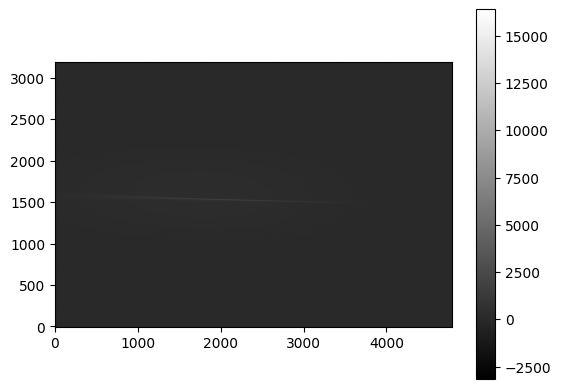

In [11]:
# Select desired image index
img_data = np.fliplr(get_img_data(max_exptime_images[img_index]))
plot_img(img_data)

Fit Line Created: y = -0.0231x + 1582.0265
R-squared Value: 0.9874778231420555


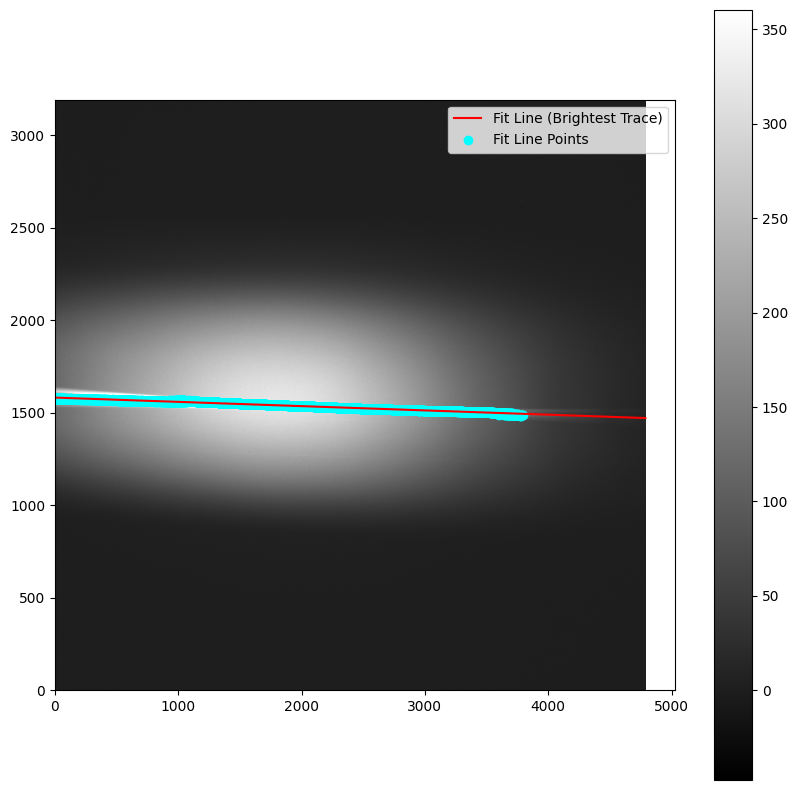

In [12]:
fitline = fit_line(img_data)

In [13]:
# Calculate the angle of the line
rotangle = np.degrees(np.arctan(fitline[0]))
print(rotangle)
print(f"Taking into account that each chunk is 50 pixels wide, the angle is {rotangle:.3f} degrees")

-1.3232375251396284
Taking into account that each chunk is 50 pixels wide, the angle is -1.323 degrees


Spectral Trace  1  is located at y =  1526.0


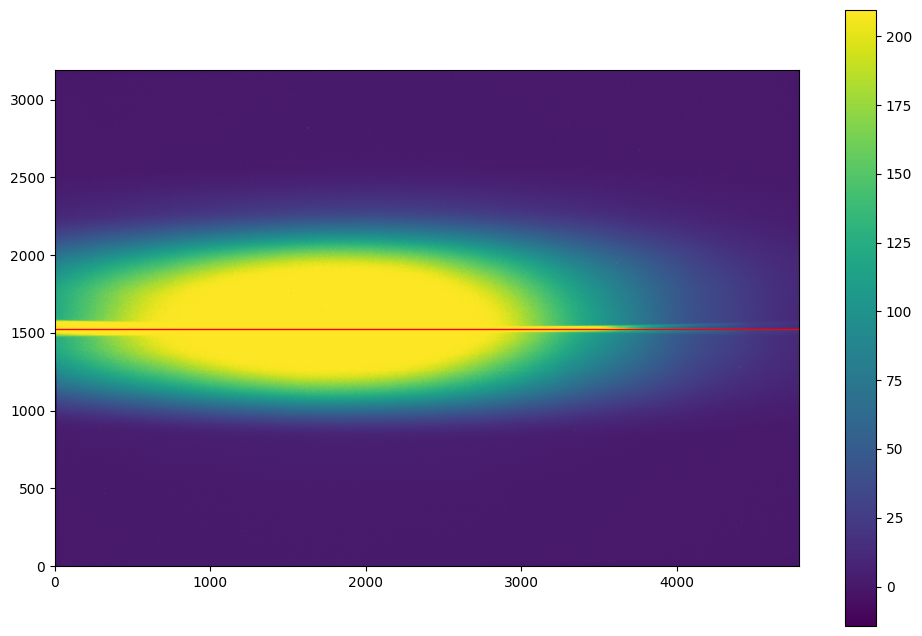

In [14]:
# Rotate the image by the angle
from scipy.ndimage import rotate
rotated_img = rotate(img_data, rotangle, reshape=False)
traces = find_traces(rotated_img, num_traces = 1)

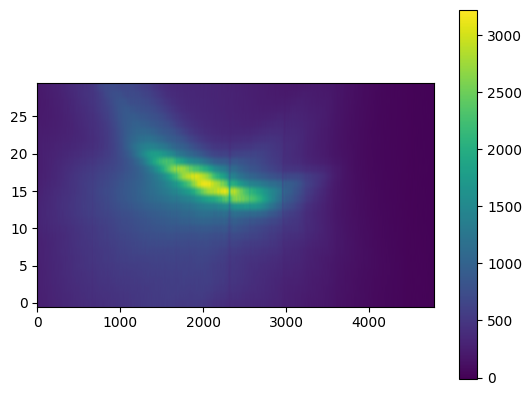

In [15]:
# Get the strip from the rotated image
# rotated_strip = extract_strip(np.fliplr(rotated_img), 30, traces[0])
rotated_strip = extract_strip(rotated_img, 30, traces[0])
plt.imshow(rotated_strip, cmap='viridis', origin='lower')
# Aspect ratio of 10
plt.gca().set_aspect(90)
plt.colorbar()
plt.show()

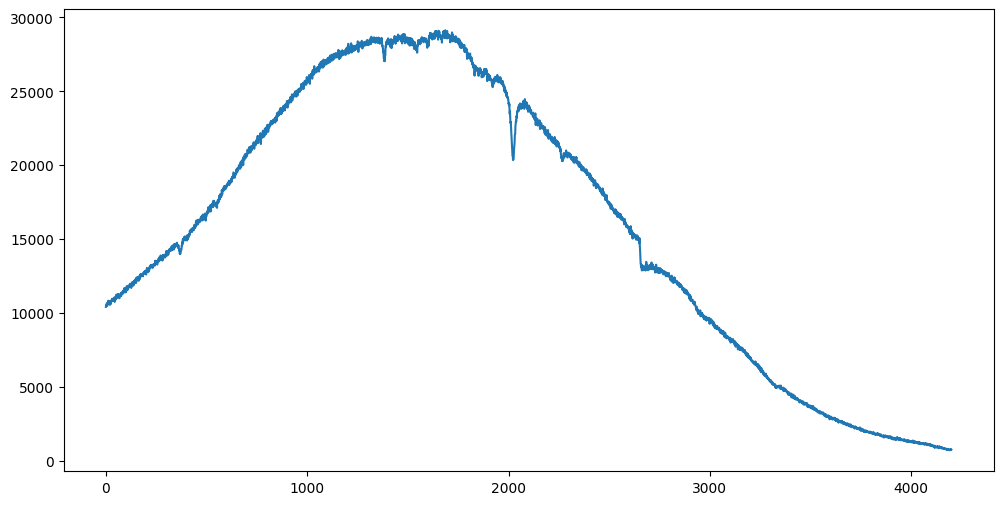

In [16]:
# Sum columns of the rotated strip
col_sum = np.sum(rotated_strip, axis=0)
plt.figure(figsize=(12, 6))
plt.plot(col_sum[300:4500])
plt.show()

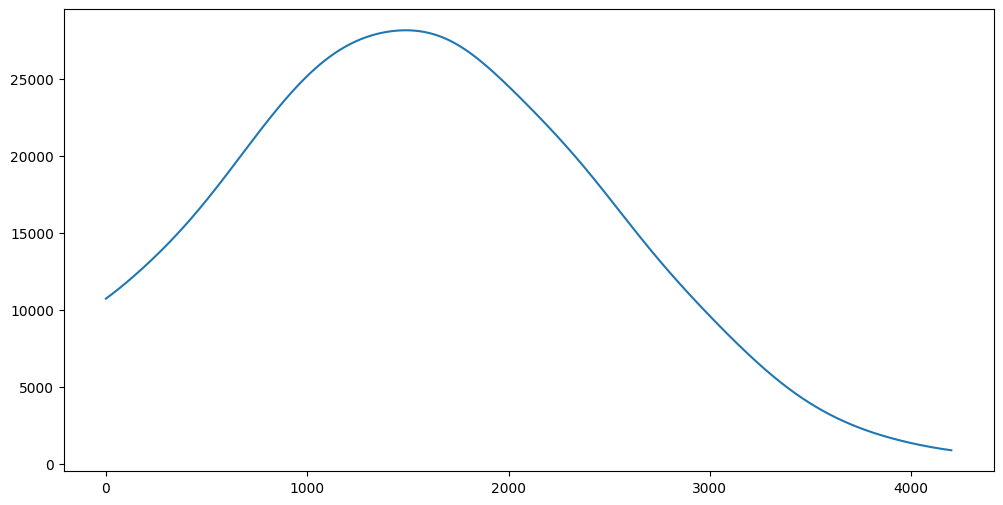

In [17]:
# Smooth the column sum
from scipy.ndimage import gaussian_filter1d
smoothed_col_sum = gaussian_filter1d(col_sum, 200)
plt.figure(figsize=(12, 6))
plt.plot(smoothed_col_sum[300:4500])
plt.show()

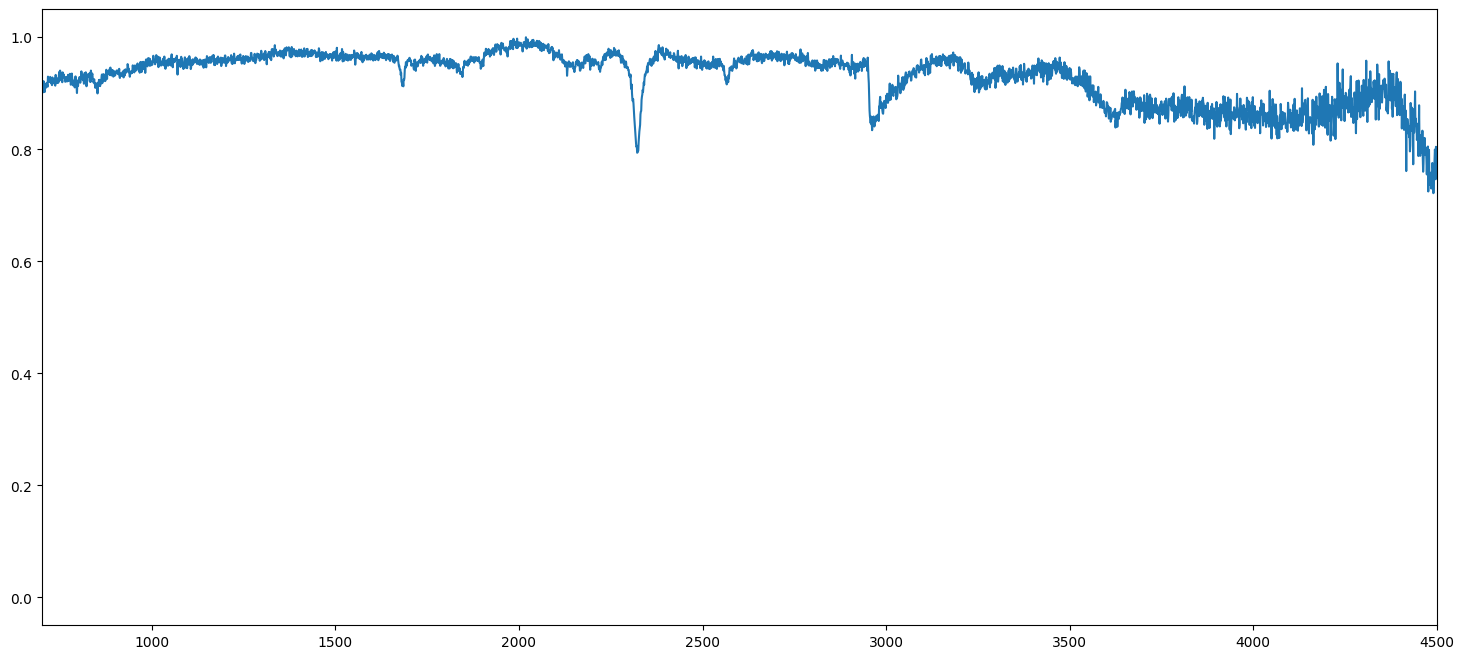

In [18]:
# Divide the smoothed column sum by the maximum value
approx_gain = smoothed_col_sum / np.max(smoothed_col_sum)
norm_spectrum = col_sum / approx_gain
norm_spectrum /= np.max(norm_spectrum)
plt.figure(figsize = (18,8))
plt.plot(norm_spectrum)
plt.xlim(700,4500)
plt.show()

## Re-Extract with Grism Utils

In [19]:
# We need this function to fit the telluric feature to use as an anchor point

from lmfit.models import VoigtModel, ExponentialModel, SplineModel, LinearModel, GaussianModel, ConstantModel

def multi_gauss_with_lin(x, y, x_guess, amp1, amp2):

    amp1 = amp1
    gauss1 = GaussianModel(prefix='g1_')
    pars = gauss1.make_params(center=x_guess, sigma=5)
    pars['g1_amplitude'].set(value=amp1, vary=True, expr='', max=0)
    #pars['v1_gamma'].set(value=2, vary=True, expr='', min=0)

    amp2 = amp2
    gauss2 = GaussianModel(prefix='g2_')
    pars.update(gauss2.make_params(amplitude=-0.5, sigma=5))
    pars['g2_center'].set(value=x_guess+20, vary=True, expr='')
    pars['g2_amplitude'].set(value=amp2, vary=True, expr='', max=0)
    #pars['v2_gamma'].set(value=2, vary=True, expr='', min=0)

    #knot_xvals = np.array([x_guess-50, x_guess-45, x_guess-40, x_guess-35, x_guess-30, x_guess-25, x_guess+25, x_guess+30, x_guess+35, x_guess+40, x_guess+45, x_guess+50])

    bkg = LinearModel(prefix='bkg_')
    pars.update(bkg.guess(y, x))

    mod = gauss1 + gauss2 + bkg

    init = mod.eval(pars, x=x)
    out = mod.fit(y, pars, x=x)

    print(out.fit_report(correl_mode='False'))

    # print just the center of the voigt profiles
    wave_fit = min(out.params['g1_center'].value, out.params['g2_center'].value)

    fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))
    axes[0].plot(x, y, alpha = 0.5)
    axes[0].plot(x, init, '--', label='initial fit')
    axes[0].plot(x, out.best_fit, '-', label='best fit')
    axes[0].legend()

    comps = out.eval_components(x=x)
    axes[1].plot(x, y, alpha = 0.5)
    axes[1].plot(x, (comps['g1_']+np.mean(comps['bkg_'])), '--', label='Gauss component 1')
    axes[1].plot(x, (comps['g2_']+np.mean(comps['bkg_'])), '--', label='Gauss component 2')
    axes[1].plot(x, comps['bkg_'], '--', label='Background component')
    axes[1].legend()

    plt.show()

    return wave_fit

In [20]:
# This uses the multi_gauss_with_lin function and finds the telluric line pixel location

def find_telluric(norm_spectrum, prominence = None, recursion = 0):

    if recursion > 40:
        print('Unable to find telluric line')
        return

    # row_data = data[trace_y]
    # smoothed_col_sum = gaussian_filter1d(row_data, 200)
    # approx_gain = smoothed_col_sum / np.max(smoothed_col_sum)
    # norm_spectrum = row_data / approx_gain
    # norm_spectrum /= np.median(norm_spectrum)

    low = 2800
    # low = 2550
    high = 3120

    flipped_spectrum = norm_spectrum*(-1)
    median = np.median(flipped_spectrum)
    std = np.std(flipped_spectrum)

    if prominence is None:
        prominence = 2*std

    peaks, properties = find_peaks(flipped_spectrum,height = median,prominence = prominence)
    peaks_list = []
    for entry in peaks:
        peaks_list.append(entry)

    i=0
    while i < len(peaks_list):
        if peaks_list[i] < low or peaks_list[i] > high:
            del peaks_list[i]
        else:
            i+=1
            continue

    if len(peaks_list) == 0:
        return find_telluric(norm_spectrum, prominence = prominence/2, recursion = recursion + 1)

    if len(peaks_list) > 1:
        return find_telluric(norm_spectrum, prominence = 1.25*prominence, recursion = recursion + 1)

    x = np.linspace(0,len(norm_spectrum)-1,len(norm_spectrum))
    y = norm_spectrum

    x_guess_red = int(np.round(x[peaks_list][0]))
    mask = (x > x_guess_red - 200) & (x < x_guess_red + 200)
    x_red = x[mask]
    y_red = y[mask]
    px_fit_red = int(np.round(multi_gauss_with_lin(x_red, y_red, x_guess_red, -0.2, -0.2)))
    print('')
    print(f"Initial Guess: {x_guess_red}")
    print('')
    print(f"Red Band (Fit): {px_fit_red}")

    if np.abs(px_fit_red - x_guess_red) > 50:
      print('')
      print("Poor Fit, using initial guess value")
      px_fit_red = x_guess_red

    print('')
    print(f"Telluric Line found at x = {x[px_fit_red]}")

    plt.figure(figsize=(18, 6))
    plt.plot(norm_spectrum)
    plt.axvline(x = px_fit_red ,color = 'r',linestyle = '--', linewidth = 0.75, alpha = 0.8, label = 'Telluric Line')
    plt.title('Continuum Normalized Ha Grism Spectrum')
    plt.xlabel('Pixels Location')
    plt.ylabel('Normalized Relative Flux')
    plt.ylim(np.min(norm_spectrum)-2*std, np.max(norm_spectrum)+2*std)
    plt.legend(fontsize = 18)
    plt.show()

    return px_fit_red

[[Model]]
    ((Model(gaussian, prefix='g1_') + Model(gaussian, prefix='g2_')) + Model(linear, prefix='bkg_'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 687
    # data points      = 399
    # variables        = 8
    chi-square         = 0.04198816
    reduced chi-square = 1.0739e-04
    Akaike info crit   = -3638.57231
    Bayesian info crit = -3606.66062
    R-squared          = 0.89394029
[[Variables]]
    g1_amplitude:  -2.07255737 +/- 0.19198721 (9.26%) (init = -0.2)
    g1_center:      2967.41021 +/- 0.45089383 (0.02%) (init = 2962)
    g1_sigma:       10.0427646 +/- 0.63114231 (6.28%) (init = 5)
    g1_fwhm:        23.6489030 +/- 1.48622655 (6.28%) == '2.3548200*g1_sigma'
    g1_height:     -0.08233100 +/- 0.00439381 (5.34%) == '0.3989423*g1_amplitude/max(1e-15, g1_sigma)'
    g2_amplitude:  -5.47322136 +/- 0.34034672 (6.22%) (init = -0.2)
    g2_center:      3007.27883 +/- 2.13645223 (0.07%) (init = 2982)
    g2_sigma:       35.7144812 +/- 1.8

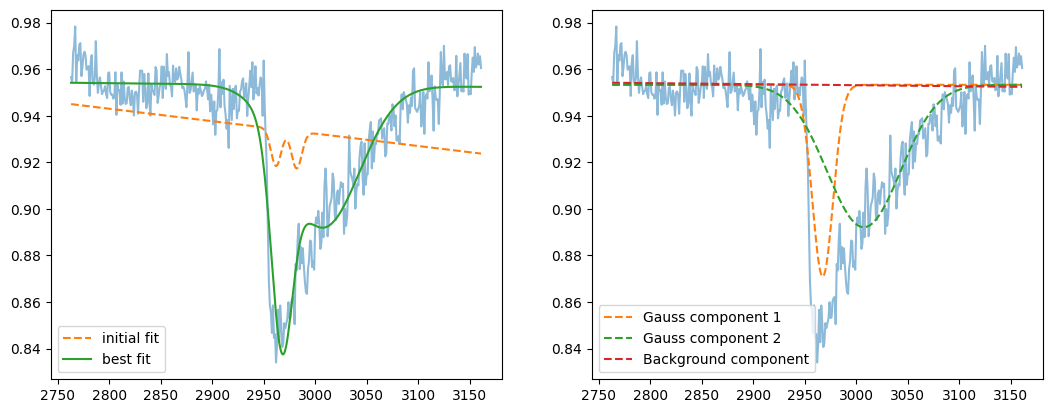


Initial Guess: 2962

Red Band (Fit): 2967

Telluric Line found at x = 2967.0


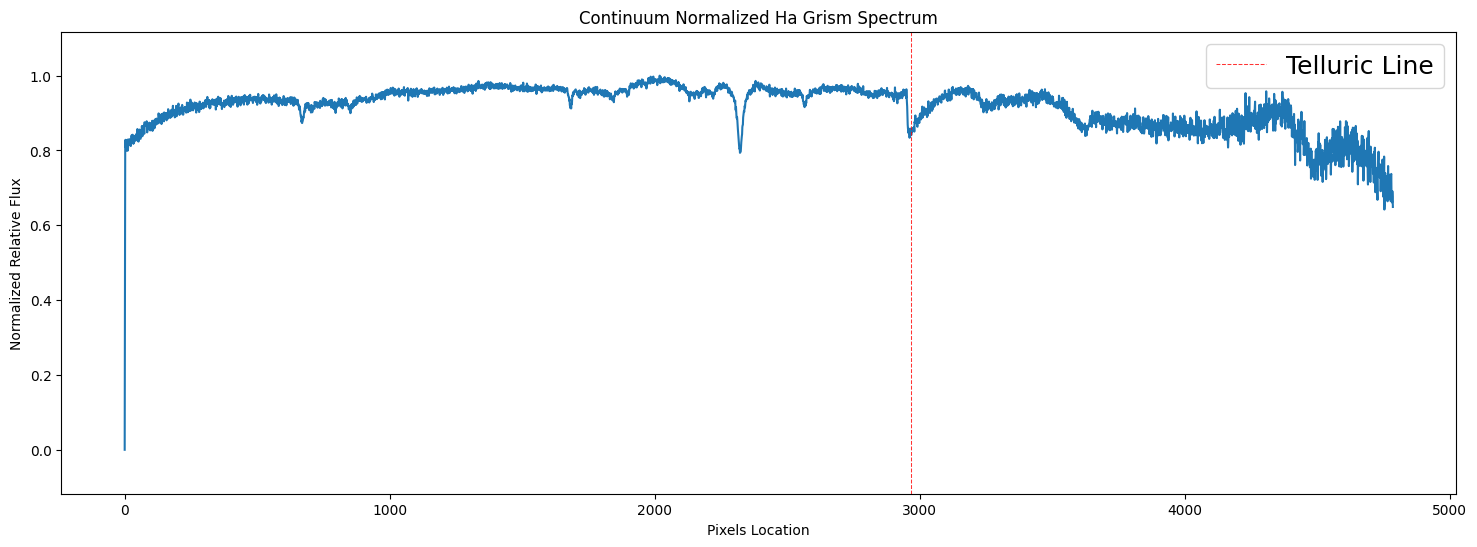

In [21]:
# Find and fit the telluric line pixel location

telluric_x = find_telluric(norm_spectrum)
# telluric_x = find_telluric(norm_spectrum[800:]) # if lrg

In [22]:
def read_calfile(fname):
    ''' Reads grism calibration file (.csv), extracts header line, subimage box, rotation angle,
    and coefficients to generate functions that convert pixels to wavelength and gain vs wavelength'''
    with open(fname,'r') as f:
        lines = f.read().split('\n')
        hdr_line = lines[0]
        box = [int(x) for x in lines[1].split(',')]
        angle = float(lines[2])
        wavelength_coefficients = np.array([float(x) for x in lines[3].split(',')])
        gain_coefficients = np.array([float(x) for x in lines[4].split(',')] )
    return(hdr_line, box, angle, wavelength_coefficients, gain_coefficients)

# Here we load the default calibration file, derived from a single Jacoby star (this will be improved later):
cal_folder =  os.getcwd() 
sys.path.append(cal_folder)
cal_file = cal_folder+'/2025-04-09_hrg_cal_(STELIBmaster).csv'

# Get data from image and calibration file
cal_hdr, box, rot_angle, wavelength_coefficients, gain_coefficients = read_calfile(cal_file)
f_wave = np.poly1d(wavelength_coefficients)
f_gain = np.poly1d(gain_coefficients)
print(f'Wavelength Coefficients: {wavelength_coefficients}')
print(f'Gain Coefficients: {gain_coefficients}')
print('')

Wavelength Coefficients: [2.41873267e-05 3.69489776e-01 5.79825619e+03]
Gain Coefficients: [-7.18740000e-09  2.79767631e-04 -4.50150780e+00  3.83163171e+04
 -1.81941932e+08  4.56908713e+11 -4.74029756e+14 -9.69231002e+13]



Maximum ADU count in subimage = 3224.3056640625
Drawing box at 417,1551 with dimensions 3550,50
Full image dimensions: 3193,4787
Rotation angle = -1.3232375251396284 deg
Object: 


/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_77218/421586353.py:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig[0].show()


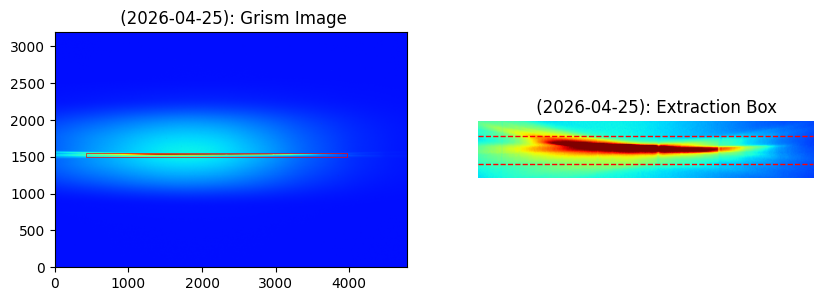

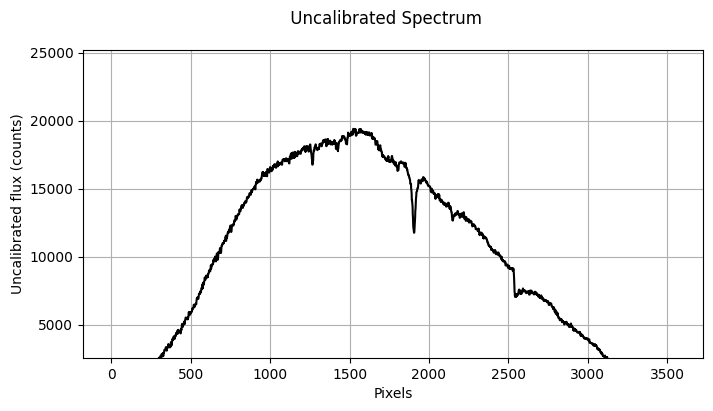

In [23]:
# Defining subimages box dimensions + plotting uncalibrated spectra
filter = 'hrg'

if filter == 'hrg':
    xwidth = 3550
    ywidth = 50
    xstart = int(telluric_x - 2550)
    ystart = int(traces[0] + ywidth//2)
    mybox  = [xstart,ystart,xwidth,ywidth]

    # Instantiate with rotation angle and subimage box
    original_img_data = get_img_data(max_exptime_images[img_index])
    img_data = np.fliplr(original_img_data)
    xi,yi = img_data.shape
    xstart, ystart, xwidth, ywidth = mybox
    B = grism_utils(max_exptime_images[img_index],cal_file,rotangle,mybox,f_wave,f_gain, filter = 'hrg')

if filter == 'lrg':
    xwidth = 3550
    ywidth = 70
    xstart = int(telluric_x - 1450)
    ystart = int(traces[0] + ywidth//2 + 8)
    mybox  = [xstart,ystart,xwidth,ywidth]

    # Instantiate with rotation angle and subimage box
    original_img_data = get_img_data(max_exptime_images[img_index])
    xi,yi = original_img_data.shape
    xstart, ystart, xwidth, ywidth = mybox
    B = grism_utils(max_exptime_images[img_index],cal_file,rotangle,mybox,f_wave,f_gain, filter = 'lrg')

# Create subimage using optional box parameters
subim,transim = B.create_box()
xs,ys = subim.shape
zmax = np.max(subim)
print(f'Maximum ADU count in subimage = {zmax}')
print(f'Drawing box at {xstart},{ystart} with dimensions {xwidth},{ywidth}')
print(f'Full image dimensions: {xi},{yi}')
print(f'Rotation angle = {rotangle} deg')

# Plot subimage
object_name, obs_date,telescope,camera,title,im,rot_angle, box, _,_ = B.summary_info()
fig = B.plot_box(image=transim,subim=subim,figsize =(10,10),cmap='jet',box=mybox)
print(f'Object: {object_name}')
fig[0].show()

spectrum,skyave = B.extract_spectrum(subim,extract_percent=70)

fig = B.plot_spectrum(spectrum, xaxis='pixel', yaxis='uncal', title=f'{object_name} Uncalibrated Spectrum', medavg = 5, xlims =[0,0], ylims =[0,0], plot_balmer=False, grid=True)

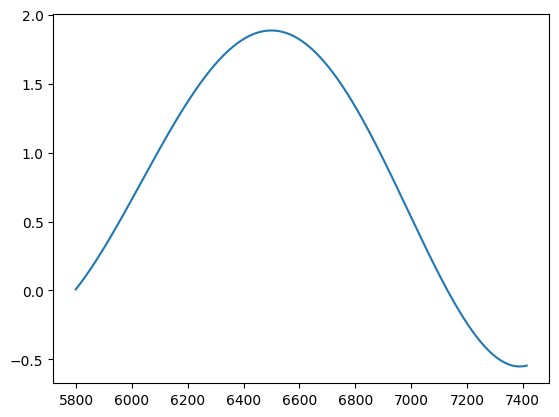

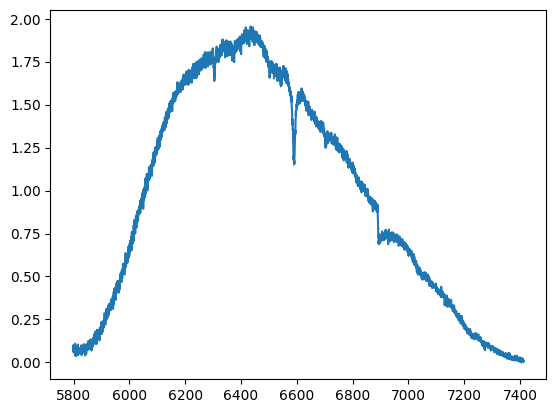

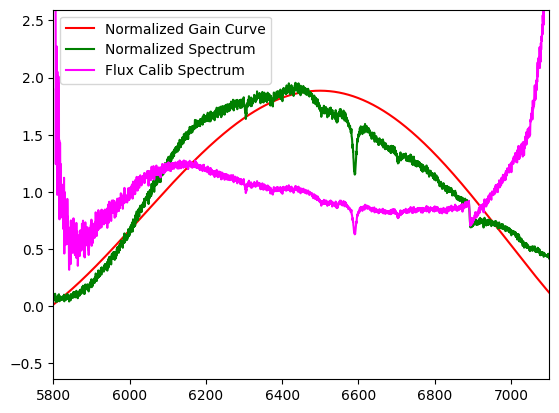

In [24]:
gain_curve = f_gain(spectrum[1])
norm_gain_curve = gain_curve/np.median(gain_curve)

norm_spec = spectrum[2]/np.median(spectrum[2])

plt.plot(spectrum[1], norm_gain_curve)
plt.show()

plt.plot(spectrum[1], norm_spec)
plt.show()

plt.plot(spectrum[1], norm_gain_curve, color = 'red', label = 'Normalized Gain Curve')
plt.plot(spectrum[1], norm_spec, color = 'green', label = 'Normalized Spectrum')
plt.plot(spectrum[1], norm_spec/norm_gain_curve, color = 'magenta', label = 'Flux Calib Spectrum')
plt.xlim(5800, 7100)
plt.ylim(np.min(norm_spec) - np.std(norm_spec), np.max(norm_spec) + np.std(norm_spec))
plt.legend()
plt.show()

In [25]:
# This is a modded recursive version of multi_gauss_with_lin specific for telluric feature
def fit_telluric(x, y, x_guess, amp1, amp2, recursion = 0, offset = None):

    if offset is None:
      offset = 0
    if recursion == 10:
      print('Did not detect feature leftward of initial guess')
      offset = 0
    if recursion > 20:
      print("Recursion limit reached, unable to fit feature")
      return

    # Define the left Gaussian (g1) model
    gauss1 = GaussianModel(prefix='g1_')
    pars = gauss1.make_params(center=x_guess + offset, sigma=5)
    pars['g1_amplitude'].set(value=amp1, vary=True, max=0)

    # Define the right Gaussian (g2) model
    gauss2 = GaussianModel(prefix='g2_')
    pars.update(gauss2.make_params(center=x_guess + 30 + offset, sigma=5))
    pars['g2_amplitude'].set(value=amp2, vary=True, max=0)

    # Define the background model
    bkg = LinearModel(prefix='bkg_')
    pars.update(bkg.guess(y, x))

    # Combine the models
    mod = gauss1 + gauss2 + bkg
    init = mod.eval(pars, x=x)
    out = mod.fit(y, pars, x=x)

    # FWHM, fit components, and centroids for each Gaussian
    fwhms = [2 * out.params['g1_sigma'] * np.sqrt(2 * np.log(2)), 2 * out.params['g2_sigma'] * np.sqrt(2 * np.log(2))]
    centroids = [out.params['g1_center'].value, out.params['g2_center'].value]
    amplitudes = [out.params['g1_height'].value, out.params['g2_height'].value]
    comps = out.eval_components(x=x)
    if centroids[0] < centroids[1]:
      fwhm1 = fwhms[0]
      fwhm2 = fwhms[1]
      g1_fit = comps['g1_'] + comps['bkg_']
      g2_fit = comps['g2_'] + comps['bkg_']
      centroid1 = centroids[0]
      centroid2 = centroids[1]
      amp1 = amplitudes[0]
      amp2 = amplitudes[1]
    else:
      fwhm1 = fwhms[1]
      fwhm2 = fwhms[0]
      g1_fit = comps['g2_'] + comps['bkg_']
      g2_fit = comps['g1_'] + comps['bkg_']
      centroid1 = centroids[1]
      centroid2 = centroids[0]
      amp1 = amplitudes[1]
      amp2 = amplitudes[0]

    # # Plotting for debugging
    # fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))

    # # Left Plot: Data with Fitted Curve
    # axes[0].plot(x, y, label="Data", alpha=0.8)
    # axes[0].plot(x, out.best_fit, '-', label='Best Fit', color='black')
    # axes[0].legend()
    # axes[0].set_title("Data with Best Fit")

    # # Right Plot: Data with Individual Components Overlayed
    # axes[1].plot(x, y, label="Data", alpha=0.5)
    # axes[1].plot(x, g1_fit, '--', label='Gaussian 1 + Background', color='green')
    # axes[1].plot(x, g2_fit, '--', label='Gaussian 2 + Background', color='blue')
    # axes[1].plot(x, comps['bkg_'], '--', label='Background', color='orange')
    # axes[1].legend()
    # axes[1].set_title("Data with Component Fits Overlayed")

    # plt.tight_layout()
    # plt.show()

    idx1 = np.argmin(np.abs(x - centroid1))
    idx2 = np.argmin(np.abs(x - centroid2))

    diff = np.abs(out.best_fit[idx1] - y[idx1])
    diff2 = np.abs(centroid2 - centroid1)
    diff3 = out.best_fit[idx2] - out.best_fit[idx1]

    # diff = np.abs(out.best_fit[int(centroid1 - x[0])] - y[int(centroid1 - x[0])])
    # diff2 = np.abs(centroid2 - centroid1)
    # diff3 = out.best_fit[int(centroid2 - x[0])] - out.best_fit[int(centroid1 - x[0])]

    print('Fit Parameters:')
    print(f'  Left Gaussian FWHM: {fwhm1:.2f} pixels')
    print(f'  Left Gaussian Centroid: x = {centroid1:.2f}')
    print(f' Left Gaussian Amplitude: {amp1:.2f}')
    print(f' Right Gaussian Amplitude: {amp2:.2f}')
    print(f'  Right Gaussian FWHM: {fwhm2:.2f} pixels')
    print(f'  Right Gaussian Centroid: x = {centroid2:.2f}')
    print('')
    print(f'  Left Centroid Fit Value - Left Centroid Data Value [y]: {diff:.4f}')
    print(f'  Centroid Difference [x]: {diff2:.2f}')
    print(f'  Centroid Height Difference (right - left) [y]: {diff3:.4f}')

    if (centroid1 - x[0]) < 0 or (centroid2 - x[0]) < 0 or (centroid1 - x[0]) > len(x) or (centroid2 - x[0]) > len(x):
      if recursion < 10:
        print('')
        print(f"Poor fit (centroid out of bounds), refitting at {x_guess + offset - 10}")
        return fit_telluric(x, y, x_guess, amp1, amp2, recursion = recursion + 1, offset = offset - 5)
      if recursion >= 10:
        print('')
        print(f"Poor fit (centroid out of bounds), refitting at {x_guess + offset + 10}")
        return fit_telluric(x, y, x_guess, amp1, amp2, recursion = recursion + 1, offset = offset + 5)

    if fwhm1 < 5 or fwhm1 > 50 or diff > 0.5 or diff2 > 80 or diff3 < 0:
      if recursion < 10:
        print('')
        print(f"Poor fit parameters, refitting at {x_guess + offset - 10}")
        return fit_telluric(x, y, x_guess, amp1, amp2, recursion = recursion + 1, offset = offset - 5)
      if recursion >= 10:
        print('')
        print(f"Poor fit parameters, refitting at {x_guess + offset + 10}")
        return fit_telluric(x, y, x_guess, amp1, amp2, recursion = recursion + 1, offset = offset + 5)
      
    if np.abs(amp1) < 0.0005 or np.abs(amp2) < 0.0005:
        if recursion < 10:
            print('')
            print(f"Poor fit amplitudes, refitting at {x_guess + offset - 10}")
            return fit_telluric(x, y, x_guess, amp1, amp2, recursion = recursion + 1, offset = offset - 5)
        if recursion >= 10:
            print('')
            print(f"Poor fit amplitudes, refitting at {x_guess + offset + 10}")
            return fit_telluric(x, y, x_guess, amp1, amp2, recursion = recursion + 1, offset = offset + 5)

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))

    # Left Plot: Data with Fitted Curve
    axes[0].plot(x, y, label="Data", alpha=0.8)
    axes[0].plot(x, out.best_fit, '-', label='Best Fit', color='black')
    axes[0].legend()
    axes[0].set_title("Data with Best Fit")

    # Right Plot: Data with Individual Components Overlayed
    axes[1].plot(x, y, label="Data", alpha=0.5)
    axes[1].plot(x, g1_fit, '--', label='Gaussian 1 + Background', color='green')
    axes[1].plot(x, g2_fit, '--', label='Gaussian 2 + Background', color='blue')
    axes[1].plot(x, comps['bkg_'], '--', label='Background', color='orange')
    axes[1].legend()
    axes[1].set_title("Data with Component Fits Overlayed")

    plt.tight_layout()
    plt.show()

    # Return the previous outputs (wave_fit, fwhm1, fwhm2) along with r_squared_left
    wave_fit = min(out.params['g1_center'].value, out.params['g2_center'].value)
    return wave_fit, fwhm1, fwhm2

Fit Parameters:
  Left Gaussian FWHM: 18.61 pixels
  Left Gaussian Centroid: x = 2547.63
 Left Gaussian Amplitude: -0.13
 Right Gaussian Amplitude: -0.09
  Right Gaussian FWHM: 50.16 pixels
  Right Gaussian Centroid: x = 2576.51

  Left Centroid Fit Value - Left Centroid Data Value [y]: 0.0113
  Centroid Difference [x]: 28.88
  Centroid Height Difference (right - left) [y]: 0.0421


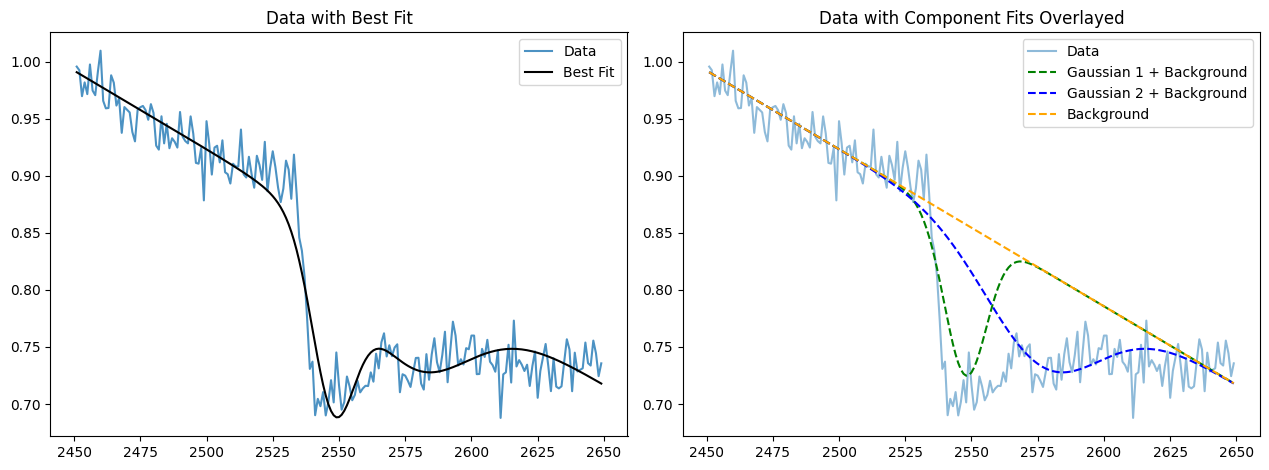

Red Band: 2547.633610332291


In [26]:
# Locate and re-fit the red telluric line to benchmark

red_telluric = []
pixels, waves, amp_uncal, amp_cal = spectrum
# normalize fluxes
norm_flux = amp_uncal / np.median(amp_uncal)

# Fit the telluric absorption lines

x = pixels
y = norm_flux

# x_guess_blue = 1250
# mask = (x > x_guess_blue - 150) & (x < x_guess_blue + 150)
# x_blue = x[mask]
# y_blue = y[mask]
# px_fit_blue = multi_gauss_with_lin(x_blue, y_blue, x_guess_blue, -0.2, -0.2)
# print(f"Blue Band: {px_fit_blue}")

# x_guess_halpha = 1900
# mask = (x > x_guess_halpha - 200) & (x < x_guess_halpha + 200)
# x_halpha = x[mask]
# y_halpha = y[mask]
# px_fit_halpha = Be_multi_voigt_with_lin(x_halpha, y_halpha, x_guess_halpha, -0.2,0.8)
# print(f"Halpha Band: {px_fit_halpha}")
if filter == 'hrg':
    x_guess_red = 2550
mask = (x > x_guess_red - 200) & (x < x_guess_red + 200)
if filter == 'lrg':
    x_guess_red = 2300
mask = (x > x_guess_red - 100) & (x < x_guess_red + 100)
x_red = x[mask]
y_red = y[mask]
if filter == 'hrg':
    px_fit_red = fit_telluric(x_red, y_red, x_guess_red, -0.02, -0.02)[0]
    print(f"Red Band: {px_fit_red}")
if filter == 'lrg':
    px_fit_red = fit_telluric(x_red, y_red, x_guess_red, -0.1, -0.05)[0]
    print(f"Red Band: {px_fit_red}")


In [27]:
# This wavelength calibration is based on Rigel

def wavelength_calibrate(spectra):
    spectrum = spectra
    pixel = np.arange(len(spectrum))
    # wavelength = 5.80675488e+03 + 3.57909865e-01 * pixel + 2.74912632e-05 * (pixel)**2
    wavelength = 5785.106800968903 + 0.38613898500002625 * pixel + 0.00001962150237323153 * (pixel)**2
    calibrated_spectra = wavelength
    spectrum_out = spectrum
    plt.figure(figsize=(14, 6))
    plt.plot(wavelength[:len(spectrum)-10], spectrum[:len(spectrum)-10])

    plt.axvline(x = 6873.1, label='Red Telluric Line (6873.1 Angstroms)', color='red', linestyle='--')
    plt.axvline(x = 6280.4, label='Blue Telluric Line (6280.4 Angstroms)', color='blue', linestyle='--')
    plt.axvline(x = 6562.8, color = 'pink', linestyle = '--', label = 'H Alpha (Rest, 6562.8 Angstroms)')

    plt.xlim(6200,7000)
    plt.ylim(np.min(spectrum) - np.std(spectrum), np.max(spectrum) + np.std(spectrum))
    plt.xlabel('Wavelength (Angstroms)')
    plt.ylabel('Intensity')
    plt.title('Calibrated Spectrum')
    plt.legend(loc = 'upper right')
    plt.show()
    return calibrated_spectra, spectrum_out

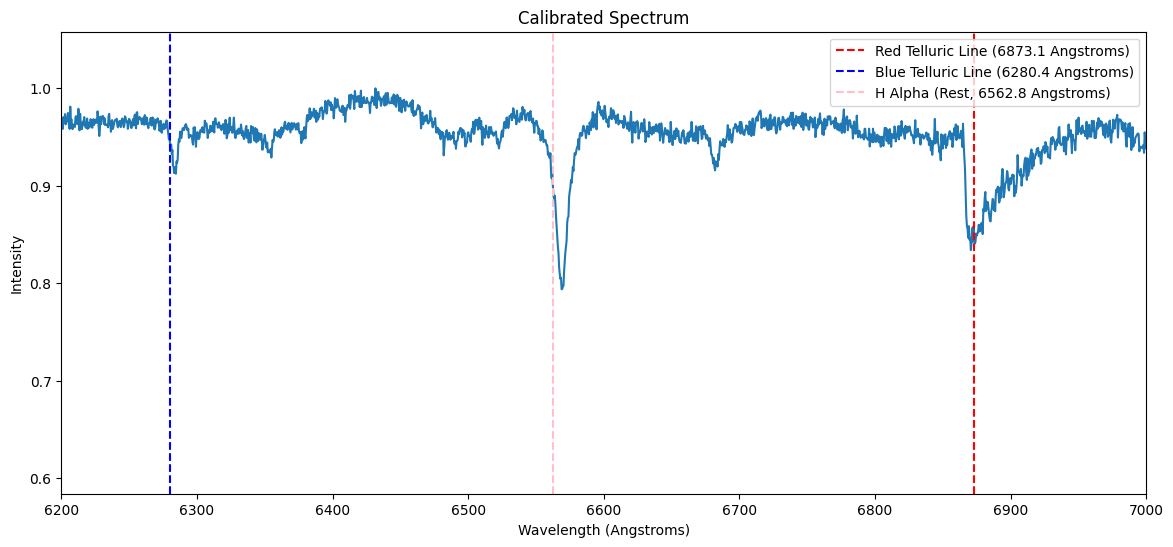

In [28]:
# Create an initial calibrated spectrum using 2500 pixels left of the telluric line as a starting point

if filter =='hrg':
    calibrated_spectrum, spectrum_out = wavelength_calibrate(norm_spectrum[telluric_x - 2500:])
    # calibrated_spectrum, spectrum_out = wavelength_calibrate(norm_spec[telluric_x - 3043:2900]/norm_gain_curve[telluric_x - 3043:2900])

if filter == 'lrg':
    print('No lrg calibs rn')

# Derive Wavelength Solution + Gain Curve

In [29]:
def load_stelib_spectrum(star_name, folder_path):
    """
    Load STELIB spectrum from a CSV file given a star name and folder path.

    Parameters:
    - star_name: str, like 'HD135722'
    - folder_path: str, full path to the folder in Google Drive containing the CSVs

    Returns:
    - df: Pandas DataFrame with columns 'wavelength' and 'flux'
    """
    # Build expected filename
    # Remove underscores in star names
    star_name = star_name.replace('_', '')
    for file in os.listdir(folder_path):
        if star_name in file and file.endswith('.csv'):
            file_path = os.path.join(folder_path, file)
            df = pd.read_csv(file_path)
            return df
    raise FileNotFoundError(f"No file found for star: {star_name}")

def match_and_interpolate(waves_data, flux_data, waves_ref_orig, flux_ref_orig, num_points=1000):
    """
    Safely interpolate both observed and reference spectra to a common grid.
    """
    # Copy reference arrays to avoid in-place modification
    waves_ref = np.copy(waves_ref_orig)
    flux_ref = np.copy(flux_ref_orig)

    # Ensure all arrays are 1D numpy arrays
    waves_data = np.array(waves_data).flatten()
    flux_data = np.array(flux_data).flatten()
    waves_ref = np.array(waves_ref).flatten()
    flux_ref = np.array(flux_ref).flatten()

    # Check that arrays match in size before interpolating
    if len(waves_data) != len(flux_data):
        raise ValueError(f"waves_data and flux_data lengths do not match: {len(waves_data)} vs {len(flux_data)}")
    if len(waves_ref) != len(flux_ref):
        raise ValueError(f"waves_ref and flux_ref lengths do not match: {len(waves_ref)} vs {len(flux_ref)}")

    # Determine overlapping wavelength range
    min_wave = max(np.min(waves_data), np.min(waves_ref))
    max_wave = min(np.max(waves_data), np.max(waves_ref))

    if min_wave >= max_wave:
        raise ValueError("No overlapping wavelength region between data and reference.")

    # Define common wavelength grid
    wave_grid = np.linspace(min_wave, max_wave, num_points)

    # Interpolate both spectra onto the same grid
    flux_data_interp = np.interp(wave_grid, waves_data, flux_data)
    flux_ref_interp = np.interp(wave_grid, waves_ref, flux_ref)

    return wave_grid, flux_data_interp, flux_ref_interp

In [30]:
import numpy as np
from scipy.ndimage import gaussian_filter1d

def wavelength_dependent_gaussian_convolution(wave, flux, R):
    """
    Convolve a spectrum to constant resolving power R
    using a wavelength-dependent Gaussian kernel.

    Parameters
    ----------
    wave : ndarray
        Wavelength array (Å), monotonic
    flux : ndarray
        Flux array
    R : float
        Target resolving power

    Returns
    -------
    flux_conv : ndarray
        Resolution-matched spectrum
    """

    wave = np.asarray(wave)
    flux = np.asarray(flux)

    # Local dispersion (Å / pix)
    dw = np.gradient(wave)

    flux_conv = np.zeros_like(flux)

    for i in range(len(wave)):
        fwhm_lambda = wave[i] / R
        sigma_lambda = fwhm_lambda / 2.355
        sigma_pix = sigma_lambda / dw[i]

        # Limit kernel size for stability
        sigma_pix = np.clip(sigma_pix, 0.5, 50)

        # Apply local Gaussian
        kernel_radius = int(4 * sigma_pix)
        lo = max(0, i - kernel_radius)
        hi = min(len(flux), i + kernel_radius + 1)

        x = np.arange(lo, hi)
        g = np.exp(-0.5 * ((x - i) / sigma_pix) ** 2)
        g /= g.sum()

        flux_conv[i] = np.sum(flux[lo:hi] * g)

    return flux_conv

   Wavelength          Flux
0      3200.0  1.646954e-10
1      3201.0  1.677373e-10
2      3202.0  1.658288e-10
3      3203.0  1.630109e-10
4      3204.0  1.615926e-10


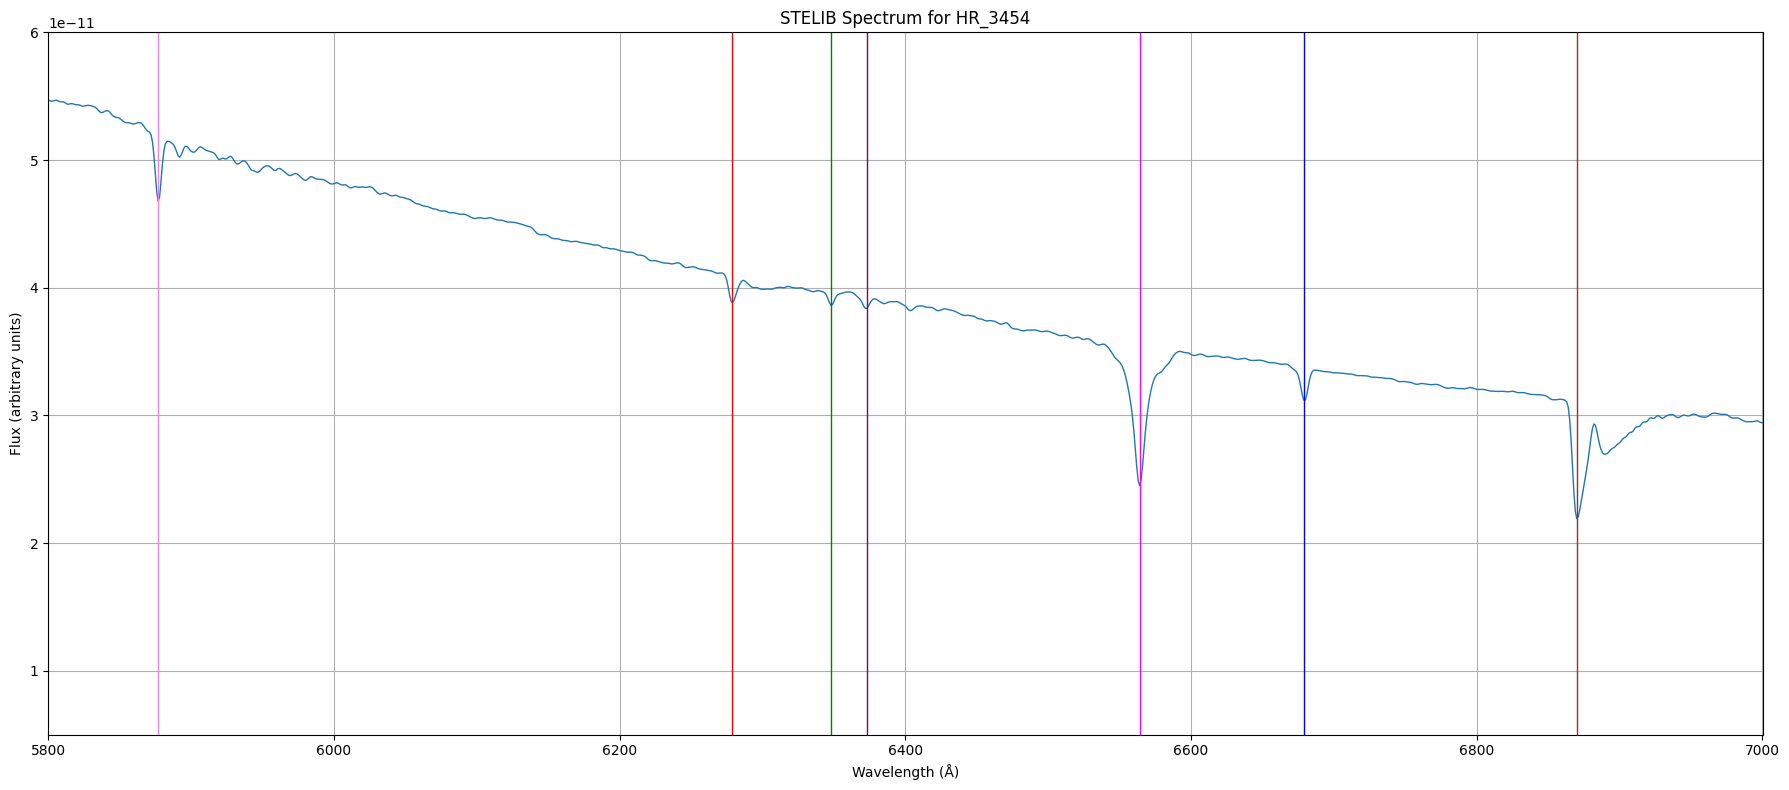

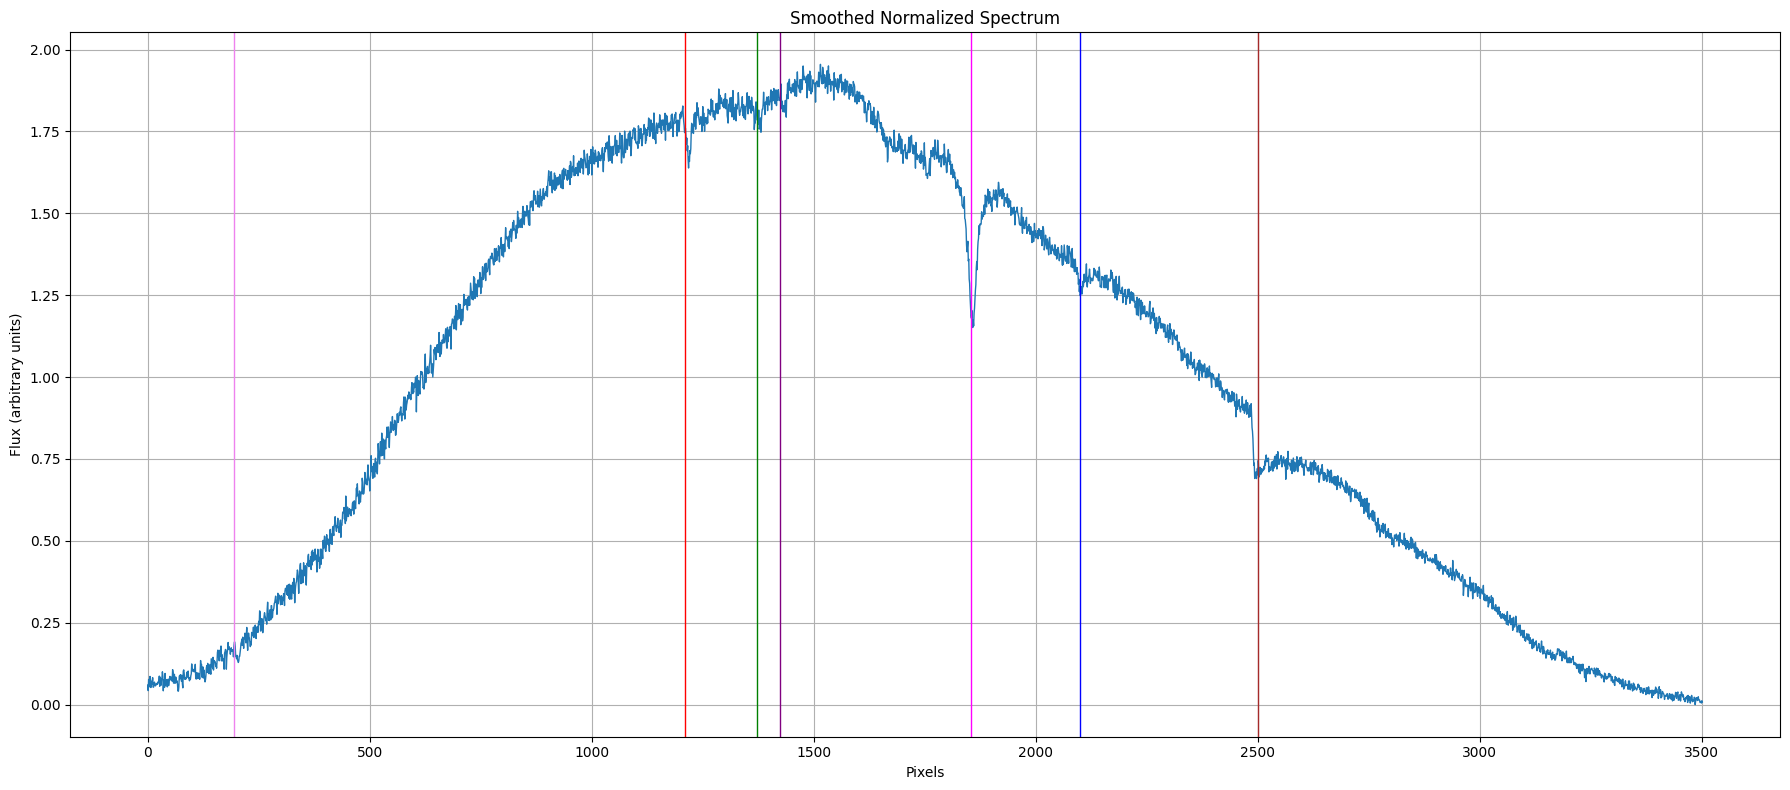

In [31]:
# Match features in RLMT spectrum to reference spectrum

cal_star = 'HR_3454'

spectrum_df = load_stelib_spectrum(cal_star, 'STELIB')
jwaves,fluxes = spectrum_df['Wavelength'], spectrum_df['Flux']

print(spectrum_df.head())

R = 2000

flux_ref_conv = wavelength_dependent_gaussian_convolution(
    jwaves,
    fluxes,
    R
)

# plt.figure(figsize=(10, 4))
# plt.plot(spectrum_df['Wavelength'], spectrum_df['Flux'], lw=1)
# plt.xlabel('Wavelength (Å)')
# plt.ylabel('Flux (arbitrary units)')
# plt.title(f'STELIB Spectrum for {cal_star}')
# plt.grid(True)
# plt.tight_layout()
# plt.show()

colors = ['violet', 'red', 'green', 'purple', 'magenta', 'blue', 'brown', 'black', 'orange', 'grey']
# wavelength_guesses = [4102, 4340, 4470, 4861, 4920, 5875, 6563, 6870]
wavelength_guesses = [5877, 6279, 6348, 6373, 6564, 6679, 6870]

plt.figure(figsize=(18, 8))
plt.plot(jwaves, flux_ref_conv, lw=1)
plt.xlabel('Wavelength (Å)')
plt.ylabel('Flux (arbitrary units)')
plt.title(f'STELIB Spectrum for {cal_star}')

for i in range(len(wavelength_guesses)):
    plt.axvline(wavelength_guesses[i], color = colors[i], lw = 1)

plt.xlim(5800,7000)
# plt.xlim(4000,8000)
# plt.ylim(0.15e-10,0.6e-10)
plt.ylim(0.05e-10, 0.6e-10)
plt.grid(True)
plt.tight_layout()
plt.show()

pixels = spectrum[0][int(np.round(px_fit_red))-2500:] - (int(np.round(px_fit_red))-2500)
spec_flux = norm_spec[int(np.round(px_fit_red))-2500:]
# pixel_guesses = [302, 413, 480, 658, 686, 1412, 2034, 2247]
pixel_guesses = [194, 1211, 1372, 1425, 1853, 2099, 2501]

plt.figure(figsize=(18, 8))
# plt.plot(pixels, spec_flux, lw=1)
plt.plot(pixels, spec_flux, lw=1)
plt.xlabel('Pixels')
plt.ylabel('Flux (arbitrary units)')
plt.title(f'Smoothed Normalized Spectrum')

for i in range(len(pixel_guesses)):
    plt.axvline(pixel_guesses[i], color = colors[i], lw = 1)

plt.grid(True)
plt.tight_layout()
plt.show()

In [32]:
# def voigt_centroid(x, y, x0, window=10):
#     """
#     Fit a Voigt profile near x0 and return the centroid.

#     Parameters
#     ----------
#     x : array
#         Pixel or wavelength array
#     y : array
#         Flux array (absorption line)
#     x0 : float
#         Initial guess (pixel or wavelength)
#     window : int
#         Half-width of fit window in x units

#     Returns
#     -------
#     center : float
#         Fitted centroid
#     center_err : float or None
#         1σ uncertainty (if available)
#     result : lmfit result object
#     """

#     idx = np.argmin(np.abs(x - x0))
#     lo = max(idx - window, 0)
#     hi = min(idx + window + 1, len(x))

#     xfit = x[lo:hi]
#     yfit = y[lo:hi]

#     # Absorption line → invert for lmfit peak models
#     yfit_inv = np.max(yfit) - yfit

#     voigt = VoigtModel(prefix='v_')
#     cont = ConstantModel(prefix='c_')
#     model = voigt + cont

#     params = model.make_params()

#     params['v_center'].set(value=x0, min=xfit.min(), max=xfit.max())
#     params['v_sigma'].set(value=1.0, min=0.1)
#     params['v_gamma'].set(value=1.0, min=0.1)
#     params['v_amplitude'].set(value=np.trapz(yfit_inv, xfit), min=0)

#     params['c_c'].set(value=np.median(yfit_inv))

#     result = model.fit(yfit_inv, params, x=xfit)

#     center = result.params['v_center'].value
#     center_err = result.params['v_center'].stderr

#     return center, center_err, result

def voigt_centroid(x, y, x0, window=10):
    idx = np.argmin(np.abs(x - x0))
    lo = max(idx - window, 0)
    hi = min(idx + window + 1, len(x))

    xfit = np.asarray(x[lo:hi], dtype=float)
    yfit = np.asarray(y[lo:hi], dtype=float)

    # --- fit local continuum on ORIGINAL spectrum ---
    cont = LinearModel(prefix="c_")
    cont_pars = cont.guess(yfit, x=xfit)
    cont_fit = cont.eval(cont_pars, x=xfit)

    # subtract continuum, then invert (absorption -> positive peak)
    yline = yfit - cont_fit
    yfit_inv = -(yline)                # absorption is negative -> make positive
    yfit_inv = np.clip(yfit_inv, 0, None)

    # --- Voigt on continuum-flattened inverted line ---
    voigt = VoigtModel(prefix="v_")
    model = voigt  # baseline already removed

    pars = voigt.make_params()
    pars['v_center'].set(value=x0, min=xfit.min(), max=xfit.max())

    # Make widths scale with sampling a bit more sensibly:
    dx = np.median(np.diff(xfit)) if len(xfit) > 2 else 1.0
    pars['v_sigma'].set(value=2*dx, min=0.25*dx)
    pars['v_gamma'].set(value=2*dx, min=0.25*dx)

    pars['v_amplitude'].set(value=np.trapz(yfit_inv, xfit), min=0)

    result = model.fit(yfit_inv, pars, x=xfit, method='least_squares', fit_kws={'loss': 'soft_l1'})

    center = result.params['v_center'].value
    center_err = result.params['v_center'].stderr
    return center, center_err, result

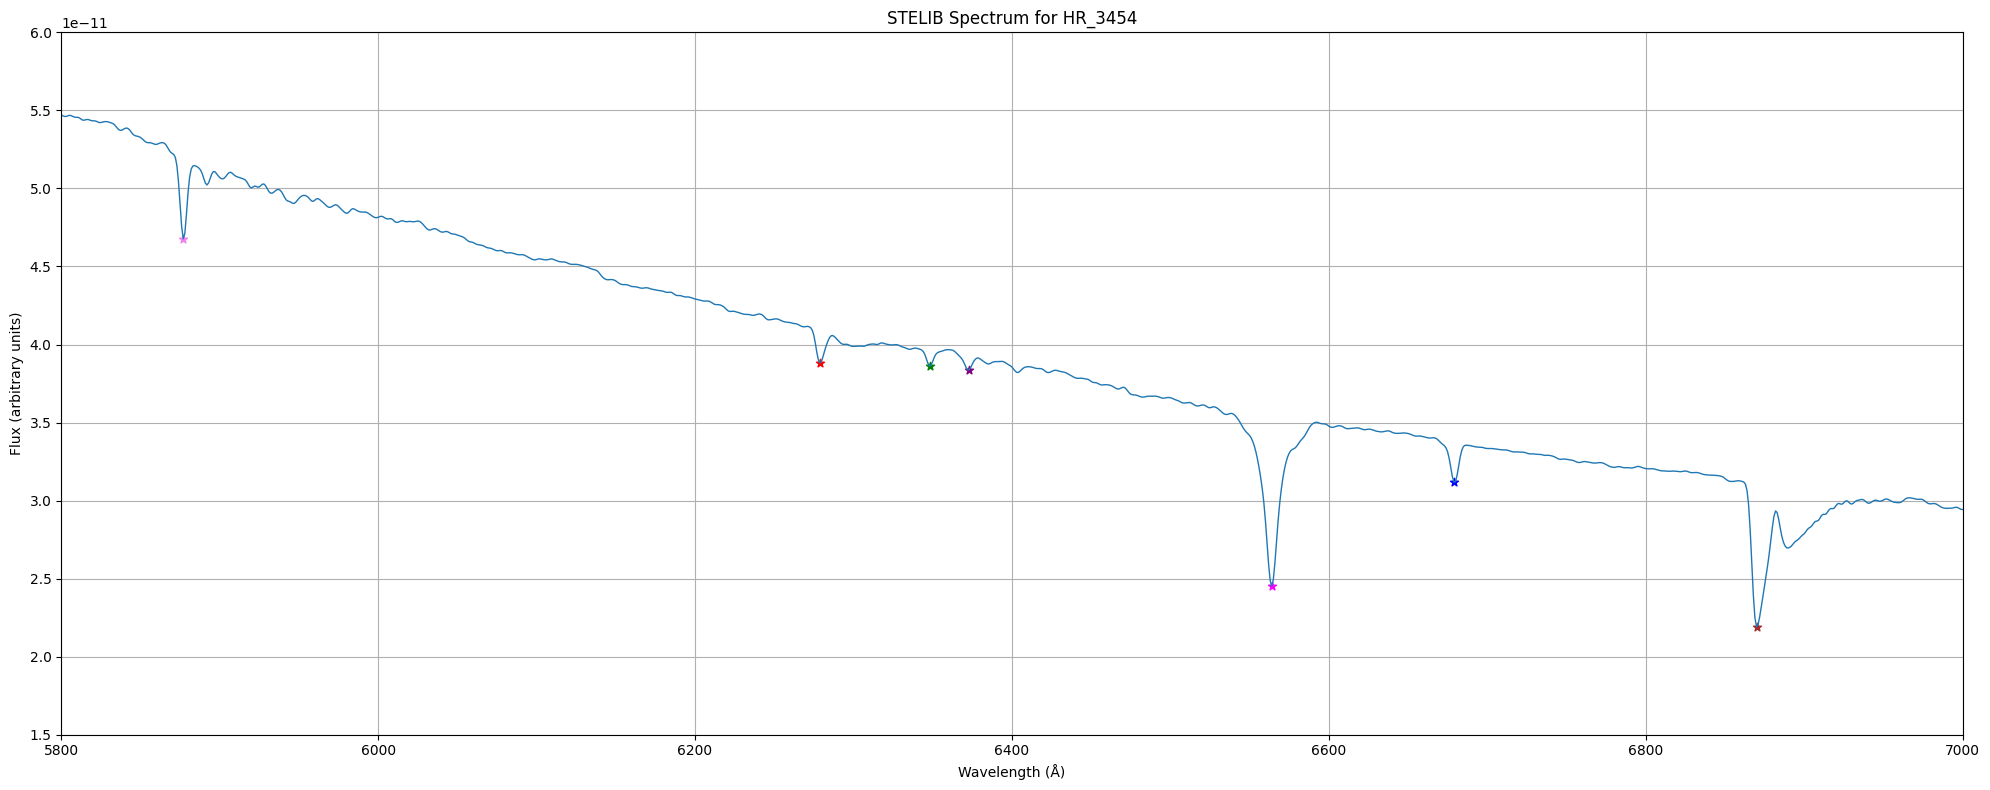

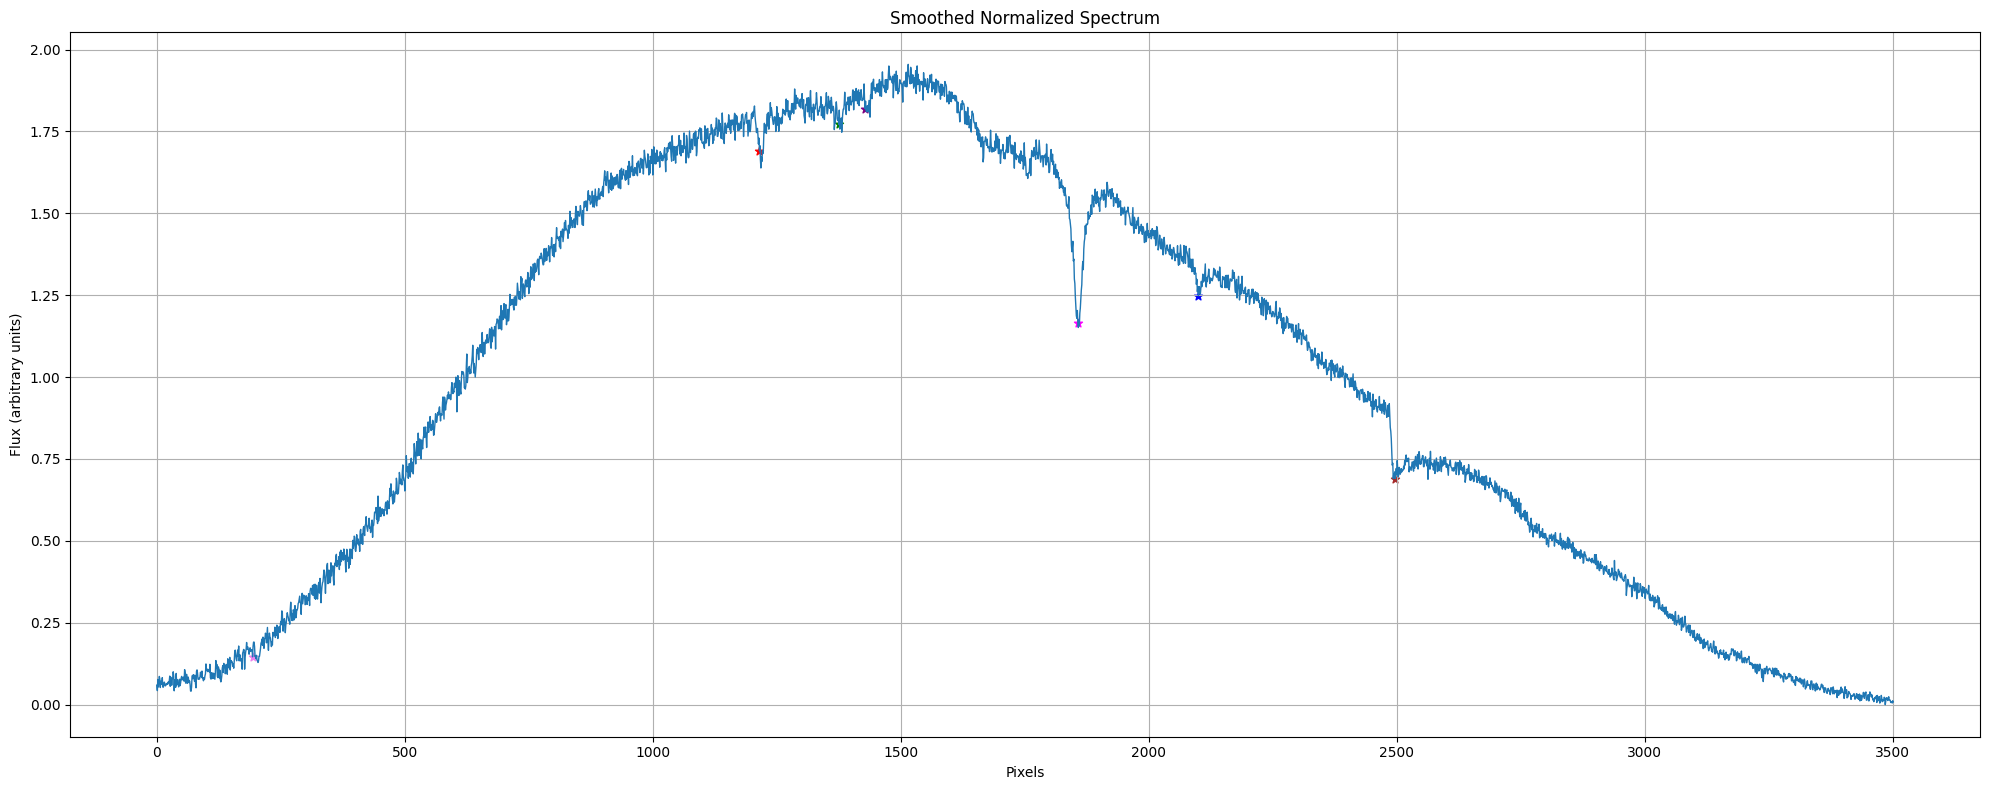

In [33]:
# Re-derive wavelength and pixel centroids

R = 2000  

flux_ref_conv = wavelength_dependent_gaussian_convolution(
    jwaves,
    fluxes,
    R
)

wavelength_centroids = []

for wavelength_guess in wavelength_guesses:
    index = np.argmin(np.abs(jwaves-wavelength_guess))
    mask = (jwaves > jwaves[index-5]) & (jwaves < jwaves[index + 5])
    min_flux = np.min(flux_ref_conv[mask])
    new_index = np.argmin(np.abs(flux_ref_conv - min_flux))
    new_wavelength = jwaves[new_index]
    wavelength_centroids.append(new_wavelength)

pixel_centroids = []

for pixel_guess in pixel_guesses:
    index = np.argmin(np.abs(pixels-pixel_guess))
    mask = (pixels > pixels[index-5]) & (pixels < pixels[index + 5])
    min_flux = np.min(spec_flux[mask])
    new_index = np.argmin(np.abs(spec_flux - min_flux))
    new_pixel = pixels[new_index]
    pixel_centroids.append(new_pixel)

plt.figure(figsize=(20, 8))
plt.plot(jwaves, flux_ref_conv, lw=1)
plt.xlabel('Wavelength (Å)')
plt.ylabel('Flux (arbitrary units)')
plt.title(f'STELIB Spectrum for {cal_star}')

for i in range(len(wavelength_centroids)):
    index = np.argmin(np.abs(jwaves-wavelength_centroids[i]))
    plt.scatter(jwaves[index], flux_ref_conv[index], color = colors[i], marker = '*')

plt.xlim(5800,7000)
# plt.xlim(4000,8000)
plt.ylim(0.15e-10,0.6e-10)
# plt.ylim(0.0e-10, 1.75e-10)
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 8))
plt.plot(pixels, spec_flux, lw=1)
plt.xlabel('Pixels')
plt.ylabel('Flux (arbitrary units)')
plt.title(f'Smoothed Normalized Spectrum')

for i in range(len(wavelength_centroids)):
    index = np.argmin(np.abs(pixels-pixel_centroids[i]))
    plt.scatter(pixels[index], spec_flux[index], color = colors[i], marker = '*')

plt.grid(True)
plt.tight_layout()
plt.show()

In [34]:
wavelength_centroids[6]

np.float64(6870.0)


=== Fit Report ===
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 11
    # data points      = 7
    # variables        = 4
    chi-square         = 3.29945159
    reduced chi-square = 1.09981720
    Akaike info crit   = 2.73492284
    Bayesian info crit = 2.51856344
    R-squared          = 0.99999461
[[Variables]]
    p_c0:  5809.14782 +/- 1.86261341 (0.03%) (init = 6373)
    p_c1:  0.34422730 +/- 0.00748068 (2.17%) (init = 0)
    p_c2:  3.8110e-05 +/- 6.7718e-06 (17.77%) (init = 1e-06)
    p_c3: -2.3286e-09 +/- 1.6551e-09 (71.08%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(p_c2, p_c3) = -0.9944
    C(p_c1, p_c2) = -0.9854
    C(p_c1, p_c3) = +0.9638
    C(p_c0, p_c1) = -0.8367
    C(p_c0, p_c2) = +0.7482
    C(p_c0, p_c3) = -0.7004

R^2 = 0.999994609


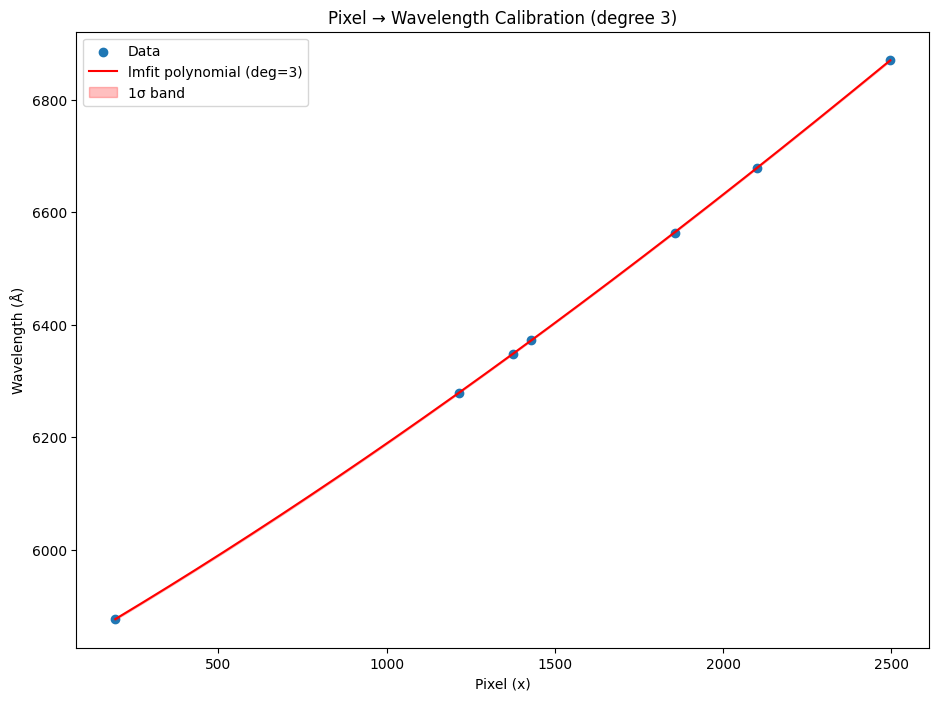

In [35]:
# Pixel --> Wavelength Solution Derivation

from lmfit.models import PolynomialModel
from lmfit import report_fit

degree = 3

xdata = np.asarray(pixel_centroids)
ydata = np.asarray(wavelength_centroids)

low = int(np.min(xdata))
high = int(np.max(xdata))
xplot = np.linspace(low, high, high - low + 1)

model = PolynomialModel(degree=degree, prefix='p_')

params = model.make_params()

# Sensible initial guesses
params['p_c0'].set(value=np.median(ydata))  # constant term

for k in range(1, degree + 1):
    params[f'p_c{k}'].set(value=0.0)

# Optional: weak regularization for higher orders
if degree >= 2:
    params['p_c2'].set(value=1e-6)

result = model.fit(ydata, params, x=xdata)

print("\n=== Fit Report ===")
report_fit(result)

yfit = result.eval(x=xplot)

resid = ydata - result.eval(x=xdata)
ss_res = np.sum(resid**2)
ss_tot = np.sum((ydata - np.mean(ydata))**2)
r2 = 1 - ss_res / ss_tot
print(f"\nR^2 = {r2:.9f}")

cov = result.covar
if cov is None:
    print("WARNING: covariance matrix unavailable — uncertainties cannot be computed.")
else:
    # Build Jacobian dynamically
    J = np.vstack([
        xplot**k for k in range(degree + 1)
    ])  # shape: (degree+1, N)

    var_y = np.einsum('ij,jk,ik->i', J.T, cov, J.T)
    sigma_y = np.sqrt(np.maximum(var_y, 0))

plt.figure(figsize=(11, 8))
plt.scatter(xdata, ydata, label='Data')
plt.plot(xplot, yfit, 'r', label=f'lmfit polynomial (deg={degree})')

if cov is not None:
    plt.fill_between(
        xplot,
        yfit - sigma_y,
        yfit + sigma_y,
        alpha=0.25,
        color='red',
        label='1σ band'
    )

plt.xlabel('Pixel (x)')
plt.ylabel('Wavelength (Å)')
plt.title(f'Pixel → Wavelength Calibration (degree {degree})')
plt.legend()
plt.show()

In [36]:
# # Pixel --> Wavelength Solution Derivation

# from lmfit.models import PolynomialModel
# from lmfit import report_fit

# # Pixel --> Wavelength Solution Derivation

# degree = 3

# xdata = np.asarray(pixel_centroids)
# ydata = np.asarray(wavelength_centroids)

# sigma_x = np.asarray(pixel_errors)
# sigma_y = np.asarray(wavelength_errors)

# sigma_x = np.where(sigma_x == None, np.inf, sigma_x).astype(float)
# sigma_y = np.where(sigma_y == None, np.inf, sigma_y).astype(float)

# low = int(np.min(xdata))
# high = int(np.max(xdata))
# xplot = np.linspace(low, high, high - low + 1)

# model = PolynomialModel(degree=degree, prefix='p_')

# params = model.make_params()

# # Sensible initial guesses
# params['p_c0'].set(value=np.median(ydata))  # constant term

# for k in range(1, degree + 1):
#     params[f'p_c{k}'].set(value=0.0)

# # Optional: weak regularization for higher orders
# if degree >= 2:
#     params['p_c2'].set(value=1e-6)

# result0 = model.fit(ydata, params, x=xdata)

# # print("\n=== Fit Report ===")
# # report_fit(result0)

# # Polynomial derivative evaluated at xdata
# p = result0.params
# dfdx = sum(
#     k * p[f'p_c{k}'].value * xdata**(k-1)
#     for k in range(1, degree + 1)
# )

# sigma_eff = np.sqrt(
#     sigma_y**2 + (dfdx * sigma_x)**2
# )

# weights = 1.0 / sigma_eff

# result = model.fit(
#     ydata,
#     result0.params,
#     x=xdata,
#     weights=weights,
#     scale_covar=False,
#     method='least_squares',
#     fit_kws={'loss': 'soft_l1'}
# )

# print("\n=== Fit Report ===")
# report_fit(result)

# yfit = result.eval(x=xplot)

# resid = ydata - result.eval(x=xdata)
# ss_res = np.sum(resid**2)
# ss_tot = np.sum((ydata - np.mean(ydata))**2)
# r2 = 1 - ss_res / ss_tot
# print(f"\nR^2 = {r2:.9f}")

# cov = result.covar
# if cov is None:
#     print("WARNING: covariance matrix unavailable — uncertainties cannot be computed.")
# else:
#     # Build Jacobian dynamically
#     J = np.vstack([
#         xplot**k for k in range(degree + 1)
#     ])  # shape: (degree+1, N)

#     var_y = np.einsum('ij,jk,ik->i', J.T, cov, J.T)
#     sigma_y = np.sqrt(np.maximum(var_y, 0))

# plt.figure(figsize=(11, 8))
# plt.scatter(xdata, ydata, label='Data')
# plt.plot(xplot, yfit, 'r', label=f'lmfit polynomial (deg={degree})')

# if cov is not None:
#     plt.fill_between(
#         xplot,
#         yfit - sigma_y,
#         yfit + sigma_y,
#         alpha=0.25,
#         color='red',
#         label='1σ band'
#     )

# plt.xlabel('Pixel (x)')
# plt.ylabel('Wavelength (Å)')
# plt.title(f'Pixel → Wavelength Calibration (degree {degree})')
# plt.legend()
# plt.show()

In [37]:
def gaussian_convolution(
    wave,
    flux,
    mode="R",
    value=None,
    wavelength_dependent=True,
    dlambda_is_fwhm=True,
    min_sigma_pix=0.5,
    max_sigma_pix=50.0,
    kernel_radius_sigma=4.0
):
    """
    Gaussian-convolve a spectrum.

    Supports:
    - mode="R"       : smoothing specified by resolving power R
    - mode="dlambda" : smoothing specified by delta-lambda

    and either:
    - wavelength_dependent=True
    - wavelength_dependent=False

    Parameters
    ----------
    wave : ndarray
        Wavelength array (Å), monotonic.
    flux : ndarray
        Flux array.
    mode : {"R", "dlambda"}
        Parameterization of the smoothing width.
    value : float
        Value of the smoothing parameter:
        - if mode="R", this is the resolving power R
        - if mode="dlambda", this is delta-lambda
    wavelength_dependent : bool
        If True:
            - mode="R": uses FWHM_lambda = wave / R
            - mode="dlambda": uses local sigma_pix = sigma_lambda / dw[i]
              (still constant in wavelength, but pixel width varies if dw varies)
        If False:
            uses one fixed sigma_pix across the whole spectrum based on a
            representative wavelength / dispersion.
    dlambda_is_fwhm : bool
        Only used when mode="dlambda".
        If True, `value` is interpreted as FWHM in Å.
        If False, `value` is interpreted as sigma in Å.
    min_sigma_pix : float
        Minimum sigma in pixels allowed.
    max_sigma_pix : float
        Maximum sigma in pixels allowed.
    kernel_radius_sigma : float
        Kernel half-width in units of sigma.

    Returns
    -------
    flux_conv : ndarray
        Convolved spectrum.
    """

    wave = np.asarray(wave, dtype=float)
    flux = np.asarray(flux, dtype=float)

    if wave.ndim != 1 or flux.ndim != 1:
        raise ValueError("wave and flux must be 1D arrays.")
    if len(wave) != len(flux):
        raise ValueError("wave and flux must have the same length.")
    if len(wave) < 3:
        raise ValueError("wave must have length >= 3.")
    if value is None or value <= 0:
        raise ValueError("value must be a positive number.")
    if mode not in {"R", "dlambda"}:
        raise ValueError("mode must be 'R' or 'dlambda'.")
    if not np.all(np.isfinite(wave)) or not np.all(np.isfinite(flux)):
        raise ValueError("wave and flux must contain only finite values.")
    if not np.all(np.diff(wave) > 0):
        raise ValueError("wave must be strictly increasing.")

    # Local dispersion in Å/pixel
    dw = np.gradient(wave)

    # Representative quantities for non-wavelength-dependent mode
    wave_ref = np.nanmedian(wave)
    dw_ref = np.nanmedian(dw)

    if not np.isfinite(dw_ref) or dw_ref <= 0:
        raise ValueError("Could not determine a valid representative dispersion.")

    def sigma_lambda_from_mode(lam):
        if mode == "R":
            fwhm_lambda = lam / value
            return fwhm_lambda / 2.355
        elif mode == "dlambda":
            if dlambda_is_fwhm:
                return value / 2.355
            return value

    flux_conv = np.zeros_like(flux)

    # -------------------------
    # Case 1: fixed sigma_pix
    # -------------------------
    if not wavelength_dependent:
        sigma_lambda_ref = sigma_lambda_from_mode(wave_ref)
        sigma_pix = sigma_lambda_ref / dw_ref
        sigma_pix = float(np.clip(sigma_pix, min_sigma_pix, max_sigma_pix))

        kernel_radius = int(np.ceil(kernel_radius_sigma * sigma_pix))
        xk = np.arange(-kernel_radius, kernel_radius + 1)
        g = np.exp(-0.5 * (xk / sigma_pix) ** 2)
        g /= g.sum()

        # Convolution with edge truncation handled manually
        for i in range(len(wave)):
            lo = max(0, i - kernel_radius)
            hi = min(len(flux), i + kernel_radius + 1)

            k_lo = kernel_radius - (i - lo)
            k_hi = kernel_radius + (hi - i)

            g_local = g[k_lo:k_hi]
            g_local = g_local / np.sum(g_local)

            flux_conv[i] = np.sum(flux[lo:hi] * g_local)

        return flux_conv

    # -------------------------
    # Case 2: variable sigma_pix
    # -------------------------
    for i in range(len(wave)):
        sigma_lambda = sigma_lambda_from_mode(wave[i])
        sigma_pix = sigma_lambda / dw[i]
        sigma_pix = float(np.clip(sigma_pix, min_sigma_pix, max_sigma_pix))

        kernel_radius = int(np.ceil(kernel_radius_sigma * sigma_pix))
        lo = max(0, i - kernel_radius)
        hi = min(len(flux), i + kernel_radius + 1)

        x = np.arange(lo, hi)
        g = np.exp(-0.5 * ((x - i) / sigma_pix) ** 2)
        g /= g.sum()

        flux_conv[i] = np.sum(flux[lo:hi] * g)

    return flux_conv

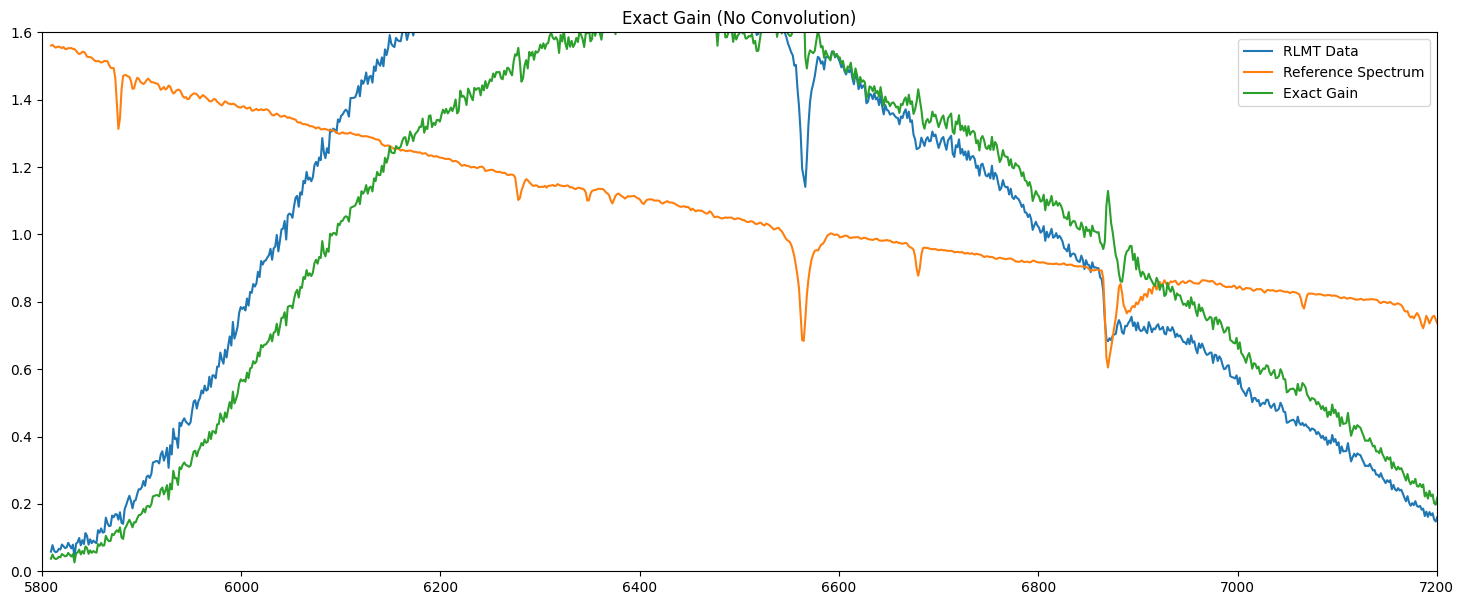

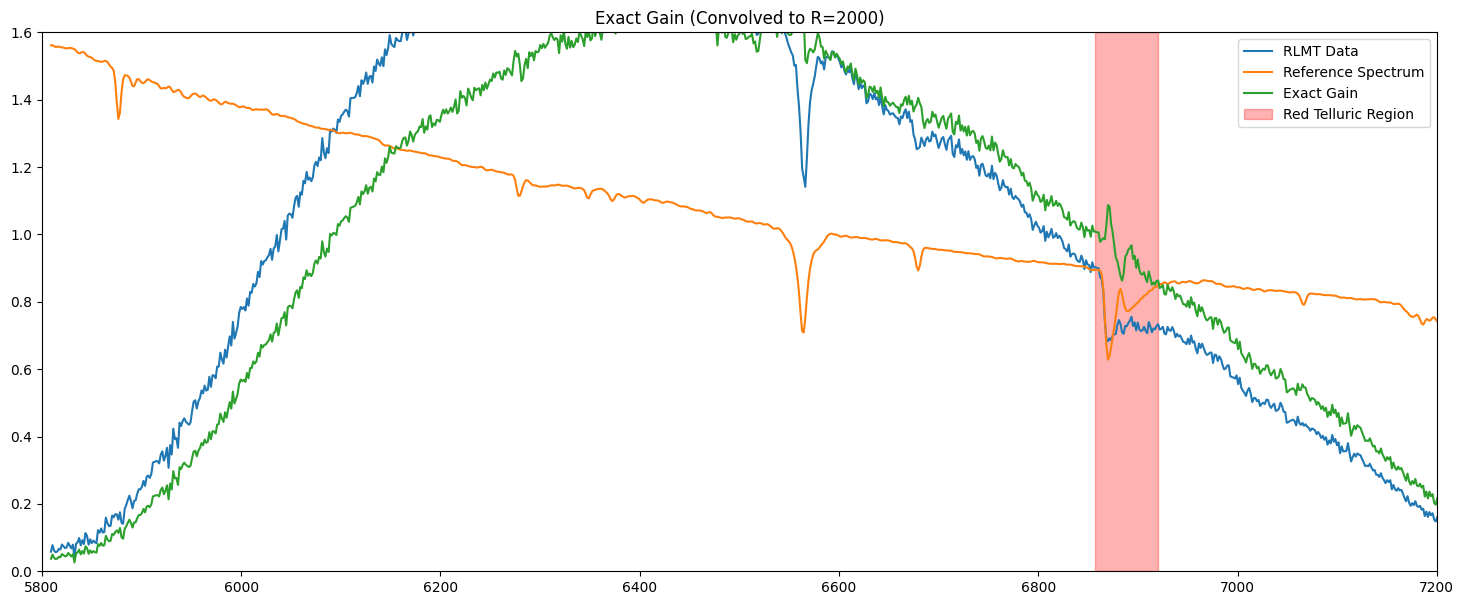

In [38]:
from scipy.ndimage import gaussian_filter1d

wavelengths = result.eval(x=pixels)
spec_flux_norm = spec_flux/np.median(spec_flux)
fluxes_norm = fluxes/np.median(fluxes)

wave_grid, flux_data_interp, flux_ref_interp = match_and_interpolate(wavelengths, spec_flux_norm, jwaves, fluxes_norm)

plt.figure(figsize = (18,7))
plt.plot(wave_grid, flux_data_interp, label = 'RLMT Data')
plt.plot(wave_grid, flux_ref_interp, label = 'Reference Spectrum')
plt.plot(wave_grid, flux_data_interp/flux_ref_interp, label = 'Exact Gain')
# plt.xlim(4100,7800)
plt.xlim(5800,7200)
plt.ylim(0,1.6)
plt.title('Exact Gain (No Convolution)')
plt.legend()
plt.show()

# gain = flux_data_interp/flux_ref_interp


R = 2000  

# flux_ref_conv = wavelength_dependent_gaussian_convolution(
#     jwaves,
#     fluxes,
#     R
# )

flux_ref_conv = gaussian_convolution(
    jwaves,
    fluxes,
    mode="R",
    value=R,
    wavelength_dependent=True,
    dlambda_is_fwhm=True
)

wave_grid, flux_data_interp, flux_ref_interp = match_and_interpolate(wavelengths, spec_flux_norm, jwaves, flux_ref_conv/np.median(flux_ref_conv))

gain = flux_data_interp/flux_ref_interp

plt.figure(figsize = (18,7))
# plt.plot(jwaves, flux_ref_conv/np.median(flux_ref_conv[900:4600]))
# plt.plot(wavelengths, spec_flux_norm)
plt.plot(wave_grid, flux_data_interp, label = 'RLMT Data')
plt.plot(wave_grid, flux_ref_interp, label = 'Reference Spectrum')
plt.plot(wave_grid, gain, label = 'Exact Gain')
# plt.xlim(4100,7800)
plt.xlim(5800,7200)
plt.ylim(0,1.6)
plt.axvspan(6857, 6920, color='red', alpha=0.3, label='Red Telluric Region')
plt.title(f'Exact Gain (Convolved to R={R})')
plt.legend()
plt.show()

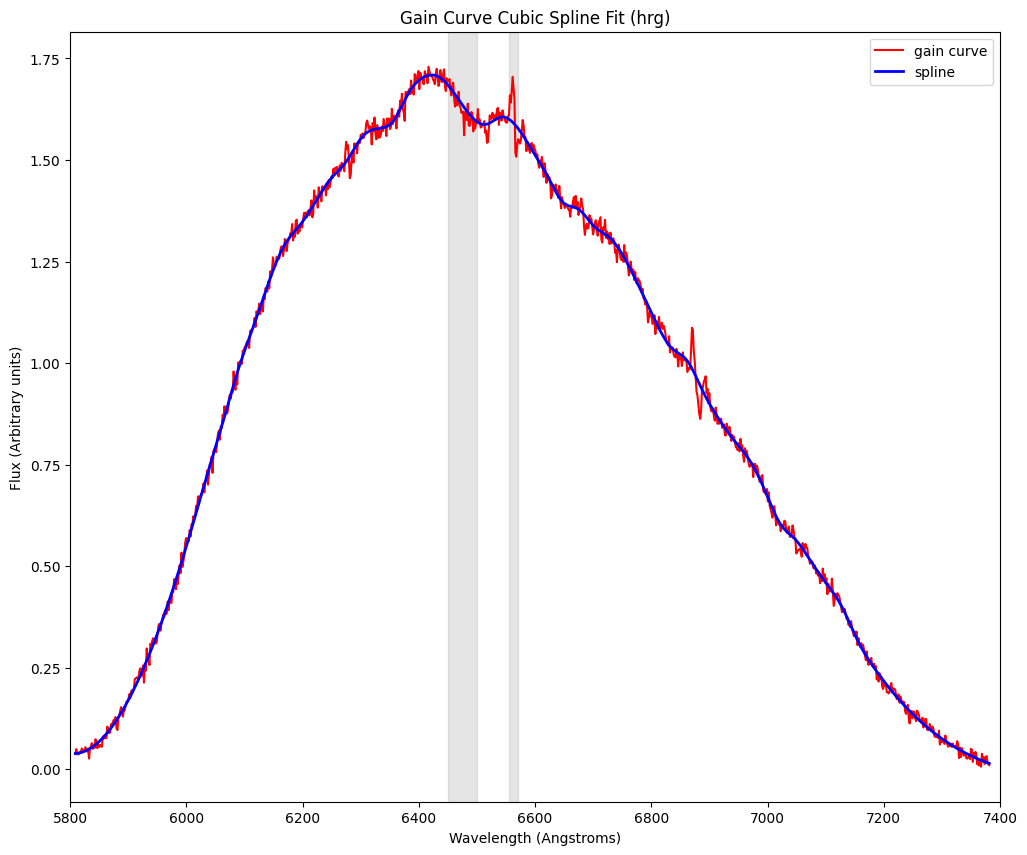

In [39]:
from scipy.interpolate import LSQUnivariateSpline

exclude_regions = [
    (6450, 6500),
    (6555, 6570),
]

mask = np.ones_like(wave_grid, dtype=bool)

for lo, hi in exclude_regions:
    mask &= (wave_grid < lo) | (wave_grid > hi)

knots = np.linspace(wave_grid.min()+200, wave_grid.max()-200, 45)

for lo, hi in exclude_regions:
    knots = knots[(knots < lo) | (knots > hi)]

spline = LSQUnivariateSpline(wave_grid[mask], gain[mask], t=knots, k=3)
gain_smooth = spline(wave_grid)

plt.figure(figsize=(12,10))
plt.plot(wave_grid, gain, color='red', label='gain curve')
plt.plot(wave_grid, gain_smooth, color='blue', linewidth=2, label='spline')

for lo, hi in exclude_regions:
    plt.axvspan(lo, hi, color='gray', alpha=0.2)

plt.xlim(5800, 7400)
plt.xlabel('Wavelength (Angstroms)')
plt.ylabel('Flux (Arbitrary units)')
plt.title(f'Gain Curve Cubic Spline Fit ({filter})')
plt.legend()
plt.show()

In [40]:
cal_spec = flux_data_interp[mask]/gain_smooth

plt.figure(figsize = (12,10))
# plt.plot(wave_grid, flux_data_interp, color = 'red', label = 'original norm data')
# plt.plot(wave_grid, gain_smooth, color = 'green', label = 'gain curve')
plt.plot(wave_grid[mask], cal_spec, color = 'blue', label = 'flux calibrated spectrum')
plt.plot(wave_grid[mask], flux_ref_interp[mask], color = 'black', alpha = 0.8, label = 'reference spectrum')
plt.xlabel('Wavelength (Angstroms)')
plt.ylabel('Flux (Arbitrary units)')
plt.title('Flux Calibrated vs Reference Spectrum')
# plt.xlim(4200,7800)
plt.xlim(6200,7000)
plt.legend()
plt.show()

plt.figure(figsize = (12,10))
# plt.plot(wave_grid, flux_data_interp, color = 'red', label = 'original norm data')
# plt.plot(wave_grid, gain_smooth, color = 'green', label = 'gain curve')
plt.plot(wave_grid[mask], flux_ref_interp[mask] - cal_spec, color = 'blue', label = 'residuals (ref-data)')
plt.xlabel('Wavelength (Angstroms)')
plt.ylabel('Flux (Arbitrary units)')
plt.title('Residuals')
# plt.xlim(4200,7800)
plt.xlim(6200,7000)
plt.legend()
plt.show()

ValueError: operands could not be broadcast together with shapes (959,) (1000,) 

In [ ]:
# HRG Wavelength Solution

calib_dir = Path.cwd() / "grism_calib"
calib_dir.mkdir(exist_ok=True)

wl_path = calib_dir / "wavelength_solutions.csv"

# New solution
df_new = pd.DataFrame([{
    "grism": "highres",
    "a": result.params['p_c2'].value,
    "b": result.params['p_c1'].value,
    "c": result.params['p_c0'].value,
    "units": "angstrom"
}])

if wl_path.exists():
    # Load existing table
    df_all = pd.read_csv(wl_path)

    # Drop existing rows for this grism
    df_all = df_all[df_all["grism"] != "highres"]

    # Append new solution
    df_all = pd.concat([df_all, df_new], ignore_index=True)

else:
    # First-time creation
    df_all = df_new

# Write back to disk
df_all.to_csv(wl_path, index=False)

In [ ]:
# HRG Gain Spline

calib_dir = Path.cwd() / "grism_calib"
calib_dir.mkdir(exist_ok=True)

gain_path = calib_dir / "gain_curves.csv"

# New gain curve
df_new = pd.DataFrame({
    "grism": "highres",
    "wavelength": wave_grid[mask],
    "gain": gain_smooth
})

if gain_path.exists():
    # Load existing gain curves
    df_all = pd.read_csv(gain_path)

    # Drop existing rows for this grism
    df_all = df_all[df_all["grism"] != "highres"]

    # Append new gain curve
    df_all = pd.concat([df_all, df_new], ignore_index=True)

else:
    # First-time creation
    df_all = df_new

# Optional: sort for cleanliness
df_all = df_all.sort_values(["grism", "wavelength"]).reset_index(drop=True)

# Write back to disk
df_all.to_csv(gain_path, index=False)

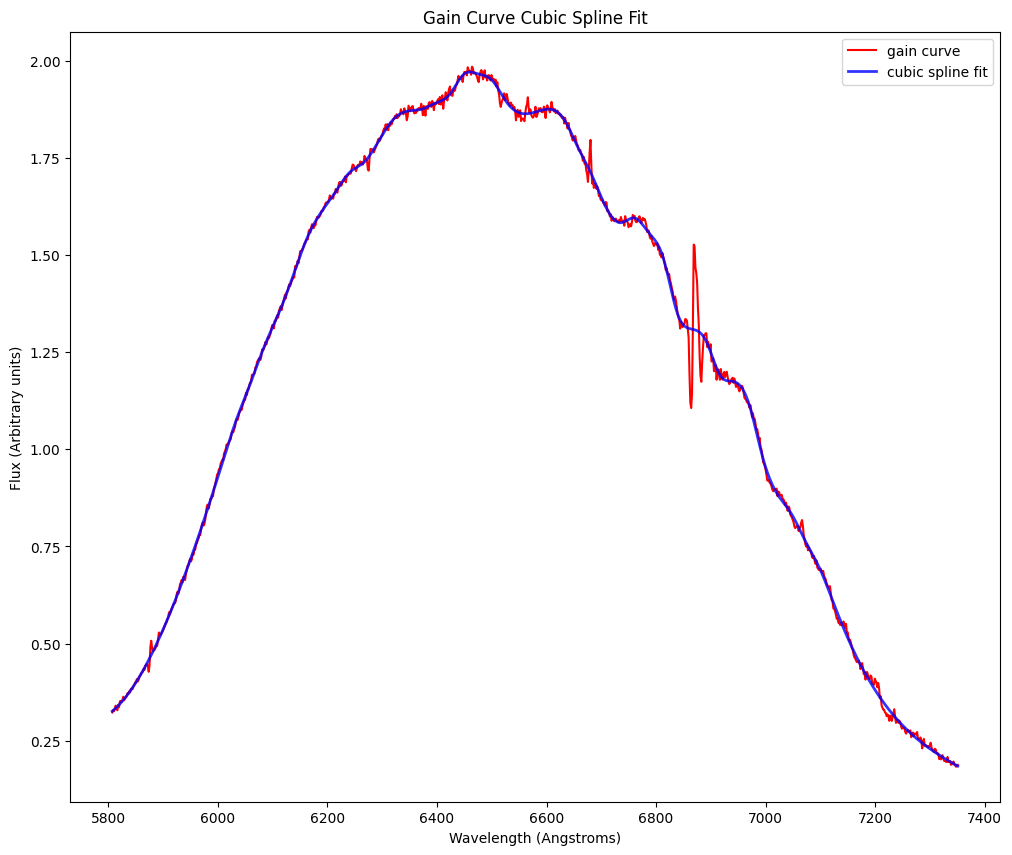

In [ ]:
# Sanity check reconstruction

import pandas as pd
from scipy.interpolate import CubicSpline

df = pd.read_csv("grism_calib/gain_curves.csv")

g = df[df["grism"] == "highres"].sort_values("wavelength")

gain_spline = CubicSpline(
    g["wavelength"].values,
    g["gain"].values,
    bc_type="natural"
)

gain_corrected = gain_spline(wave_grid[mask])

plt.figure(figsize = (12,10))
plt.plot(wave_grid[mask], gain[mask], color = 'red', label = 'gain curve')
# plt.plot(g["wavelength"].values, g["gain"].values, color = 'blue', alpha = 0.8, linewidth = 2, label = 'cubic spline fit')
plt.plot(wave_grid[mask], gain_corrected, color = 'blue', alpha = 0.8, linewidth = 2, label = 'cubic spline fit')
plt.xlabel('Wavelength (Angstroms)')
plt.ylabel('Flux (Arbitrary units)')
plt.title('Gain Curve Cubic Spline Fit')
# plt.xlim(6200,7000)
# plt.ylim(0,2)
plt.legend()
plt.show()


# Use NIST Database Wavelengths for Various Elements to Identify Spectral Features

## Get spectral line info from nist_lines.csv

You will have to put the nist_lines.csv file into a directory of your choice 
then specify the location with nistpath

In [49]:
# Import and read in nist_lines.csv

nistpath = os.path.expanduser('~/gdrive/My Drive/PHYS491-user/Grism_Workbench/')

df = pd.read_csv(nistpath+'nist_lines.csv')
# print(df[['Element', 'Wavelength', 'Name']])
# sort the df by wavelength:
df = df.sort_values(by=['Wavelength'])
print(df[['Element', 'Wavelength', 'Name']])
# print # of transitions loaded:
print(f"Number of transitions loaded: {len(df)}")

   Element  Wavelength               Name
0      C I  5800.59993   C I (5800.59993)
19   Fe II  5807.66610  Fe II (5807.6661)
45    S II  5819.23800    S II (5819.238)
36    He I  5875.61397  He I (5875.61397)
37    He I  5875.61484  He I (5875.61484)
38    He I  5875.62510  He I (5875.62510)
39    He I  5875.64036  He I (5875.64036)
20   Fe II  5885.01440  Fe II (5885.0144)
41    Na I  5889.95094  Na I (5889.95094)
42    Na I  5895.92424  Na I (5895.92424)
21   Fe II  5902.82310  Fe II (5902.8231)
22   Fe II  5914.54700  Fe II (5914.5470)
23   Fe II  5961.70550  Fe II (5961.7055)
1      C I  5969.33151   C I (5969.33151)
2      C I  6001.12300     C I (6001.123)
3      C I  6006.01200     C I (6006.012)
4      C I  6013.16600     C I (6013.166)
5      C I  6013.25180    C I (6013.2518)
6      C I  6016.44870    C I (6016.4487)
43     S I  6052.70400     S I (6052.704)
46    S II  6286.34600    S II (6286.346)
47    S II  6286.95100    S II (6286.951)
48    S II  6305.47900    S II (63

In [52]:
# Define the wavelengths and names to replace (He has a bunch of stuff close together)
he_lines = ['He I (5875.61397)', 'He I (5875.61484)', 'He I (5875.6251)', 'He I (5875.64036)']
blend_name = 'He I (5875.621)'
blend_wavelength = 5875.621

# Update 'Name' and 'Wavelength' for specified He I lines
df.loc[df['Name'].isin(he_lines), 'Name'] = blend_name
df.loc[df['Name'] == blend_name, 'Wavelength'] = blend_wavelength

# Remove duplicates
df = df.drop_duplicates(subset=['Element', 'Wavelength', 'Name'])

# Print the updated DataFrame
pd.set_option('display.max_rows', None)  # Show all rows
print(df[['Element', 'Wavelength', 'Name']])

# Print the number of transitions loaded
print(f"Number of transitions loaded: {len(df)}")

   Element  Wavelength               Name
0      C I  5800.59993   C I (5800.59993)
19   Fe II  5807.66610  Fe II (5807.6661)
45    S II  5819.23800    S II (5819.238)
36    He I  5875.62100    He I (5875.621)
38    He I  5875.62510  He I (5875.62510)
20   Fe II  5885.01440  Fe II (5885.0144)
41    Na I  5889.95094  Na I (5889.95094)
42    Na I  5895.92424  Na I (5895.92424)
21   Fe II  5902.82310  Fe II (5902.8231)
22   Fe II  5914.54700  Fe II (5914.5470)
23   Fe II  5961.70550  Fe II (5961.7055)
1      C I  5969.33151   C I (5969.33151)
2      C I  6001.12300     C I (6001.123)
3      C I  6006.01200     C I (6006.012)
4      C I  6013.16600     C I (6013.166)
5      C I  6013.25180    C I (6013.2518)
6      C I  6016.44870    C I (6016.4487)
43     S I  6052.70400     S I (6052.704)
46    S II  6286.34600    S II (6286.346)
47    S II  6286.95100    S II (6286.951)
48    S II  6305.47900    S II (6305.479)
49    S II  6312.66600    S II (6312.666)
54   Si II  6347.11000    Si II (6

## Plot Spectral Line Info on Calibrated Spectrum and Locate Features

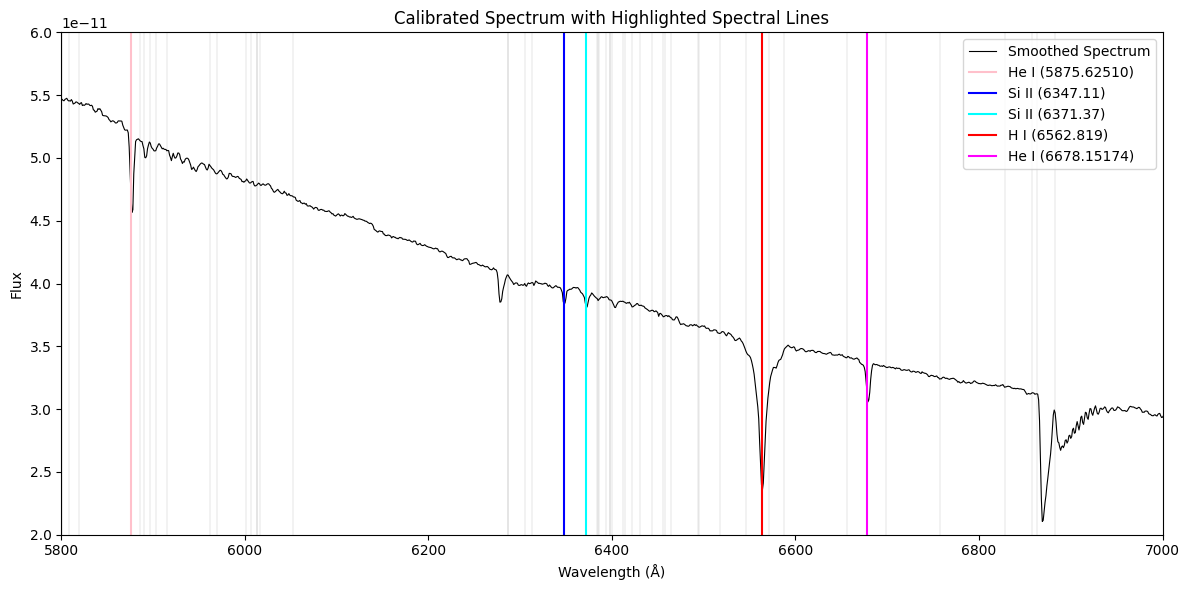

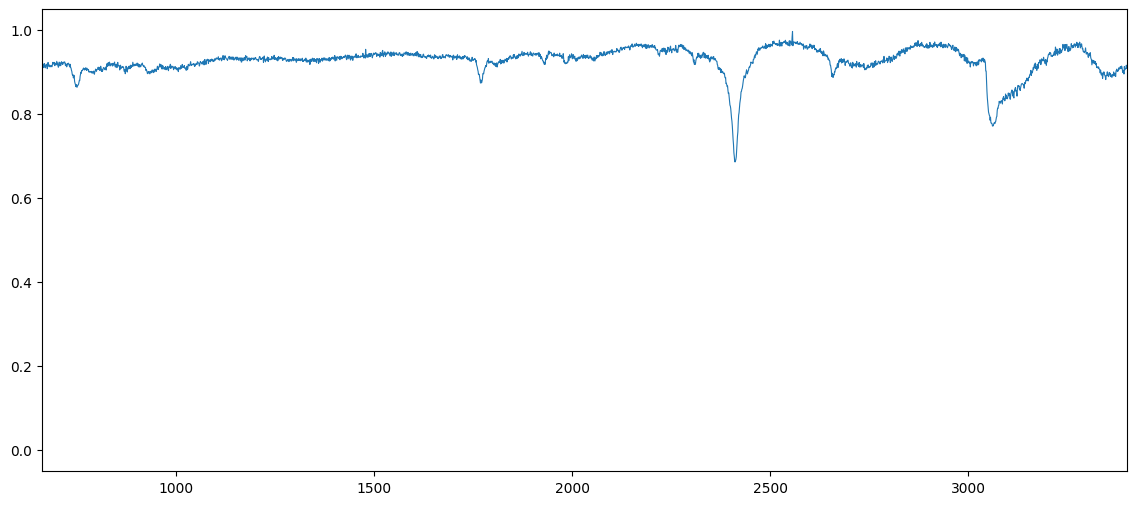

In [58]:
z = (rv*u.km/u.s+radial_vel_correction)/c # For wavelength correction

# Selected line names and their highlight colors
# selected_names = ['He I (5875.621)', 'Si II (6347.11)', 'Si II (6371.37)',
#                   'Fe II (6517.0293)', 'H I (6562.819)', 'He I (6678.15174)']
selected_names = ['He I (5875.62510)', 'Si II (6347.11)', 'Si II (6371.37)',
                  'H I (6562.819)', 'He I (6678.15174)']
selected_colors = ['pink', 'blue', 'cyan', 'red', 'magenta']

# Optional: apply a smoothing if you want, or leave raw
smoothed_spectrum = np.convolve(spectrum_out, np.ones(3)/3, mode='valid')
x_smoothed = calibrated_spectrum[1:-1]

plt.figure(figsize=(12, 6))

# Plot spectrum
# plt.plot(calibrated_spectrum, spectrum_out, color='gray', alpha=0.4, linewidth=0.5)
# plt.plot(x_smoothed, smoothed_spectrum, color='black', linewidth=0.8, label='Smoothed Spectrum')
plt.plot(jwaves, fluxes, color='black', linewidth=0.8, label='Smoothed Spectrum')


# Plot all lines from df as faint black vertical lines
for _, row in df.iterrows():
    plt.axvline(x=row['Wavelength'] * (1 + z), color='k', linestyle='-', linewidth=0.25, alpha=0.3)

# Highlight selected lines
for i, name in enumerate(selected_names):
    line = df[df['Name'] == name]
    if not line.empty:
        wavelength = line['Wavelength'].values[0] * (1 + z)
        plt.axvline(x=wavelength, color=selected_colors[i], linestyle='-', linewidth=1.5, alpha=1.0, label=name)

# Include any additional lines you think are apparent from the spectral atlas and/or NIST
    # Spectral atlas: https://drive.google.com/drive/folders/18H0q-meNZUt-ChXLOdYd9F55-uaTUqEE
    # NIST: https://physics.nist.gov/PhysRefData/ASD/lines_form.html
# plt.axvline(x = 6137.691*(1 + z), color = 'magenta', linewidth = 1, label = 'Fe I (6137.691)')
# plt.axvline(x = 6230.7219*(1 + z), color = 'red', linewidth = 1, label = 'Fe I (6230.7219)')

plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.xlim(5800, 7000)
plt.ylim(0.2e-10, 0.6e-10)
plt.title("Calibrated Spectrum with Highlighted Spectral Lines")
# plt.legend(bbox_to_anchor=(1.05, 1), loc='lower left')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

plt.figure(figsize = (14,6))
plt.plot(norm_spectrum,linewidth = 0.8)
plt.xlim(660,3400)
plt.show()


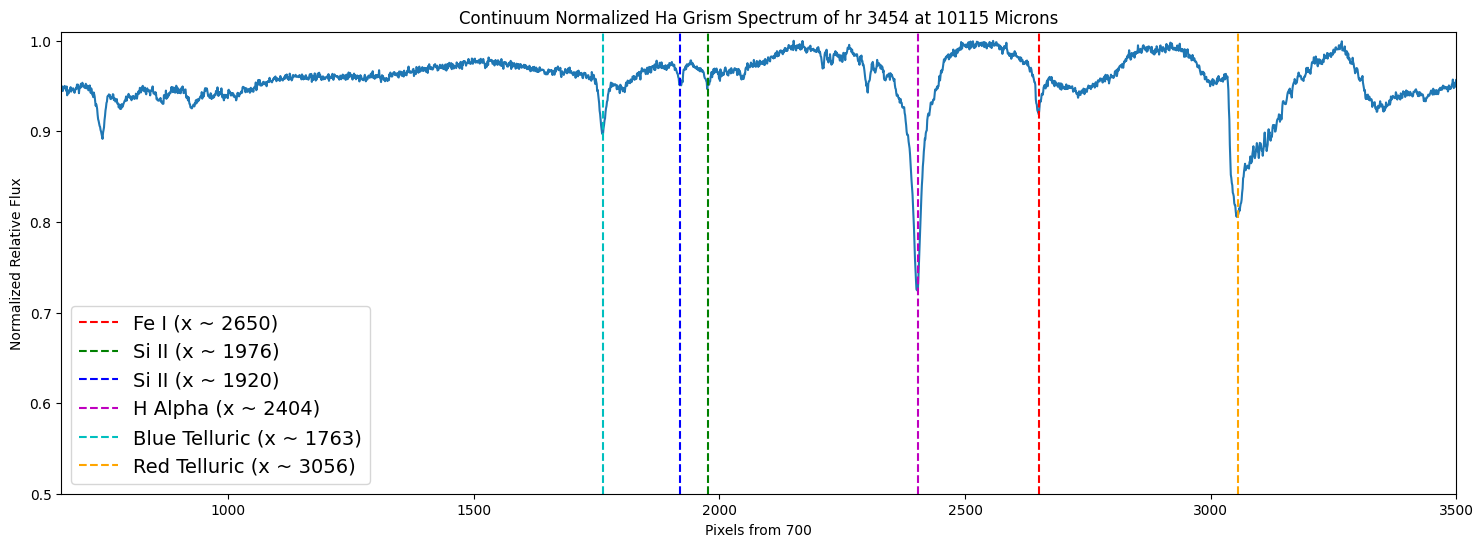

In [72]:
# Use this as a plot to find a rough pixel location of features to use as a guess point then actually fit those features in the code below

shift = -15

plt.figure(figsize=(18, 6))
plt.plot(norm_spectrum)
plt.title(f'Continuum Normalized Ha Grism Spectrum of {target_name} at 10115 Microns')
plt.xlabel('Pixels from 700')
plt.ylabel('Normalized Relative Flux')
# Plot vertical lins at pixel locations of spectral features
plt.axvline(x=2665 + shift, color='r', linestyle='--', label = f'Fe I (x ~ {2665 + shift})')
plt.axvline(x=1991 + shift, color='g', linestyle='--', label = f'Si II (x ~ {1991 + shift})')
plt.axvline(x=1935 + shift, color='b', linestyle='--', label = f'Si II (x ~ {1935 + shift})')
plt.axvline(x=2419 + shift, color='m', linestyle='--', label = f'H Alpha (x ~ {2419 + shift})')
# plt.axvline(x=2183 + shift, color='y', linestyle='--', label = f'Fe II (x ~ {2183 + shift})')
# plt.axvline(x=2318 + shift, color='k', linestyle='--', label = f'Fe II (x ~ {2318 + shift})')

# Make a list to iterate over (match to axvline placements)
pixel_guesses = [1935 + shift, 1991 + shift, 2665 + shift, 2419 + shift] # Do not include relluric lines in this list

plt.axvline(x=1778 + shift, color='c', linestyle='--', label = f'Blue Telluric (x ~ {1778 + shift})')
plt.axvline(x=3071 + shift, color='orange', linestyle='--', label = f'Red Telluric (x ~ {3071 + shift})')

telluric_guesses = [1778 + shift, 3071 + shift] 

plt.xlim(660,3500)
# Set vertical limits
plt.ylim(0.5, 1.01)
plt.legend(fontsize = 14, loc = 'lower left')
plt.show()

# Fit Lines to Spectral Features

In [73]:
# Here are the functions to fit features

def gaussian(x, a, x0, sigma, offset):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2)) + offset

def fit_feature(spec_cont, peak_center, width, height, width_guess=None):
    xmin, xmax = peak_center - width, peak_center + width
    peaks, _ = find_peaks(spec_cont[xmin:xmax], height=height, distance=10)
    if width_guess is None:
        width_guess = width
    x = np.arange(xmin, xmax)
    y = spec_cont[xmin:xmax]
    p0 = [height, peak_center, width_guess, 1]
    popt, pcov = curve_fit(gaussian, x, y, p0=p0)

    # Plot
    plt.figure(figsize=(15,5))
    plt.plot(x, y)
    plt.plot(x, gaussian(x, *popt))
    plt.title('Fit of absorption line')
    plt.xlabel('Pixel')
    plt.ylabel('Normalized intensity')
    plt.show()
    return popt



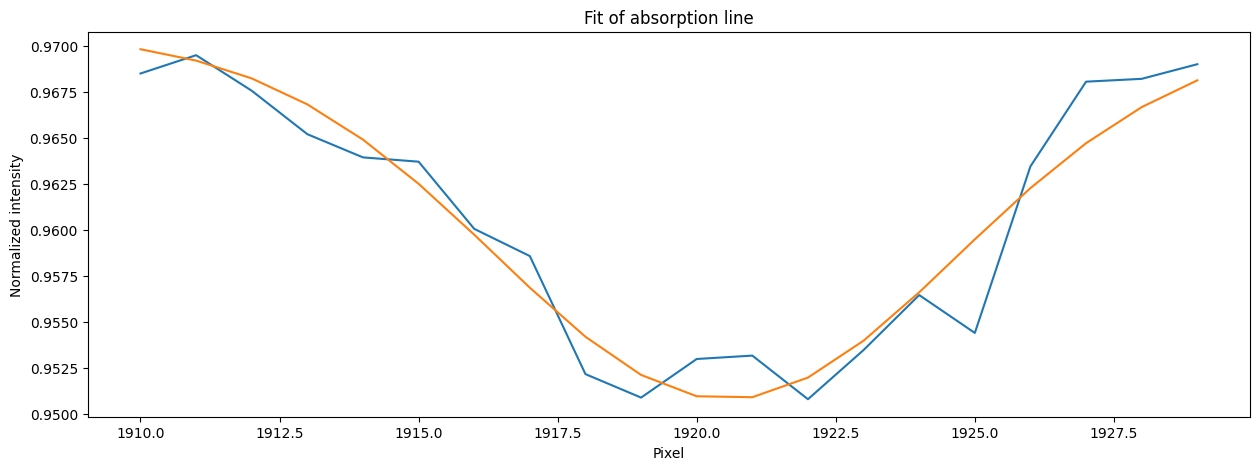

FWHM: 9.76
Peak center: 1920.5441721139543


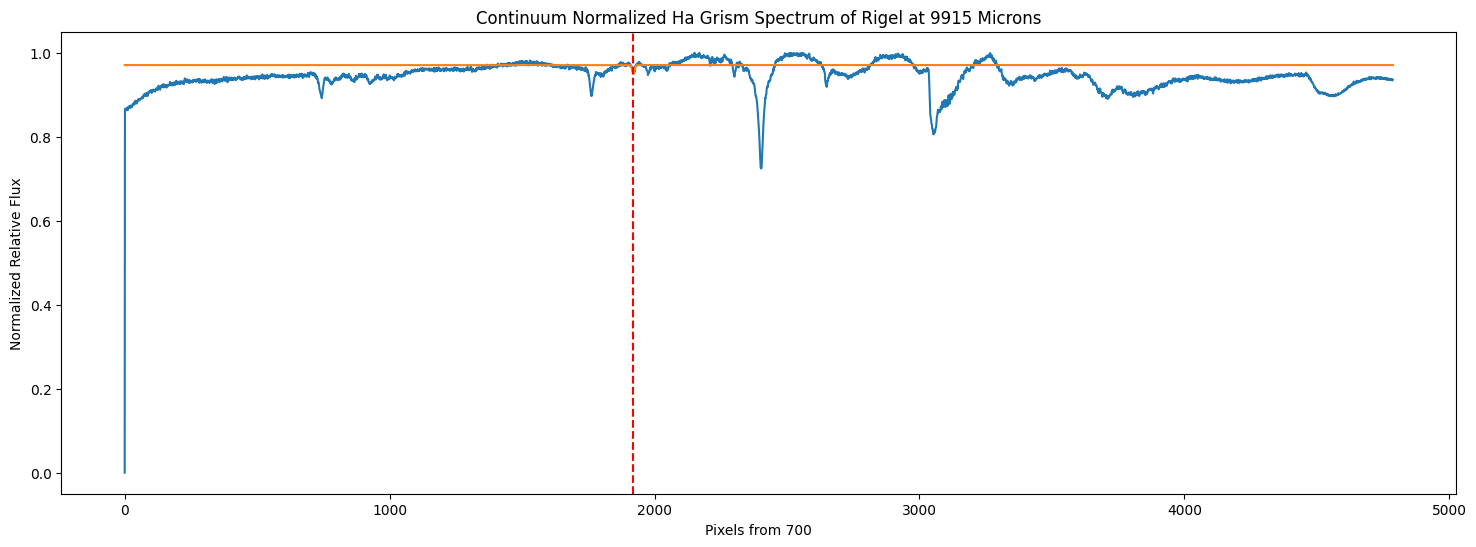

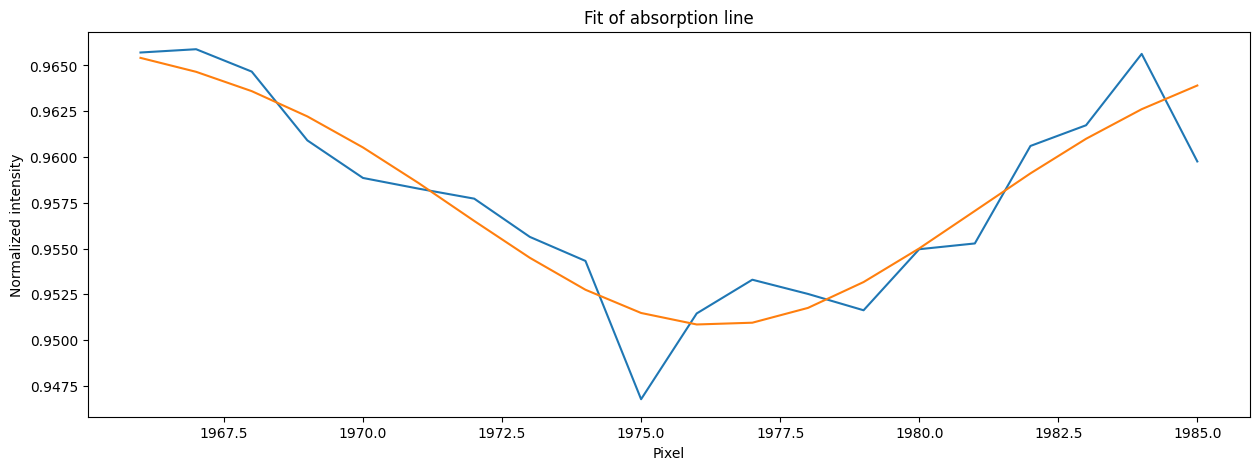

FWHM: 10.92
Peak center: 1976.368553452646


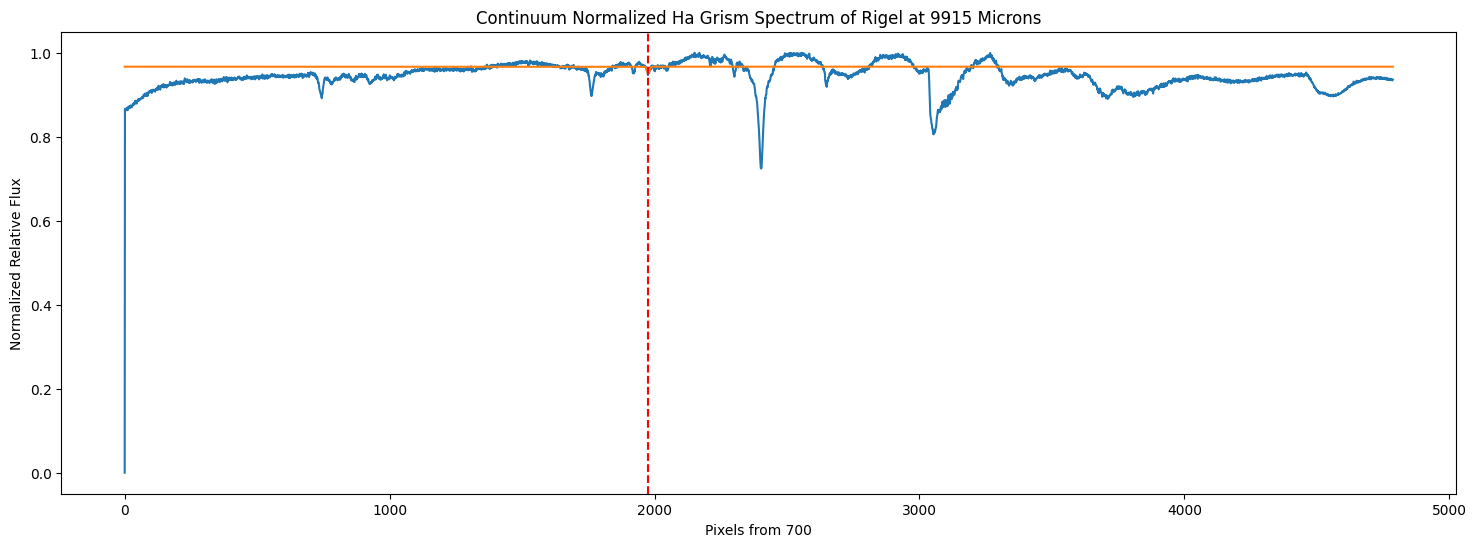

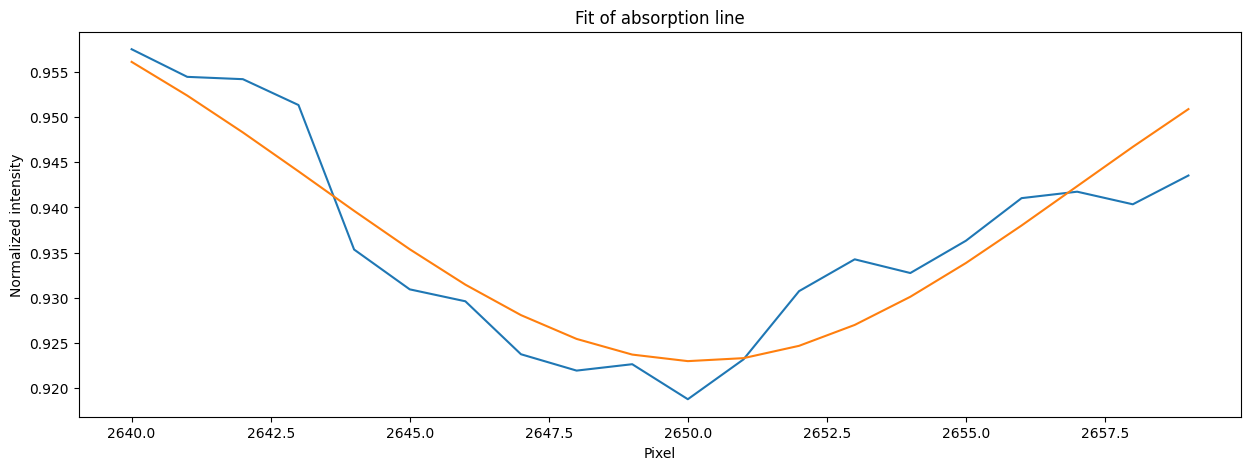

FWHM: 16.02
Peak center: 2650.1878394941355


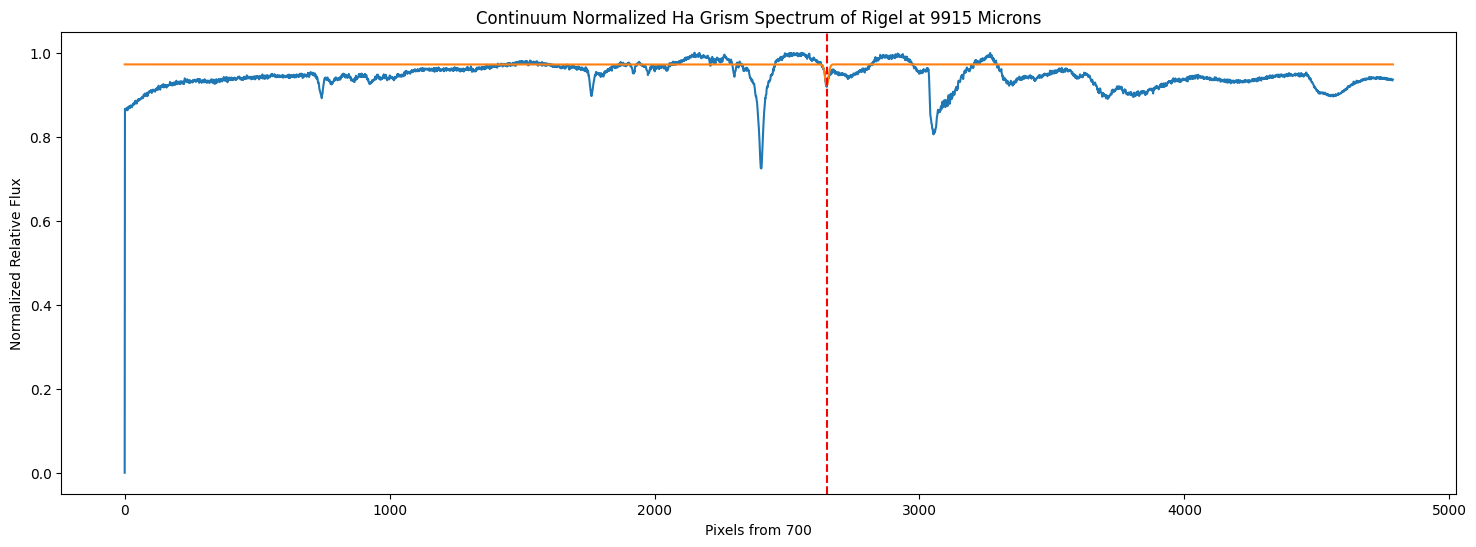

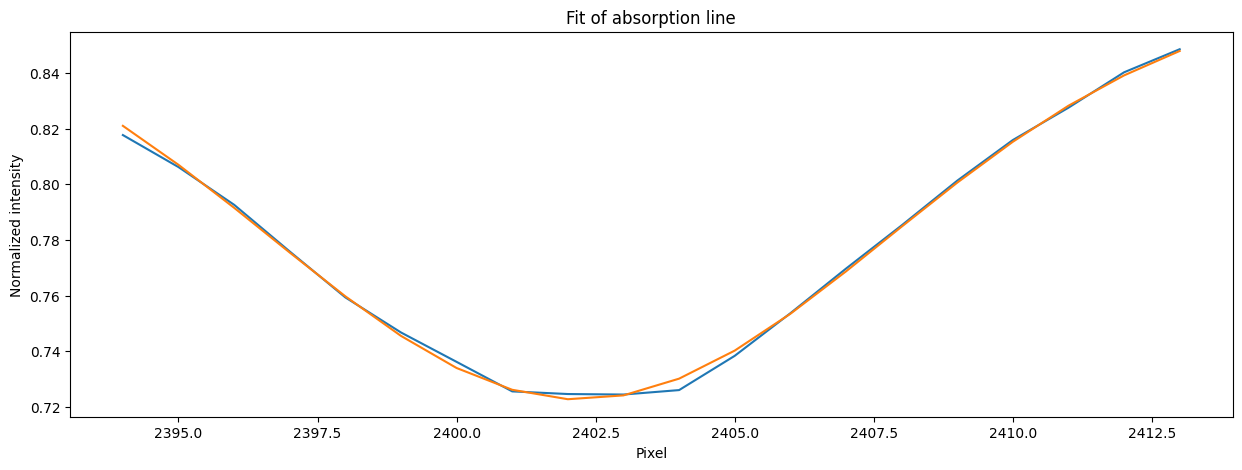

FWHM: 13.02
Peak center: 2402.2121921943926


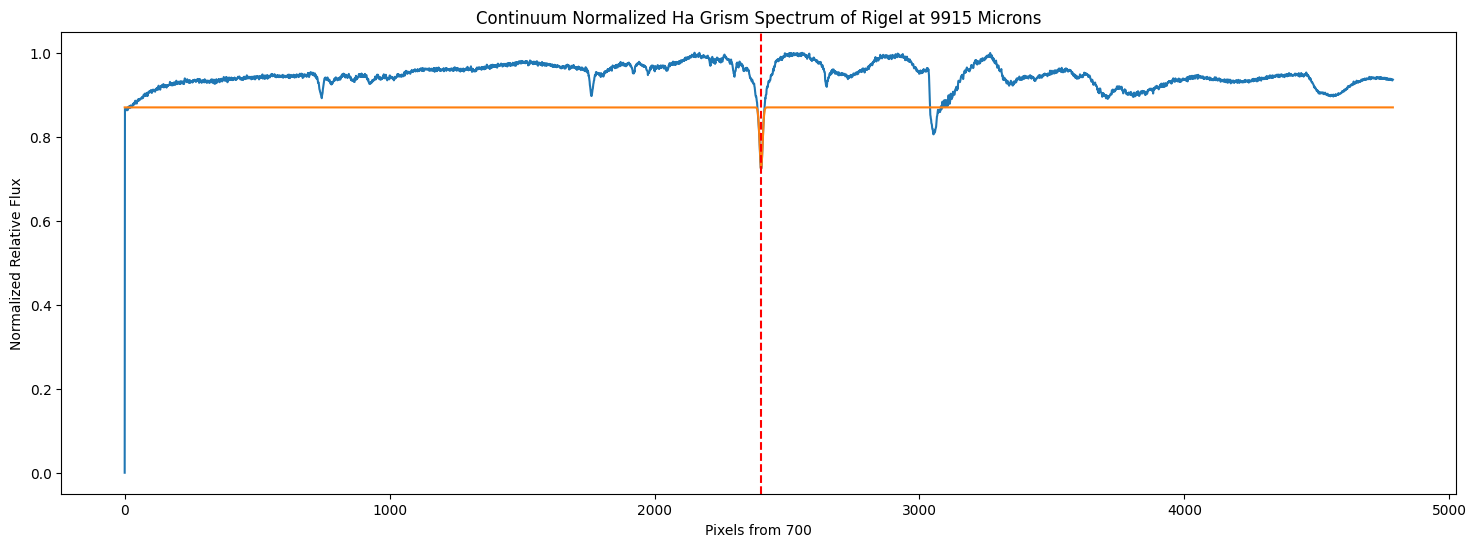

In [74]:
peak_centers = []

for pixel_guess in pixel_guesses:
    popt = fit_feature(norm_spectrum, pixel_guess, 10, -1)
    fwhm = 2 * np.sqrt(2 * np.log(2)) * popt[2]
    print(f"FWHM: {fwhm:.2f}")
    print(f"Peak center: {popt[1]}")

    peak_centers.append(popt[1])

    plt.figure(figsize=(18, 6))
    plt.plot(norm_spectrum)
    plt.plot(gaussian(np.arange(norm_spectrum.shape[0]), *popt))
    plt.title('Continuum Normalized Ha Grism Spectrum of Rigel at 9915 Microns')
    plt.xlabel('Pixels from 700')
    plt.ylabel('Normalized Relative Flux')
    plt.axvline(x=popt[1], color='r', linestyle='--')
    plt.show()

peak_centers.sort()

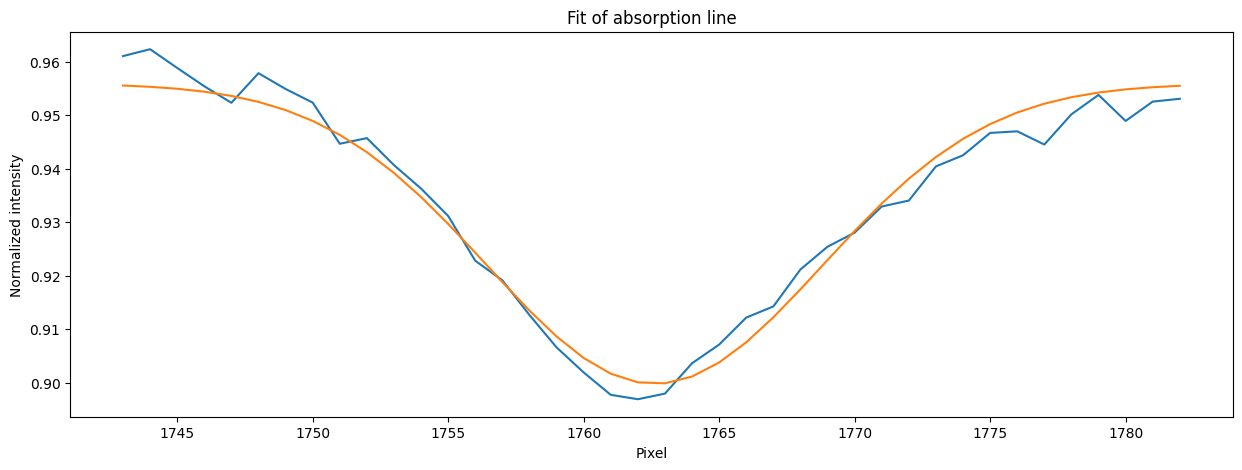

FWHM: 13.02
Peak center: 1762.6246019799426


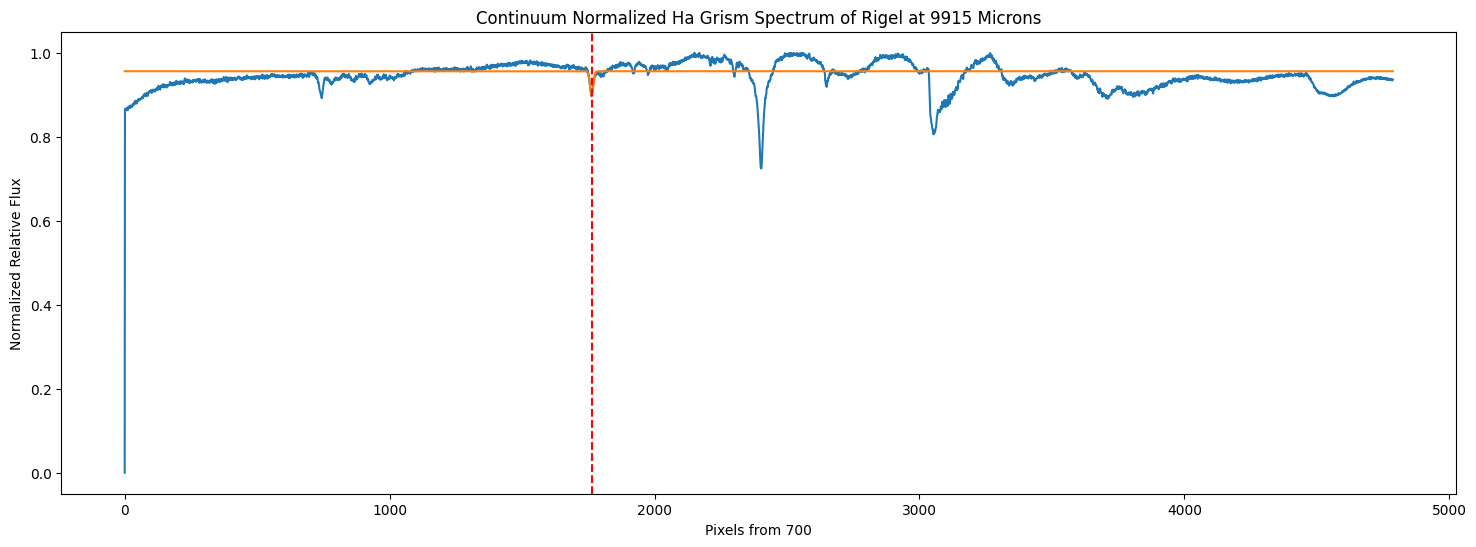

In [75]:
# Fit the blue telluric features

telluric_guesses.sort()

bt_popt = fit_feature(norm_spectrum, telluric_guesses[0], 20, -1)

fwhm = 2 * np.sqrt(2 * np.log(2)) * popt[2]
print(f"FWHM: {fwhm:.2f}")
print(f"Peak center: {bt_popt[1]}")

plt.figure(figsize=(18, 6))
plt.plot(norm_spectrum)
plt.plot(gaussian(np.arange(norm_spectrum.shape[0]), *bt_popt))
plt.title('Continuum Normalized Ha Grism Spectrum of Rigel at 9915 Microns')
plt.xlabel('Pixels from 700')
plt.ylabel('Normalized Relative Flux')
plt.axvline(x=bt_popt[1], color='r', linestyle='--')
plt.show()

In [76]:
# Make a list of the wavelengths in the selected_names list

wavelengths = [float(name.split('(')[-1].rstrip(')')) for name in selected_names]

print(wavelengths)

[6347.11, 6371.37, 6562.819, 6678.15174]


In [77]:
# Apply wavelength correction due to the Earth's motion and target's recessional velocity

corrected_wavelengths = []
n_air = 1.000293

for entry in wavelengths:
    corrected_wavelengths.append(float(np.round(entry*wavelength_correction*n_air,3)))

In [78]:
# Append the wavelength list with telluric features

btel_peak_center = bt_popt[1]
btel_wavelength = 6280.4
peak_centers.append(btel_peak_center)
corrected_wavelengths.append(btel_wavelength)

rtel_peak_center = telluric_x
rtel_wavelength = 6873.1
peak_centers.append(rtel_peak_center)
corrected_wavelengths.append(rtel_wavelength)

## Check everything lines up with plots in pixel space

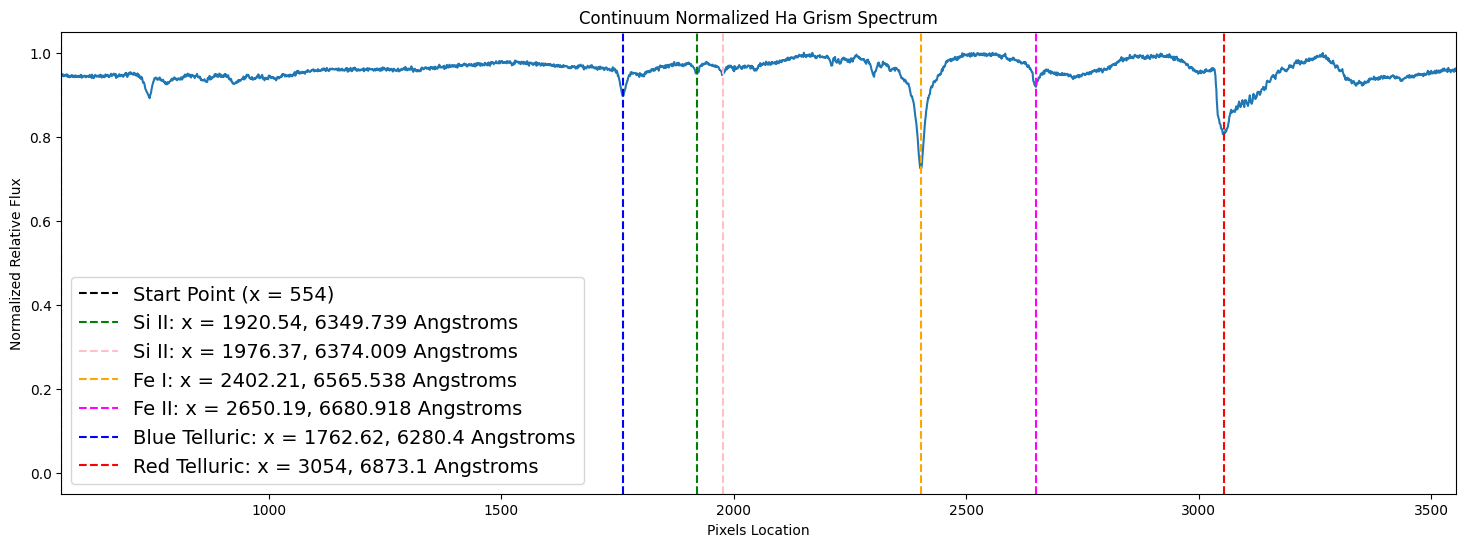

In [79]:
#Plot everything in pixel space to confirm

plt.figure(figsize=(18, 6))
plt.plot(norm_spectrum)
# plt.scatter(telluric_x,norm_spectrum[int(telluric_x)],color = 'r',marker = 'x', label = 'Telluric Line')
plt.axvline(x = telluric_x - 2500, color = 'black', linestyle = '--', label = f'Start Point (x = {telluric_x-2500})')

plt.axvline(x = peak_centers[0], color = 'green', linestyle = '--', label = f'Si II: x = {np.round(peak_centers[0],2)}, {corrected_wavelengths[0]} Angstroms')
plt.axvline(x = peak_centers[1], color = 'pink', linestyle = '--', label = f'Si II: x = {np.round(peak_centers[1],2)}, {corrected_wavelengths[1]} Angstroms')
plt.axvline(x = peak_centers[2], color = 'orange', linestyle = '--', label = f'Fe I: x = {np.round(peak_centers[2],2)}, {corrected_wavelengths[2]} Angstroms')
plt.axvline(x = peak_centers[3], color = 'magenta', linestyle = '--', label = f'Fe II: x = {np.round(peak_centers[3],2)}, {corrected_wavelengths[3]} Angstroms')
# plt.axvline(x = peak_centers[4], color = 'cyan', linestyle = '--', label = f'Ha: x = {np.round(peak_centers[4],2)}, {corrected_wavelengths[4]} Angstroms')
# plt.axvline(x = peak_centers[5], color = 'purple', linestyle = '--', label = f'Na I: x = {np.round(peak_centers[5],2)}, {corrected_wavelengths[5]} Angstroms')

plt.axvline(x = peak_centers[4], color = 'blue', linestyle = '--', label = f'Blue Telluric: x = {np.round(peak_centers[4],2)}, {corrected_wavelengths[4]} Angstroms')
plt.axvline(x = peak_centers[5], color = 'red', linestyle = '--', label = f'Red Telluric: x = {np.round(peak_centers[5],2)}, {corrected_wavelengths[5]} Angstroms')

plt.title('Continuum Normalized Ha Grism Spectrum')
plt.xlabel('Pixels Location')
plt.ylabel('Normalized Relative Flux')
plt.xlim(telluric_x-2500, telluric_x+500)
plt.legend(fontsize = 14, loc = 'lower left')
plt.show()


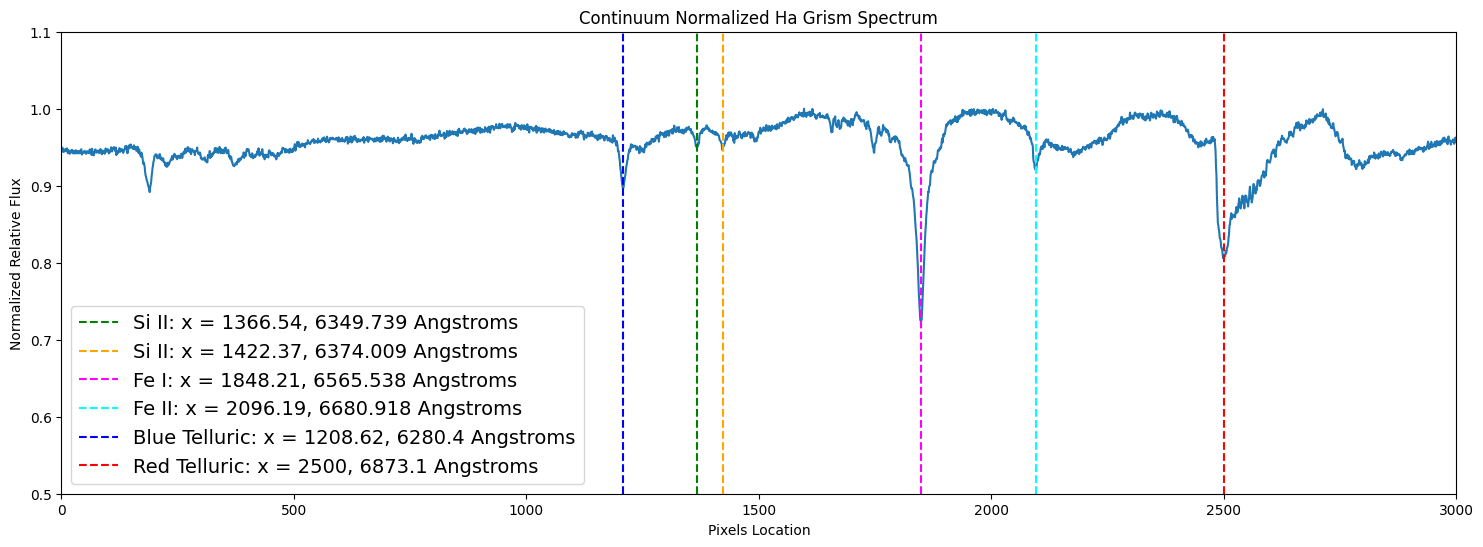

In [80]:
# Set the red telluric point as an anchor point at 2500 pixels for an effective extraction box

start_point = int(telluric_x - 2500)

extract_spectrum = norm_spectrum[start_point:]

extract_peak_centers = []

for entry in peak_centers:
    extract_peak_centers.append(entry-start_point)

#Plot everything in pixel space now for extract

plt.figure(figsize=(18, 6))
plt.plot(norm_spectrum[start_point:])
# plt.scatter(telluric_x-start_point,norm_spectrum[start_point:][int(telluric_x-start_point)],color = 'r',marker = 'x', label = 'Telluric Line')

plt.axvline(x = extract_peak_centers[0], color = 'green', linestyle = '--', label = f'Si II: x = {np.round(extract_peak_centers[0],2)}, {corrected_wavelengths[0]} Angstroms')
plt.axvline(x = extract_peak_centers[1], color = 'orange', linestyle = '--', label = f'Si II: x = {np.round(extract_peak_centers[1],2)}, {corrected_wavelengths[1]} Angstroms')
plt.axvline(x = extract_peak_centers[2], color = 'magenta', linestyle = '--', label = f'Fe I: x = {np.round(extract_peak_centers[2],2)}, {corrected_wavelengths[2]} Angstroms')
plt.axvline(x = extract_peak_centers[3], color = 'cyan', linestyle = '--', label = f'Fe II: x = {np.round(extract_peak_centers[3],2)}, {corrected_wavelengths[3]} Angstroms')
# plt.axvline(x = extract_peak_centers[4], color = 'yellow', linestyle = '--', label = f'Fe II: x = {np.round(extract_peak_centers[4],2)}, {corrected_wavelengths[4]} Angstroms')
# plt.axvline(x = extract_peak_centers[5], color = 'purple', linestyle = '--', label = f'Ha: x = {np.round(extract_peak_centers[5],2)}, {corrected_wavelengths[5]} Angstroms')

plt.axvline(x = extract_peak_centers[4], color = 'blue', linestyle = '--', label = f'Blue Telluric: x = {np.round(extract_peak_centers[4],2)}, {corrected_wavelengths[4]} Angstroms')
plt.axvline(x = extract_peak_centers[5], color = 'red', linestyle = '--', label = f'Red Telluric: x = {np.round(extract_peak_centers[5],2)}, {corrected_wavelengths[5]} Angstroms')

plt.ylim(0.5,1.1)
plt.title('Continuum Normalized Ha Grism Spectrum')
plt.xlabel('Pixels Location')
plt.ylabel('Normalized Relative Flux')
plt.xlim(0,3000)
plt.legend(fontsize = 14, loc = 'lower left')
plt.show()


In [81]:
extract_peak_centers.sort()
wavelengths.sort()
corrected_wavelengths.sort()

print(f"Pixel Peak Centers: {extract_peak_centers}")
print(f'Wavelengths: {wavelengths}')
print(f'Corrected + Telluric Wavelengths: {corrected_wavelengths}')

Pixel Peak Centers: [np.float64(1208.6246019799426), np.float64(1366.5441721139543), np.float64(1422.368553452646), np.float64(1848.2121921943926), np.float64(2096.1878394941355), 2500]
Wavelengths: [6347.11, 6371.37, 6562.819, 6678.15174]
Corrected + Telluric Wavelengths: [6280.4, 6349.739, 6374.009, 6565.538, 6680.918, 6873.1]


# Derive Wavelength Calibration


=== Fit Report ===
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 9
    # data points      = 6
    # variables        = 3
    chi-square         = 0.19406903
    reduced chi-square = 0.06468968
    Akaike info crit   = -14.5878050
    Bayesian info crit = -15.2125266
[[Variables]]
    a:  1.9779e-05 +/- 6.5108e-07 (3.29%) (init = 1e-06)
    b:  0.38553341 +/- 0.00240846 (0.62%) (init = 0)
    c:  5785.67509 +/- 2.10669227 (0.04%) (init = 6469.773)
[[Correlations]] (unreported correlations are < 0.100)
    C(a, b) = -0.9955
    C(b, c) = -0.9943
    C(a, c) = +0.9808

R^2 = 0.999999

Pixel location of H-alpha = 1841.700
New solution λ at Hα pixel  = 6562.8000 Å
Old solution λ at Hα pixel  = 6559.5995 Å
Difference (new - old)       = 3.2005 Å
Uncertainty at Hα pixel     = ±0.1767 Å


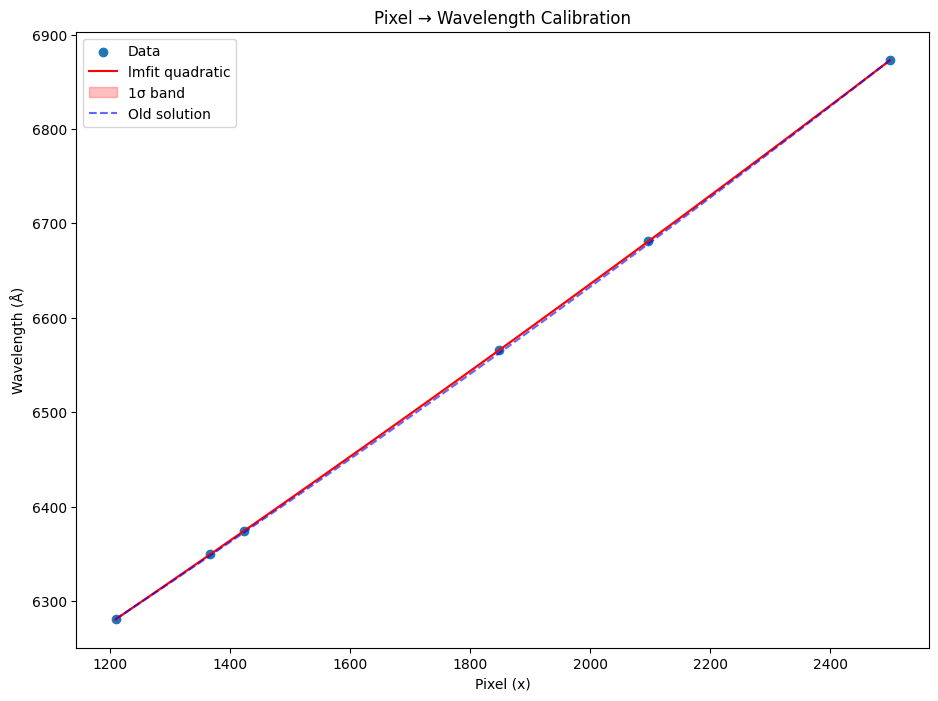

In [82]:
from lmfit import Minimizer, Parameters, report_fit

# ---------------------------------------------------------
# Data
# ---------------------------------------------------------
xdata = np.asarray(extract_peak_centers)
ydata = np.asarray(corrected_wavelengths)

# Pixel grid for visualization
low = int(np.min(xdata))
high = int(np.max(xdata))
xplot = np.linspace(low, high, high-low+1)

# ---------------------------------------------------------
# lmfit model
# ---------------------------------------------------------
def residual(params, x, data):
    a = params['a'].value
    b = params['b'].value
    c = params['c'].value
    return a*x**2 + b*x + c - data

params = Parameters()
params.add('a', value=1e-6)
params.add('b', value=0.0)
params.add('c', value=np.median(ydata))

mini = Minimizer(residual, params, fcn_args=(xdata, ydata))
result = mini.minimize()

print("\n=== Fit Report ===")
report_fit(result)

a = result.params['a'].value
b = result.params['b'].value
c = result.params['c'].value

# Best-fit curve
yfit = a*xplot**2 + b*xplot + c

# ---------------------------------------------------------
# R^2 calculation
# ---------------------------------------------------------
resid = ydata - (a*xdata**2 + b*xdata + c)
ss_res = np.sum(resid**2)
ss_tot = np.sum((ydata - np.mean(ydata))**2)
r2 = 1 - ss_res/ss_tot
print(f"\nR^2 = {r2:.6f}")

# ---------------------------------------------------------
# Parameter covariance → uncertainty propagation
# ---------------------------------------------------------
cov = result.covar
if cov is None:
    print("WARNING: covariance matrix unavailable — uncertainties cannot be computed.")
else:
    # Build Jacobian for every pixel in xplot
    J = np.vstack([xplot**2, xplot, np.ones_like(xplot)])  # (3,N)
    var_y = np.einsum('ij,jk,ik->i', J.T, cov, J.T)
    sigma_y = np.sqrt(np.maximum(var_y,0))

# ---------------------------------------------------------
# OLD wavelength solution
# ---------------------------------------------------------
def old_solution(x):
    return 5809.515939 + 0.3564304348*x + 0.00002760895652*x**2

# ---------------------------------------------------------
# FIND PIXEL COORDINATE OF H-alpha
# new solution solves a*x^2 + b*x + (c - 6562.8) = 0
# ---------------------------------------------------------
Hα = 6562.8
coeffs = [a, b, c - Hα]
roots = np.roots(coeffs)

# pick the real root inside pixel range
x_Ha = roots[np.isreal(roots)].real
x_Ha = x_Ha[(x_Ha>=low) & (x_Ha<=high)]
if len(x_Ha) == 0:
    print("Could not determine x-pixel for H-alpha inside fit range.")
    x_Ha = None
else:
    x_Ha = float(x_Ha[0])
    print(f"\nPixel location of H-alpha = {x_Ha:.3f}")

    # wavelength from both solutions
    new_λ_Ha = a*x_Ha**2 + b*x_Ha + c
    old_λ_Ha = old_solution(x_Ha)
    diff_Ha = new_λ_Ha - old_λ_Ha

    print(f"New solution λ at Hα pixel  = {new_λ_Ha:.4f} Å")
    print(f"Old solution λ at Hα pixel  = {old_λ_Ha:.4f} Å")
    print(f"Difference (new - old)       = {diff_Ha:.4f} Å")

    # uncertainty at that pixel
    if cov is not None:
        J_Ha = np.array([x_Ha**2, x_Ha, 1.0])
        var_Ha = J_Ha.T @ cov @ J_Ha
        sigma_Ha = np.sqrt(np.maximum(var_Ha, 0))
        print(f"Uncertainty at Hα pixel     = ±{sigma_Ha:.4f} Å")

# ---------------------------------------------------------
# Plotting
# ---------------------------------------------------------
plt.figure(figsize=(11,8))
plt.scatter(xdata, ydata, label='Data')
plt.plot(xplot, yfit, 'r', label='lmfit quadratic')

if cov is not None:
    plt.fill_between(xplot, yfit - sigma_y, yfit + sigma_y,
                     alpha=0.25, color='red', label='1σ band')

plt.plot(xplot, old_solution(xplot), 'b--', alpha=0.6, label='Old solution')
plt.xlabel('Pixel (x)')
plt.ylabel('Wavelength (Å)')
plt.title('Pixel → Wavelength Calibration')
plt.legend()
plt.show()

## (Optional): Check r-squared value

In [44]:
from sklearn.metrics import r2_score

poly_func = np.poly1d(p)  # Create a polynomial function from coefficients

# Generate predicted values
y_pred = poly_func(extract_peak_centers)

# Compute R-squared value
r_squared = r2_score(corrected_wavelengths, y_pred)

# Print results
print(f"Quadratic Coefficients: {p}")
print(f"Quadratic Equation: {poly_func}")
print(f"R^2: {r_squared:.8f}")

# Plot data and quadratic fit
plt.scatter(extract_peak_centers, corrected_wavelengths, label="Data Points", color='blue')
x_fit = np.linspace(min(extract_peak_centers), max(extract_peak_centers), 100)  # Smooth curve
y_fit = poly_func(x_fit)
plt.plot(x_fit, y_fit, label="Quadratic Fit", color='red')
plt.xlabel("Extract Peak Centers")
plt.ylabel("Corrected Wavelengths")
plt.legend()
plt.title("Quadratic Fit to Peak Centers vs. Wavelengths")
plt.show()


ModuleNotFoundError: No module named 'sklearn'

# Test New Wavelength Calibration

In [83]:
# This wavelength calibration is now based on your selected target

def new_wavelength_calibrate(spectra, a, b, c):
    spectrum = spectra
    pixel = np.arange(len(spectrum))
    wavelength = c + b * pixel + a * (pixel)**2
    calibrated_spectra = wavelength
    spectrum_out = spectrum
    plt.figure(figsize=(14, 6))
    plt.plot(wavelength[:len(spectrum)-10], spectrum[:len(spectrum)-10])

    plt.axvline(x = 6873.1, label='Red Telluric Line (6873.1 Angstroms)', color='red', linestyle='--')
    plt.axvline(x = 6280.4, label='Blue Telluric Line (6280.4 Angstroms)', color='blue', linestyle='--')
    plt.axvline(x = 6562.8*wavelength_correction*n_air, color = 'pink', linestyle = '--', label = f'H Alpha ({np.round(6562.8*wavelength_correction,3)} Angstroms)')

    plt.xlim(6200,7000)
    plt.ylim(np.min(spectrum) - np.std(spectrum), np.max(spectrum) + np.std(spectrum))
    plt.xlabel('Wavelength (Angstroms)')
    plt.ylabel('Intensity')
    plt.title('Calibrated Spectrum')
    plt.legend(loc = 'upper right')
    plt.show()
    return calibrated_spectra, spectrum_out

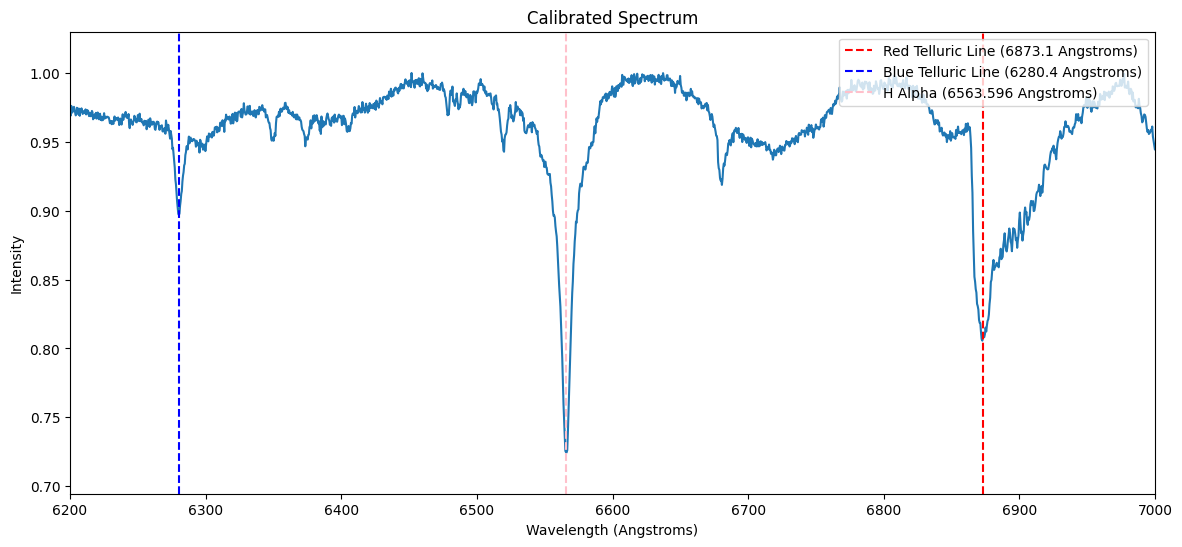

(array([5785.67509461, 5786.0606478 , 5786.44624055, ..., 7770.94055708,
        7771.49348139, 7772.04644526], shape=(4234,)),
 array([0.94952625, 0.9446436 , 0.94455004, ..., 0.93387157, 0.9352674 ,
        0.93594074], shape=(4234,), dtype=float32))

In [84]:
# See if Ha and the telluric lines match up!

new_wavelength_calibrate(norm_spectrum[telluric_x-2500:],a, b, c)

[1.97791450e-05 3.85533408e-01 5.78567509e+03]


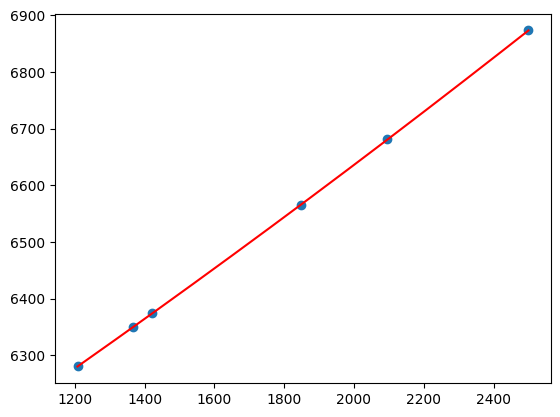

In [85]:
low = int(np.min(extract_peak_centers))
high = int(np.max(extract_peak_centers))
x = np.linspace(low, high, high-low)

fit = np.polyfit(extract_peak_centers, corrected_wavelengths, 2)
fitline = fit[0]*x**2 + fit[1]*x + fit[2]

# fit = np.polyfit(extract_peak_centers, corrected_wavelengths, 1)
# fitline = fit[0]*x + fit[1]

print(fit)

plt.scatter(extract_peak_centers, corrected_wavelengths)
plt.plot(x,fitline, color = 'red')

In [86]:
# Fit 2nd order polynomial to the peak centers
p = np.polyfit(extract_peak_centers, corrected_wavelengths, 2)
print(p)

[1.97791450e-05 3.85533408e-01 5.78567509e+03]


In [87]:
print(' a = '+str(np.round(p[0],9)))
print(' b = '+str(np.round(p[1],4)))
print(' c = '+str(np.round(p[2],4)))
print(f'Red Telluric: x = '+str(telluric_x))

 a = 1.9779e-05
 b = 0.3855
 c = 5785.6751
Red Telluric: x = 3054


# Flux Calibration

## Gain Curve Derivation

In [88]:
def load_stelib_spectrum(star_name, folder_path):
    """
    Load STELIB spectrum from a CSV file given a star name and folder path.

    Parameters:
    - star_name: str, like 'HD135722'
    - folder_path: str, full path to the folder in Google Drive containing the CSVs

    Returns:
    - df: Pandas DataFrame with columns 'wavelength' and 'flux'
    """
    # Build expected filename
    # Remove underscores in star names
    star_name = star_name.replace('_', '')
    for file in os.listdir(folder_path):
        if star_name in file and file.endswith('.csv'):
            file_path = os.path.join(folder_path, file)
            df = pd.read_csv(file_path)
            return df
    raise FileNotFoundError(f"No file found for star: {star_name}")

def match_and_interpolate(waves_data, flux_data, waves_ref_orig, flux_ref_orig, num_points=1000):
    """
    Safely interpolate both observed and reference spectra to a common grid.
    """
    # Copy reference arrays to avoid in-place modification
    waves_ref = np.copy(waves_ref_orig)
    flux_ref = np.copy(flux_ref_orig)

    # Ensure all arrays are 1D numpy arrays
    waves_data = np.array(waves_data).flatten()
    flux_data = np.array(flux_data).flatten()
    waves_ref = np.array(waves_ref).flatten()
    flux_ref = np.array(flux_ref).flatten()

    # Check that arrays match in size before interpolating
    if len(waves_data) != len(flux_data):
        raise ValueError(f"waves_data and flux_data lengths do not match: {len(waves_data)} vs {len(flux_data)}")
    if len(waves_ref) != len(flux_ref):
        raise ValueError(f"waves_ref and flux_ref lengths do not match: {len(waves_ref)} vs {len(flux_ref)}")

    # Determine overlapping wavelength range
    min_wave = max(np.min(waves_data), np.min(waves_ref))
    max_wave = min(np.max(waves_data), np.max(waves_ref))

    if min_wave >= max_wave:
        raise ValueError("No overlapping wavelength region between data and reference.")

    # Define common wavelength grid
    wave_grid = np.linspace(min_wave, max_wave, num_points)

    # Interpolate both spectra onto the same grid
    flux_data_interp = np.interp(wave_grid, waves_data, flux_data)
    flux_ref_interp = np.interp(wave_grid, waves_ref, flux_ref)

    return wave_grid, flux_data_interp, flux_ref_interp

In [89]:
from astropy.io import fits
import pandas as pd
import numpy as np

file = "STELIB/stelib_spec_fits_HR3454_moy.fits"

with fits.open(file) as hdul:
    flux = hdul[0].data.astype(float)   # 1D flux array, length 6700

# Reconstruct wavelength array (STELIB standard grid)
wavelength = np.linspace(3200, 3200 + (len(flux)-1), len(flux))

# Build DataFrame
df = pd.DataFrame({
    "Wavelength": wavelength,
    "Flux": flux
})

df.to_csv("STELIB/STELIB_HR3454_B3V.csv", index=False)

   Wavelength          Flux
0      3200.0  1.646954e-10
1      3201.0  1.677373e-10
2      3202.0  1.658288e-10
3      3203.0  1.630109e-10
4      3204.0  1.615926e-10


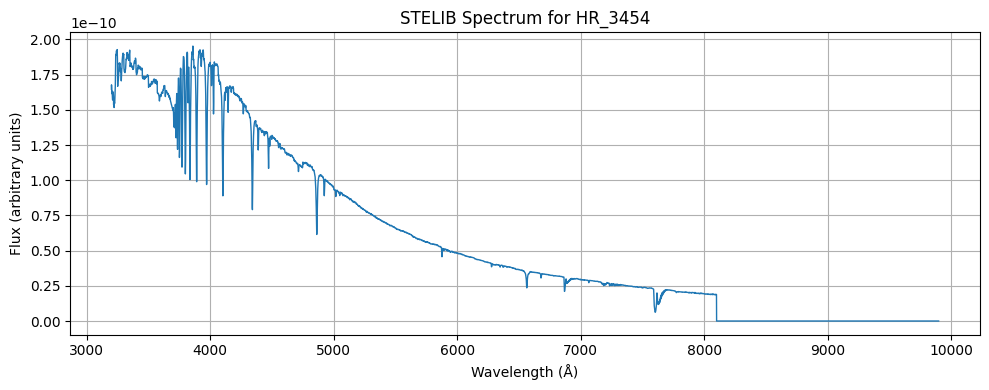

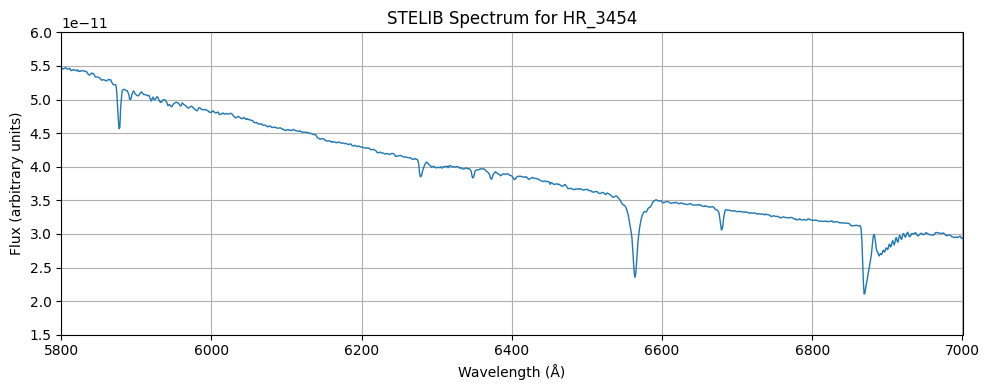

In [ ]:
cal_star = 'HR_3454'

spectrum_df = load_stelib_spectrum(cal_star, 'STELIB')
jwaves,fluxes = spectrum_df['Wavelength'], spectrum_df['Flux']

print(spectrum_df.head())

plt.figure(figsize=(10, 4))
plt.plot(spectrum_df['Wavelength'], spectrum_df['Flux'], lw=1)
plt.xlabel('Wavelength (Å)')
plt.ylabel('Flux (arbitrary units)')
plt.title(f'STELIB Spectrum for {cal_star}')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(spectrum_df['Wavelength'], spectrum_df['Flux'], lw=1)
plt.xlabel('Wavelength (Å)')
plt.ylabel('Flux (arbitrary units)')
plt.title(f'STELIB Spectrum for {cal_star}')
plt.xlim(5800,7000)
plt.ylim(0.15e-10,0.6e-10)
plt.grid(True)
plt.tight_layout()
plt.show()

In [171]:
# Here are the functions to fit features

def gaussian(x, a, x0, sigma, offset):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2)) + offset

def fit_feature(spec_cont, peak_center, width, height, width_guess=None):
    xmin, xmax = peak_center - width, peak_center + width
    peaks, _ = find_peaks(spec_cont[xmin:xmax], height=height, distance=10)
    if width_guess is None:
        width_guess = width
    x = np.arange(xmin, xmax)
    y = spec_cont[xmin:xmax]
    p0 = [height, peak_center, width_guess, 1]
    popt, pcov = curve_fit(gaussian, x, y, p0=p0)

    # Plot
    plt.figure(figsize=(15,5))
    plt.plot(x, y)
    plt.plot(x, gaussian(x, *popt))
    plt.title('Fit of absorption line')
    plt.xlabel('Pixel')
    plt.ylabel('Normalized intensity')
    plt.show()
    return popt

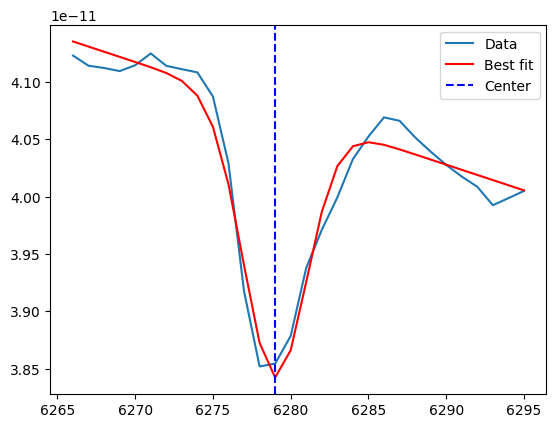

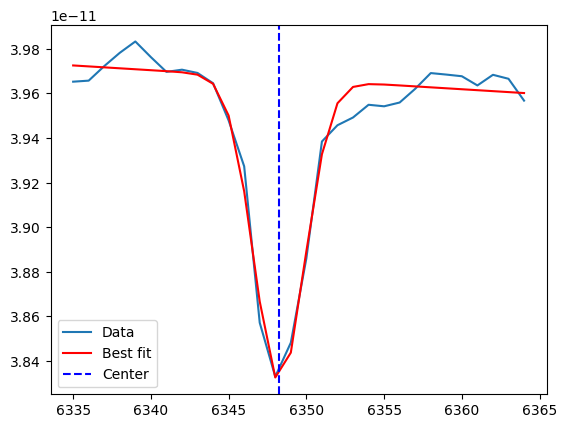

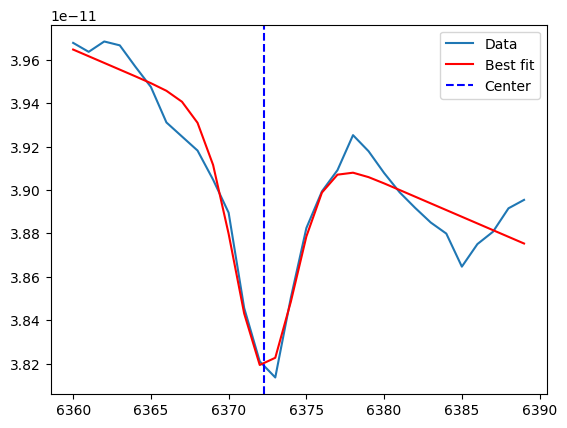

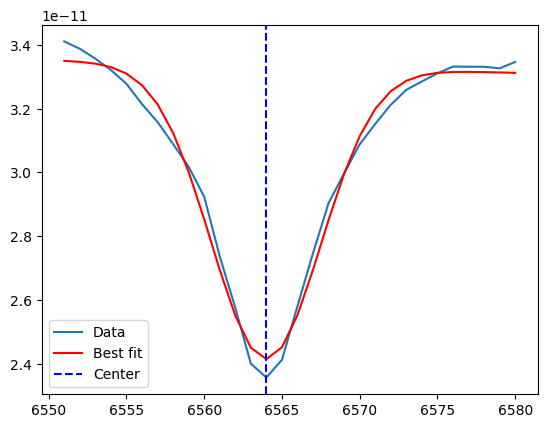

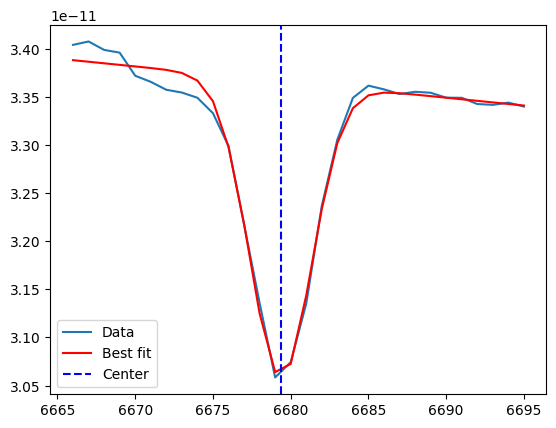

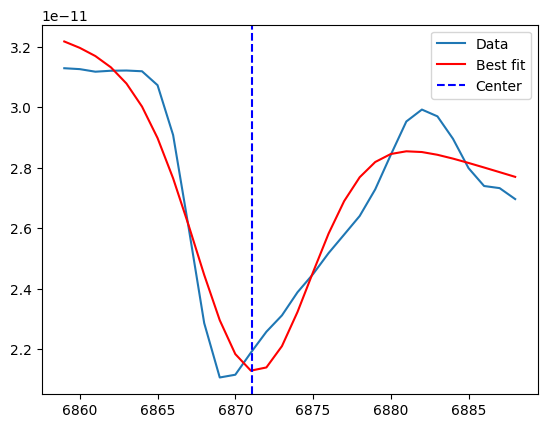

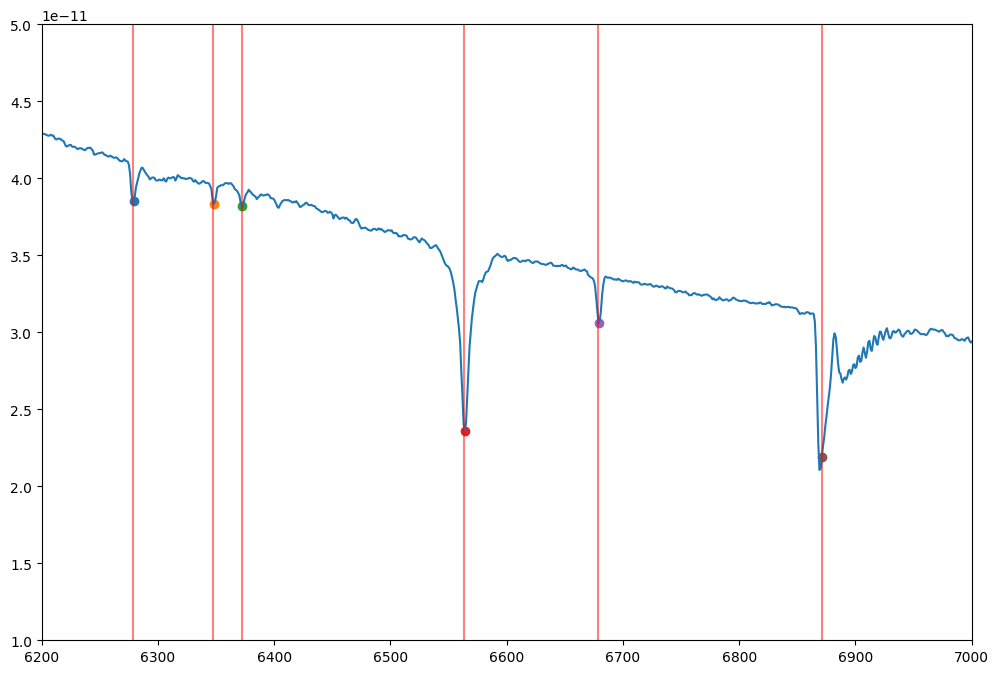

In [223]:
import numpy as np
from lmfit.models import GaussianModel, LinearModel

gauss = GaussianModel(prefix='g_')
linear = LinearModel(prefix='b_')
model = gauss + linear

wave_ref = spectrum_df['Wavelength'].to_numpy()
flux_ref = spectrum_df['Flux'].to_numpy()

fit_centers = []
fit_results = []

for w0 in corrected_wavelengths:
    # Select fitting window in WAVELENGTH space
    mask = (wave_ref > w0 - 15) & (wave_ref < w0 + 15)

    x = wave_ref[mask]
    y = flux_ref[mask]

    # Create parameters with good initial guesses
    params = model.make_params(
        g_amplitude=y.min() - y.max(),   # absorption line
        g_center=w0,
        g_sigma=2.0,
        b_slope=0.0,
        b_intercept=np.median(y)
    )

    # Optional but recommended bounds
    params['g_center'].set(min=w0 - 5, max=w0 + 5)
    params['g_sigma'].set(min=0.1, max=10)

    result = model.fit(y, params, x=x)

    plt.plot(x, y, label='Data')
    plt.plot(x, result.best_fit, 'r-', label='Best fit')
    plt.axvline(result.params['g_center'].value, color='b', linestyle='--', label='Center')
    plt.legend()
    plt.show()

    fit_centers.append(result.params['g_center'].value)
    fit_results.append(result)

plt.figure(figsize = (12,8))
plt.plot(wave_ref, flux_ref)
plt.xlim(6200,7000)
plt.ylim(0.1e-10, 0.5e-10)
for wavelength in corrected_wavelengths:
    plt.axvline(wavelength-2, color = 'red', alpha = 0.5)
for fit_center in fit_centers:
    plt.scatter(fit_center, flux_ref[np.argmin(np.abs(wave_ref-fit_center))])
plt.show()


=== Fit Report ===
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 9
    # data points      = 5
    # variables        = 3
    chi-square         = 0.22300957
    reduced chi-square = 0.11150478
    Akaike info crit   = -9.54989256
    Bayesian info crit = -10.7215788
[[Variables]]
    a:  2.1333e-05 +/- 2.1497e-06 (10.08%) (init = 1e-06)
    b:  0.38035105 +/- 0.00715106 (1.88%) (init = 0)
    c:  5788.27151 +/- 5.72461208 (0.10%) (init = 6372.276)
[[Correlations]] (unreported correlations are < 0.100)
    C(a, b) = -0.9980
    C(b, c) = -0.9977
    C(a, c) = +0.9918

R^2 = 0.999998

Pixel location of H-alpha = 1845.355
New solution λ at Hα pixel  = 6562.8000 Å
Old solution λ at Hα pixel  = 6561.2742 Å
Difference (new - old)       = 1.5258 Å
Uncertainty at Hα pixel     = ±0.2557 Å


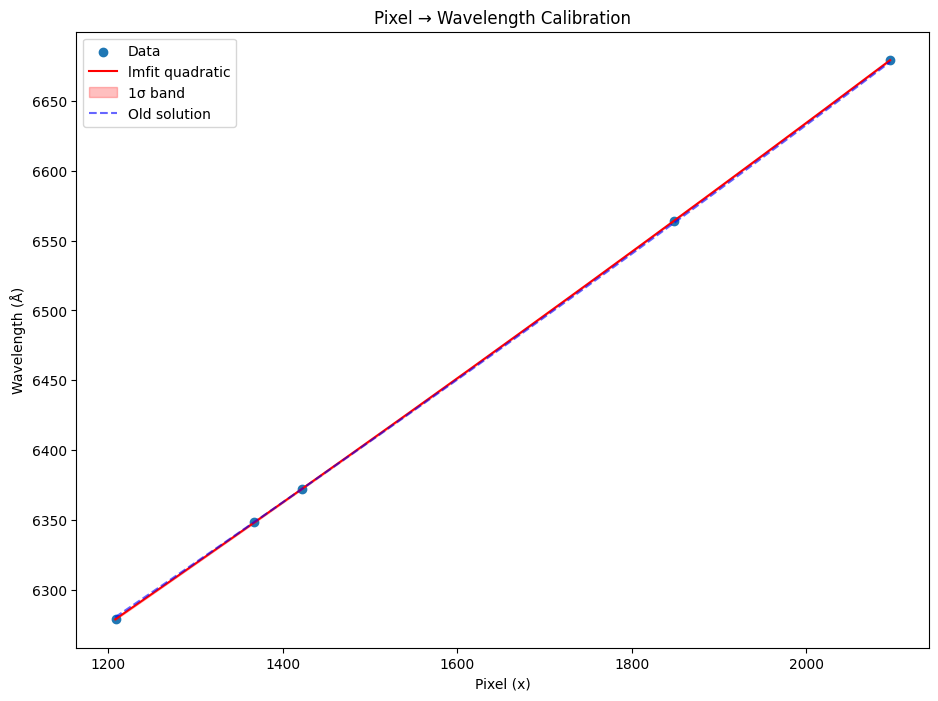

In [225]:
from lmfit import Minimizer, Parameters, report_fit

# ---------------------------------------------------------
# Data
# ---------------------------------------------------------
xdata = np.asarray(extract_peak_centers)
ydata = np.asarray(fit_centers)

# Pixel grid for visualization
low = int(np.min(xdata))
high = int(np.max(xdata))
xplot = np.linspace(low, high, high-low+1)

# ---------------------------------------------------------
# lmfit model
# ---------------------------------------------------------
def residual(params, x, data):
    a = params['a'].value
    b = params['b'].value
    c = params['c'].value
    return a*x**2 + b*x + c - data

params = Parameters()
params.add('a', value=1e-6)
params.add('b', value=0.0)
params.add('c', value=np.median(ydata))

mini = Minimizer(residual, params, fcn_args=(xdata, ydata))
result = mini.minimize()

print("\n=== Fit Report ===")
report_fit(result)

a = result.params['a'].value
b = result.params['b'].value
c = result.params['c'].value

# Best-fit curve
yfit = a*xplot**2 + b*xplot + c

# ---------------------------------------------------------
# R^2 calculation
# ---------------------------------------------------------
resid = ydata - (a*xdata**2 + b*xdata + c)
ss_res = np.sum(resid**2)
ss_tot = np.sum((ydata - np.mean(ydata))**2)
r2 = 1 - ss_res/ss_tot
print(f"\nR^2 = {r2:.6f}")

# ---------------------------------------------------------
# Parameter covariance → uncertainty propagation
# ---------------------------------------------------------
cov = result.covar
if cov is None:
    print("WARNING: covariance matrix unavailable — uncertainties cannot be computed.")
else:
    # Build Jacobian for every pixel in xplot
    J = np.vstack([xplot**2, xplot, np.ones_like(xplot)])  # (3,N)
    var_y = np.einsum('ij,jk,ik->i', J.T, cov, J.T)
    sigma_y = np.sqrt(np.maximum(var_y,0))

# ---------------------------------------------------------
# OLD wavelength solution
# ---------------------------------------------------------
def old_solution(x):
    return 5809.515939 + 0.3564304348*x + 0.00002760895652*x**2

# ---------------------------------------------------------
# FIND PIXEL COORDINATE OF H-alpha
# new solution solves a*x^2 + b*x + (c - 6562.8) = 0
# ---------------------------------------------------------
Hα = 6562.8
coeffs = [a, b, c - Hα]
roots = np.roots(coeffs)

# pick the real root inside pixel range
x_Ha = roots[np.isreal(roots)].real
x_Ha = x_Ha[(x_Ha>=low) & (x_Ha<=high)]
if len(x_Ha) == 0:
    print("Could not determine x-pixel for H-alpha inside fit range.")
    x_Ha = None
else:
    x_Ha = float(x_Ha[0])
    print(f"\nPixel location of H-alpha = {x_Ha:.3f}")

    # wavelength from both solutions
    new_λ_Ha = a*x_Ha**2 + b*x_Ha + c
    old_λ_Ha = old_solution(x_Ha)
    diff_Ha = new_λ_Ha - old_λ_Ha

    print(f"New solution λ at Hα pixel  = {new_λ_Ha:.4f} Å")
    print(f"Old solution λ at Hα pixel  = {old_λ_Ha:.4f} Å")
    print(f"Difference (new - old)       = {diff_Ha:.4f} Å")

    # uncertainty at that pixel
    if cov is not None:
        J_Ha = np.array([x_Ha**2, x_Ha, 1.0])
        var_Ha = J_Ha.T @ cov @ J_Ha
        sigma_Ha = np.sqrt(np.maximum(var_Ha, 0))
        print(f"Uncertainty at Hα pixel     = ±{sigma_Ha:.4f} Å")

# ---------------------------------------------------------
# Plotting
# ---------------------------------------------------------
plt.figure(figsize=(11,8))
plt.scatter(xdata, ydata, label='Data')
plt.plot(xplot, yfit, 'r', label='lmfit quadratic')

if cov is not None:
    plt.fill_between(xplot, yfit - sigma_y, yfit + sigma_y,
                     alpha=0.25, color='red', label='1σ band')

plt.plot(xplot, old_solution(xplot), 'b--', alpha=0.6, label='Old solution')
plt.xlabel('Pixel (x)')
plt.ylabel('Wavelength (Å)')
plt.title('Pixel → Wavelength Calibration')
plt.legend()
plt.show()

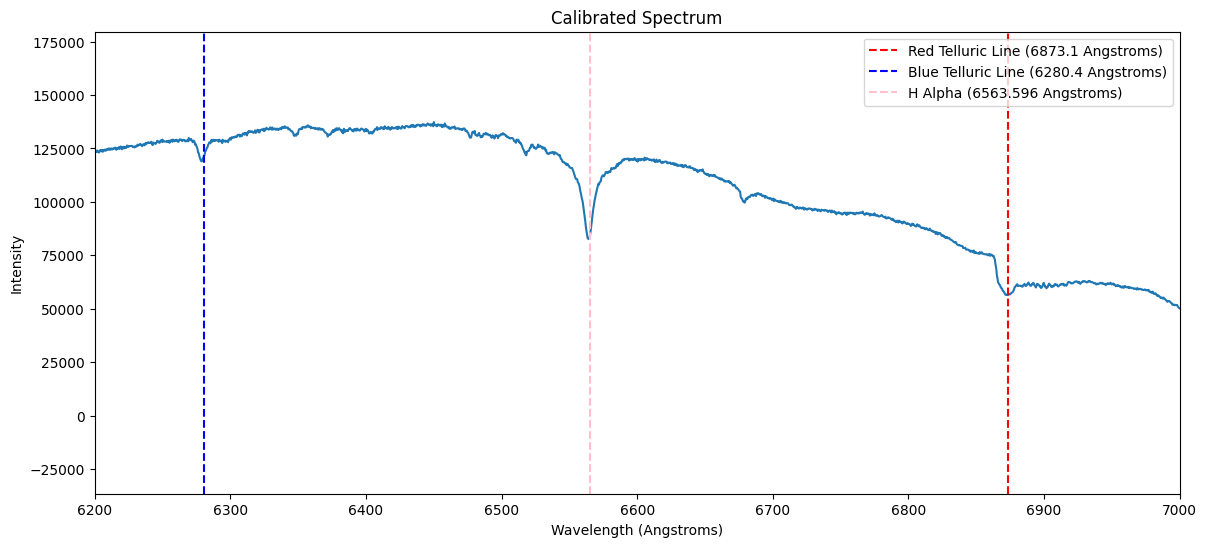

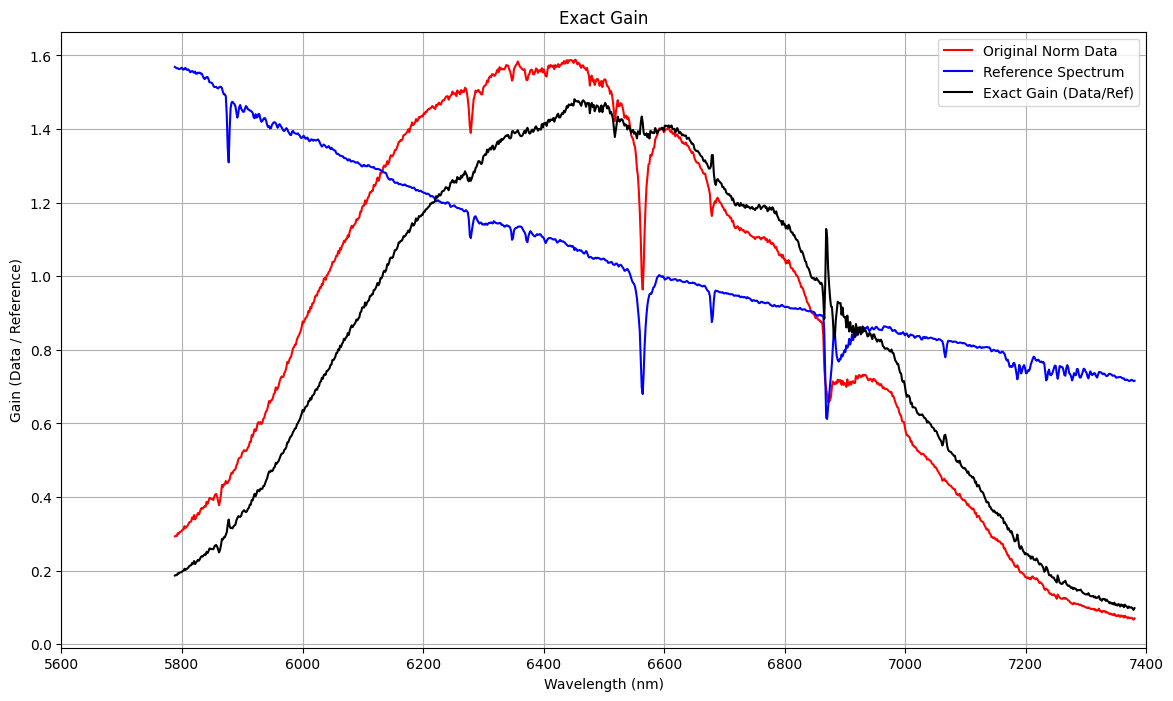

In [226]:
# Create an initial calibrated spectrum using 2500 pixels left of the telluric line as a starting point

calibrated_spectrum, spectrum_out = new_wavelength_calibrate(spectrum[2][50:], a, b, c)
# calibrated_spectrum, spectrum_out = wavelength_calibrate(spectrum[2][45:])
# calibrated_spectrum, spectrum_out = new_wavelength_calibrate(col_sum[telluric_x - 2500:], a, b, c)

wave_grid, flux_data_interp, flux_ref_interp = match_and_interpolate(calibrated_spectrum, spectrum_out/np.median(spectrum_out), jwaves, fluxes/np.median(fluxes))

# plt.figure(1,figsize=(12,7))
# plt.plot(wave_grid, flux_data_interp, color = 'red')
# plt.plot(wave_grid, flux_ref_interp, color = 'blue')
# plt.xlim(5600, 7400)
# # plt.ylim(0,2e15)
# plt.xlabel('Wavelength (nm)')
# plt.ylabel('Gain (Data / Reference)')
# plt.title('Exact Gain')
# plt.grid(True)
# plt.show()

# Now you can calculate gain:
gain = flux_data_interp / flux_ref_interp

plt.figure(1,figsize=(14,8))
plt.plot(wave_grid, flux_data_interp, color = 'red', label = 'Original Norm Data')
plt.plot(wave_grid, flux_ref_interp, color = 'blue', label = 'Reference Spectrum')
plt.plot(wave_grid, gain, color = 'black', label = 'Exact Gain (Data/Ref)')
plt.xlim(5600, 7400)
# plt.ylim(0,2e15)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Gain (Data / Reference)')
plt.title('Exact Gain')
plt.legend()
plt.grid(True)
plt.show()

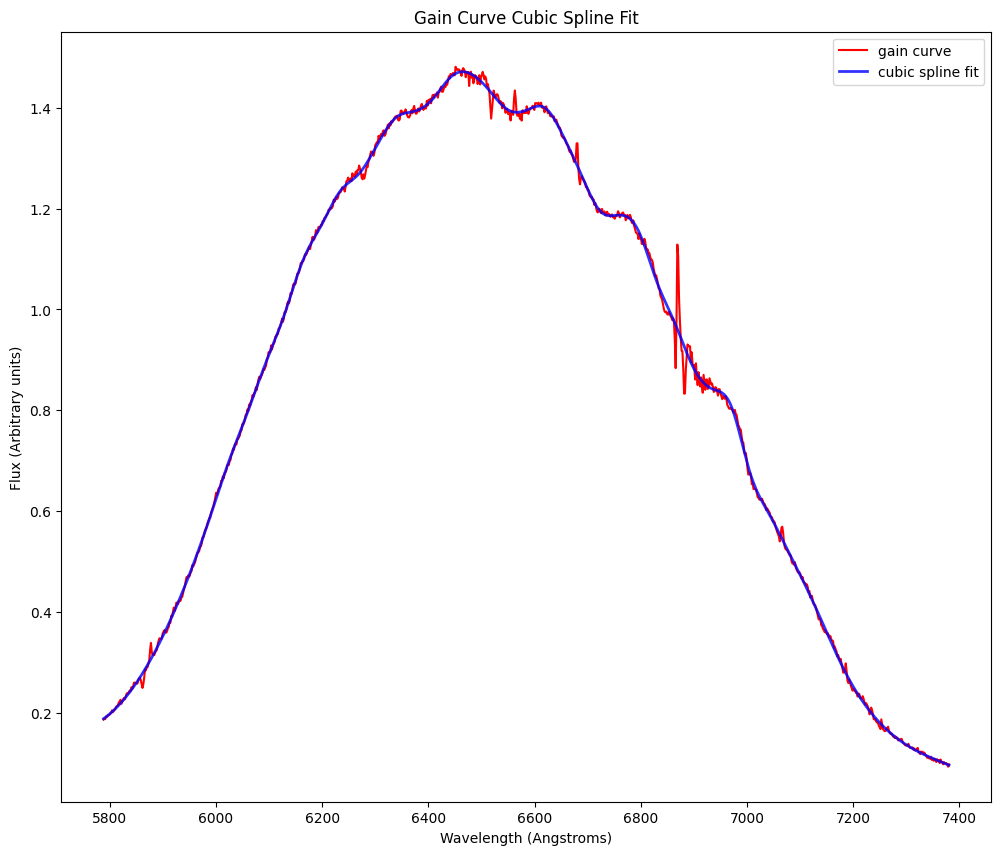

In [ ]:
import numpy as np
from scipy.interpolate import LSQUnivariateSpline

# ~400 Å spacing (good for gain curves)
# knots = np.linspace(wave_grid.min()+200, wave_grid.max()-200, 35)

spline = LSQUnivariateSpline(wave_grid, gain, t=knots, k=3)
gain_smooth = spline(wave_grid)

plt.figure(figsize = (12,10))
plt.plot(wave_grid, gain, color = 'red', label = 'gain curve')
plt.plot(wave_grid, gain_smooth, color = 'blue', alpha = 0.8, linewidth = 2, label = 'cubic spline fit')
plt.xlabel('Wavelength (Angstroms)')
plt.ylabel('Flux (Arbitrary units)')
plt.title('Gain Curve Cubic Spline Fit')
plt.legend()
plt.show()

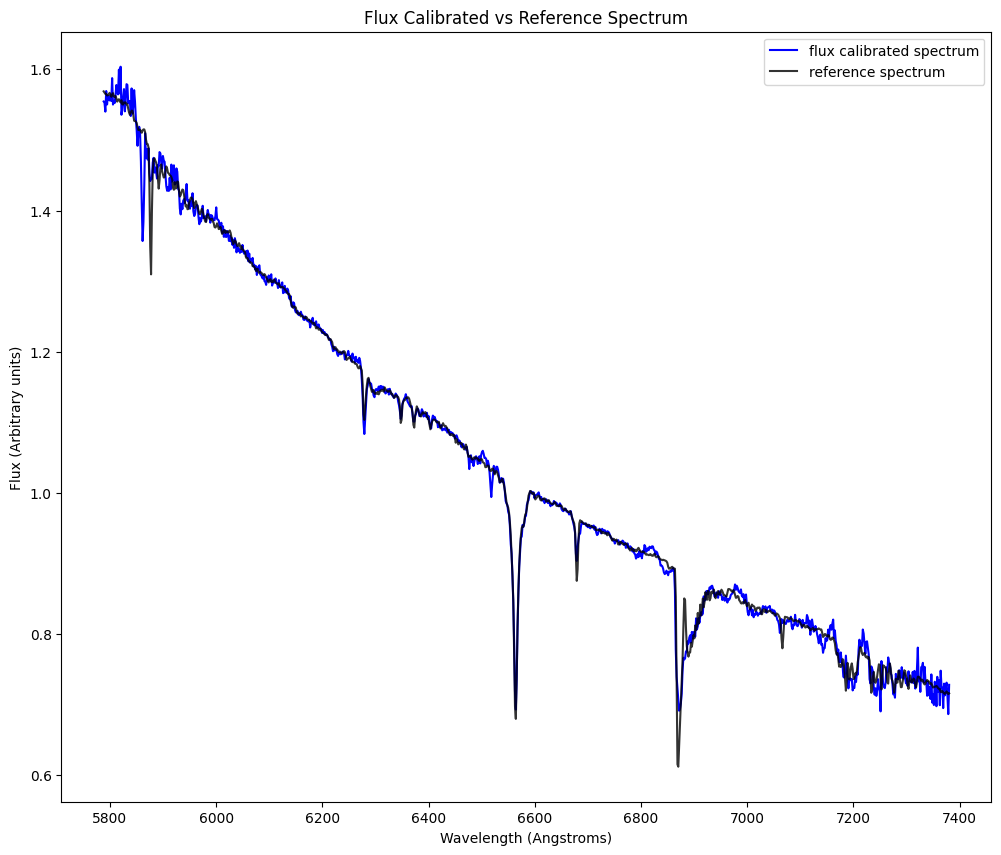

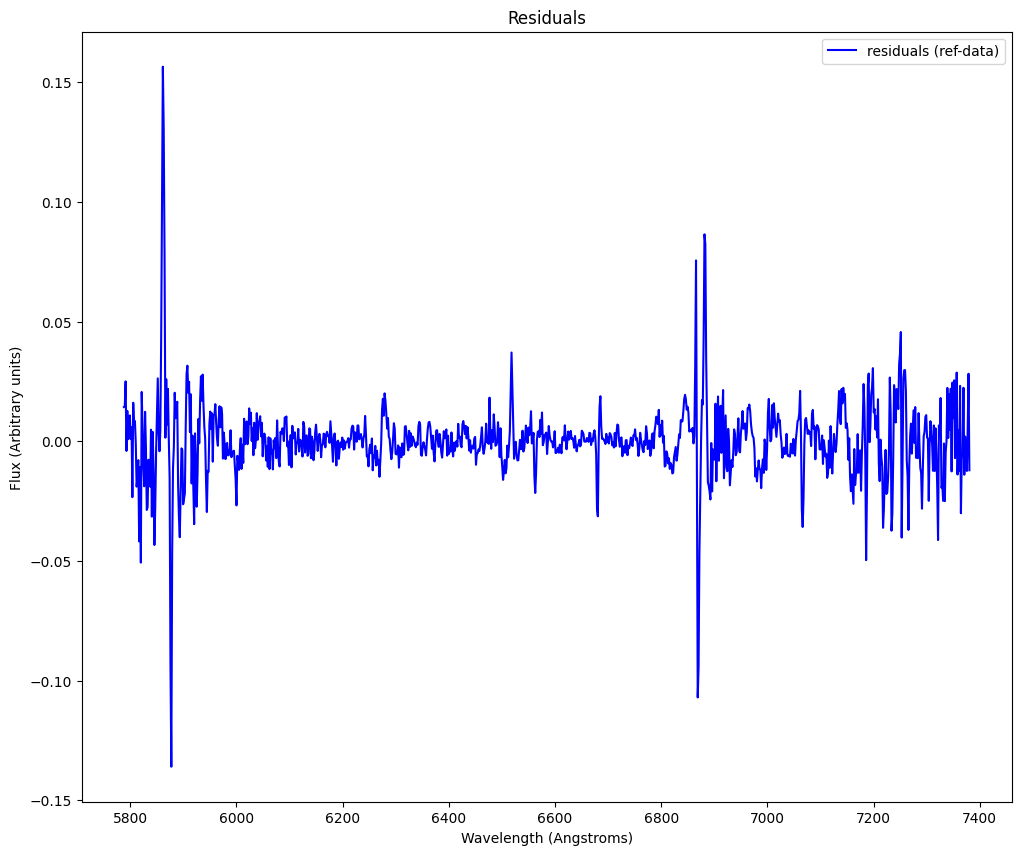

In [228]:
cal_spec = flux_data_interp/gain_smooth

plt.figure(figsize = (12,10))
# plt.plot(wave_grid, flux_data_interp, color = 'red', label = 'original norm data')
# plt.plot(wave_grid, gain_smooth, color = 'green', label = 'gain curve')
plt.plot(wave_grid, cal_spec, color = 'blue', label = 'flux calibrated spectrum')
plt.plot(wave_grid, flux_ref_interp, color = 'black', alpha = 0.8, label = 'reference spectrum')
plt.xlabel('Wavelength (Angstroms)')
plt.ylabel('Flux (Arbitrary units)')
plt.title('Flux Calibrated vs Reference Spectrum')
plt.legend()
plt.show()

plt.figure(figsize = (12,10))
# plt.plot(wave_grid, flux_data_interp, color = 'red', label = 'original norm data')
# plt.plot(wave_grid, gain_smooth, color = 'green', label = 'gain curve')
plt.plot(wave_grid, flux_ref_interp - cal_spec, color = 'blue', label = 'residuals (ref-data)')
plt.xlabel('Wavelength (Angstroms)')
plt.ylabel('Flux (Arbitrary units)')
plt.title('Residuals')
plt.legend()
plt.show()

# Export to csv

In [206]:
# HRG Wavelength Solution

import pandas as pd
from pathlib import Path

calib_dir = Path.cwd() / "grism_calib"
calib_dir.mkdir(exist_ok=True)

df_wl = pd.DataFrame([{
    "grism": "highres",
    "a": a,
    "b": b,
    "c": c,
    "units": "angstrom"
}])

wl_path = calib_dir / "wavelength_solutions.csv"

# append-safe for future lowres
if wl_path.exists():
    df_wl.to_csv(wl_path, mode="w", header = True, index=False)
else:
    df_wl.to_csv(wl_path, header = True, index=False)

In [207]:
# HRG Gain Spline

import pandas as pd
from pathlib import Path

calib_dir = Path.cwd() / "grism_calib"
calib_dir.mkdir(exist_ok=True)

df_gain = pd.DataFrame({
    "grism": "highres",
    "wavelength": wave_grid,
    "gain": gain_smooth
})

gain_path = calib_dir / "gain_curves.csv"

# overwrite intentionally
df_gain.to_csv(gain_path, index=False)

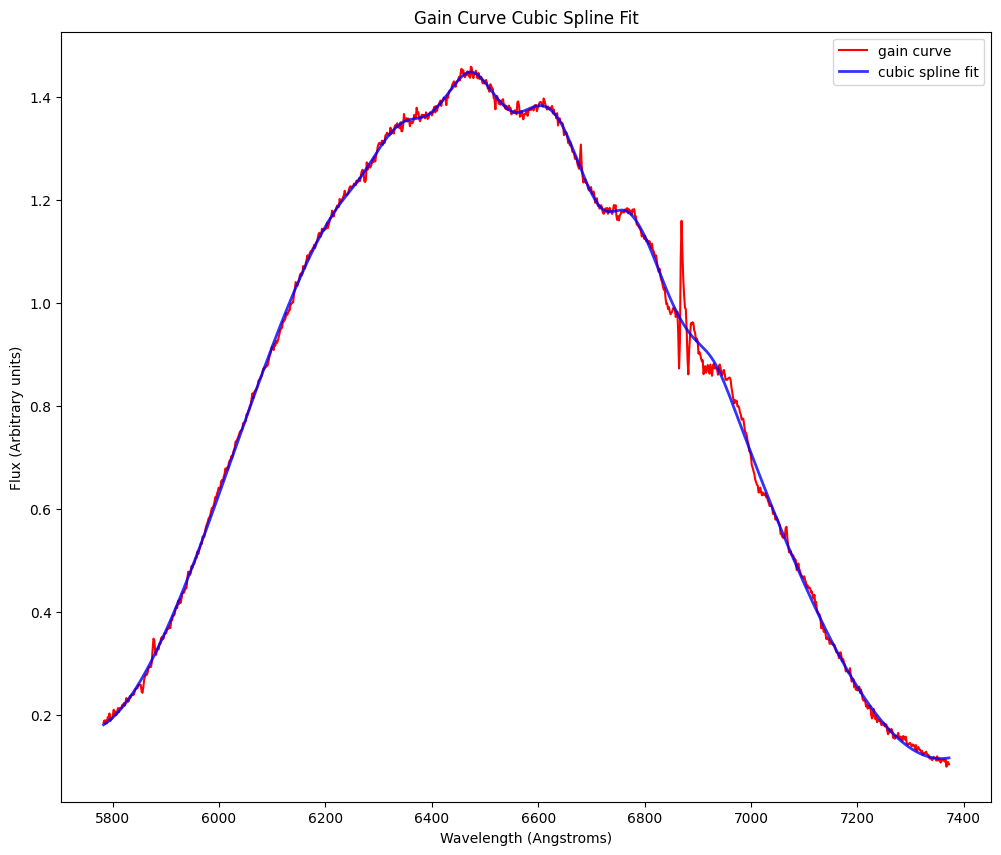

In [208]:
# Sanity check reconstruction

import pandas as pd
from scipy.interpolate import CubicSpline

df = pd.read_csv("grism_calib/gain_curves.csv")

g = df[df["grism"] == "highres"].sort_values("wavelength")

gain_spline = CubicSpline(
    g["wavelength"].values,
    g["gain"].values,
    bc_type="natural"
)

gain_corrected = gain_spline(wave_grid)

plt.figure(figsize = (12,10))
plt.plot(wave_grid, gain, color = 'red', label = 'gain curve')
# plt.plot(g["wavelength"].values, g["gain"].values, color = 'blue', alpha = 0.8, linewidth = 2, label = 'cubic spline fit')
plt.plot(wave_grid, gain_corrected, color = 'blue', alpha = 0.8, linewidth = 2, label = 'cubic spline fit')
plt.xlabel('Wavelength (Angstroms)')
plt.ylabel('Flux (Arbitrary units)')
plt.title('Gain Curve Cubic Spline Fit')
# plt.xlim(6200,7000)
# plt.ylim(0,2)
plt.legend()
plt.show()
